#Renewble Energy Project

# import liabrary / Font

In [1]:
import os
import math
import sys
import warnings
from functools import partial
from html import escape
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import matplotlib.font_manager as fm
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D
from matplotlib.colors import LinearSegmentedColormap, SymLogNorm
from matplotlib.cm import ScalarMappable
import matplotlib.patheffects as pe

from IPython.display import Image, display
from PIL import Image as PILImage

import flagpy as fp
from plottable import ColumnDefinition, Table
from plottable.plots import image

warnings.filterwarnings('ignore')

In [2]:
FONT_PATH = os.path.join('fonts', 'Garuda.otf')

thai_font_name = None
if os.path.exists(FONT_PATH):
    fm.fontManager.addfont(FONT_PATH)
    thai_font_name = fm.FontProperties(fname=FONT_PATH).get_name()
else:
    # Fallback: a Thai-capable font already installed on this machine
    candidates = ['Garuda', 'Noto Sans Thai', 'Leelawadee UI', 'Leelawadee', 'Tahoma', 'Cordia New', 'Loma']
    installed = {f.name for f in fm.fontManager.ttflist}
    thai_font_name = next((c for c in candidates if c in installed), None)

if thai_font_name:
    plt.rcParams['font.family'] = thai_font_name
    plt.rcParams['font.size'] = 12
    plt.rcParams['axes.unicode_minus'] = False
    print(f'Thai font ready: "{thai_font_name}"')
else:
    print("No Thai font found. Make sure the 'fonts' folder (with Garuda.otf) "
          "sits next to this notebook.")

Thai font ready: "Garuda"


In [3]:
# Locate the bundled fonts from the notebook or workspace directory.
font_dirs = [Path('fonts'), Path('dads 5001') / 'fonts']
font_dir = next((p for p in font_dirs if (p / 'Garuda.otf').is_file()), None)
if font_dir is not None:
    for filename in ['Garuda.otf', 'Garuda-Bold.otf']:
        font_path = font_dir / filename
        if font_path.is_file():
            fm.fontManager.addfont(str(font_path))
    GARUDA = fm.FontProperties(fname=str(font_dir / 'Garuda.otf')).get_name()
else:
    GARUDA = globals().get('thai_font_name') or 'Tahoma'
DEJAVU = 'DejaVu Sans'
plt.rcParams['font.family'] = GARUDA
plt.rcParams['axes.unicode_minus'] = False


# Import file

In [4]:
url = 'https://raw.githubusercontent.com/Manasafang/Transition-or-Addition/main/renewable_energy_countries_selected_v7.csv'
df = pd.read_csv(url)

print(f"Shape: {df.shape}")
print(f"Countries: {df['country'].nunique()}")
print(f"Years: {df['year'].min()} – {df['year'].max()}")
df.head()

Shape: (5381, 23)
Countries: 213
Years: 2000 – 2025


,country,continent,year,iso_code,gdp,electricity_generation,renewables_share_elec,fossil_share_elec,low_carbon_share_elec,solar_electricity,...,coal_electricity,gas_electricity,oil_electricity,other_renewable_electricity,solar_share_elec,wind_share_elec,hydro_share_elec,nuclear_share_elec,coal_share_elec,gas_share_elec
0,Afghanistan,Asia,2000,AFG,1.128379e+10,0.48,64.583,35.417,64.583,0.0,...,0.00,0.0,0.17,0.0,0.0,0.0,64.583,0.0,0.000,0.0
1,Afghanistan,Asia,2001,AFG,1.102127e+10,0.69,72.464,27.536,72.464,0.0,...,0.04,0.0,0.15,0.0,0.0,0.0,72.464,0.0,5.797,0.0
2,Afghanistan,Asia,2002,AFG,1.880487e+10,0.71,78.873,21.127,78.873,0.0,...,0.04,0.0,0.11,0.0,0.0,0.0,78.873,0.0,5.634,0.0
3,Afghanistan,Asia,2003,AFG,2.107434e+10,0.91,69.231,30.769,69.231,0.0,...,0.09,0.0,0.19,0.0,0.0,0.0,69.231,0.0,9.890,0.0
4,Afghanistan,Asia,2004,AFG,2.233257e+10,0.79,70.886,29.114,70.886,0.0,...,0.06,0.0,0.17,0.0,0.0,0.0,70.886,0.0,7.595,0.0


#Figure 1

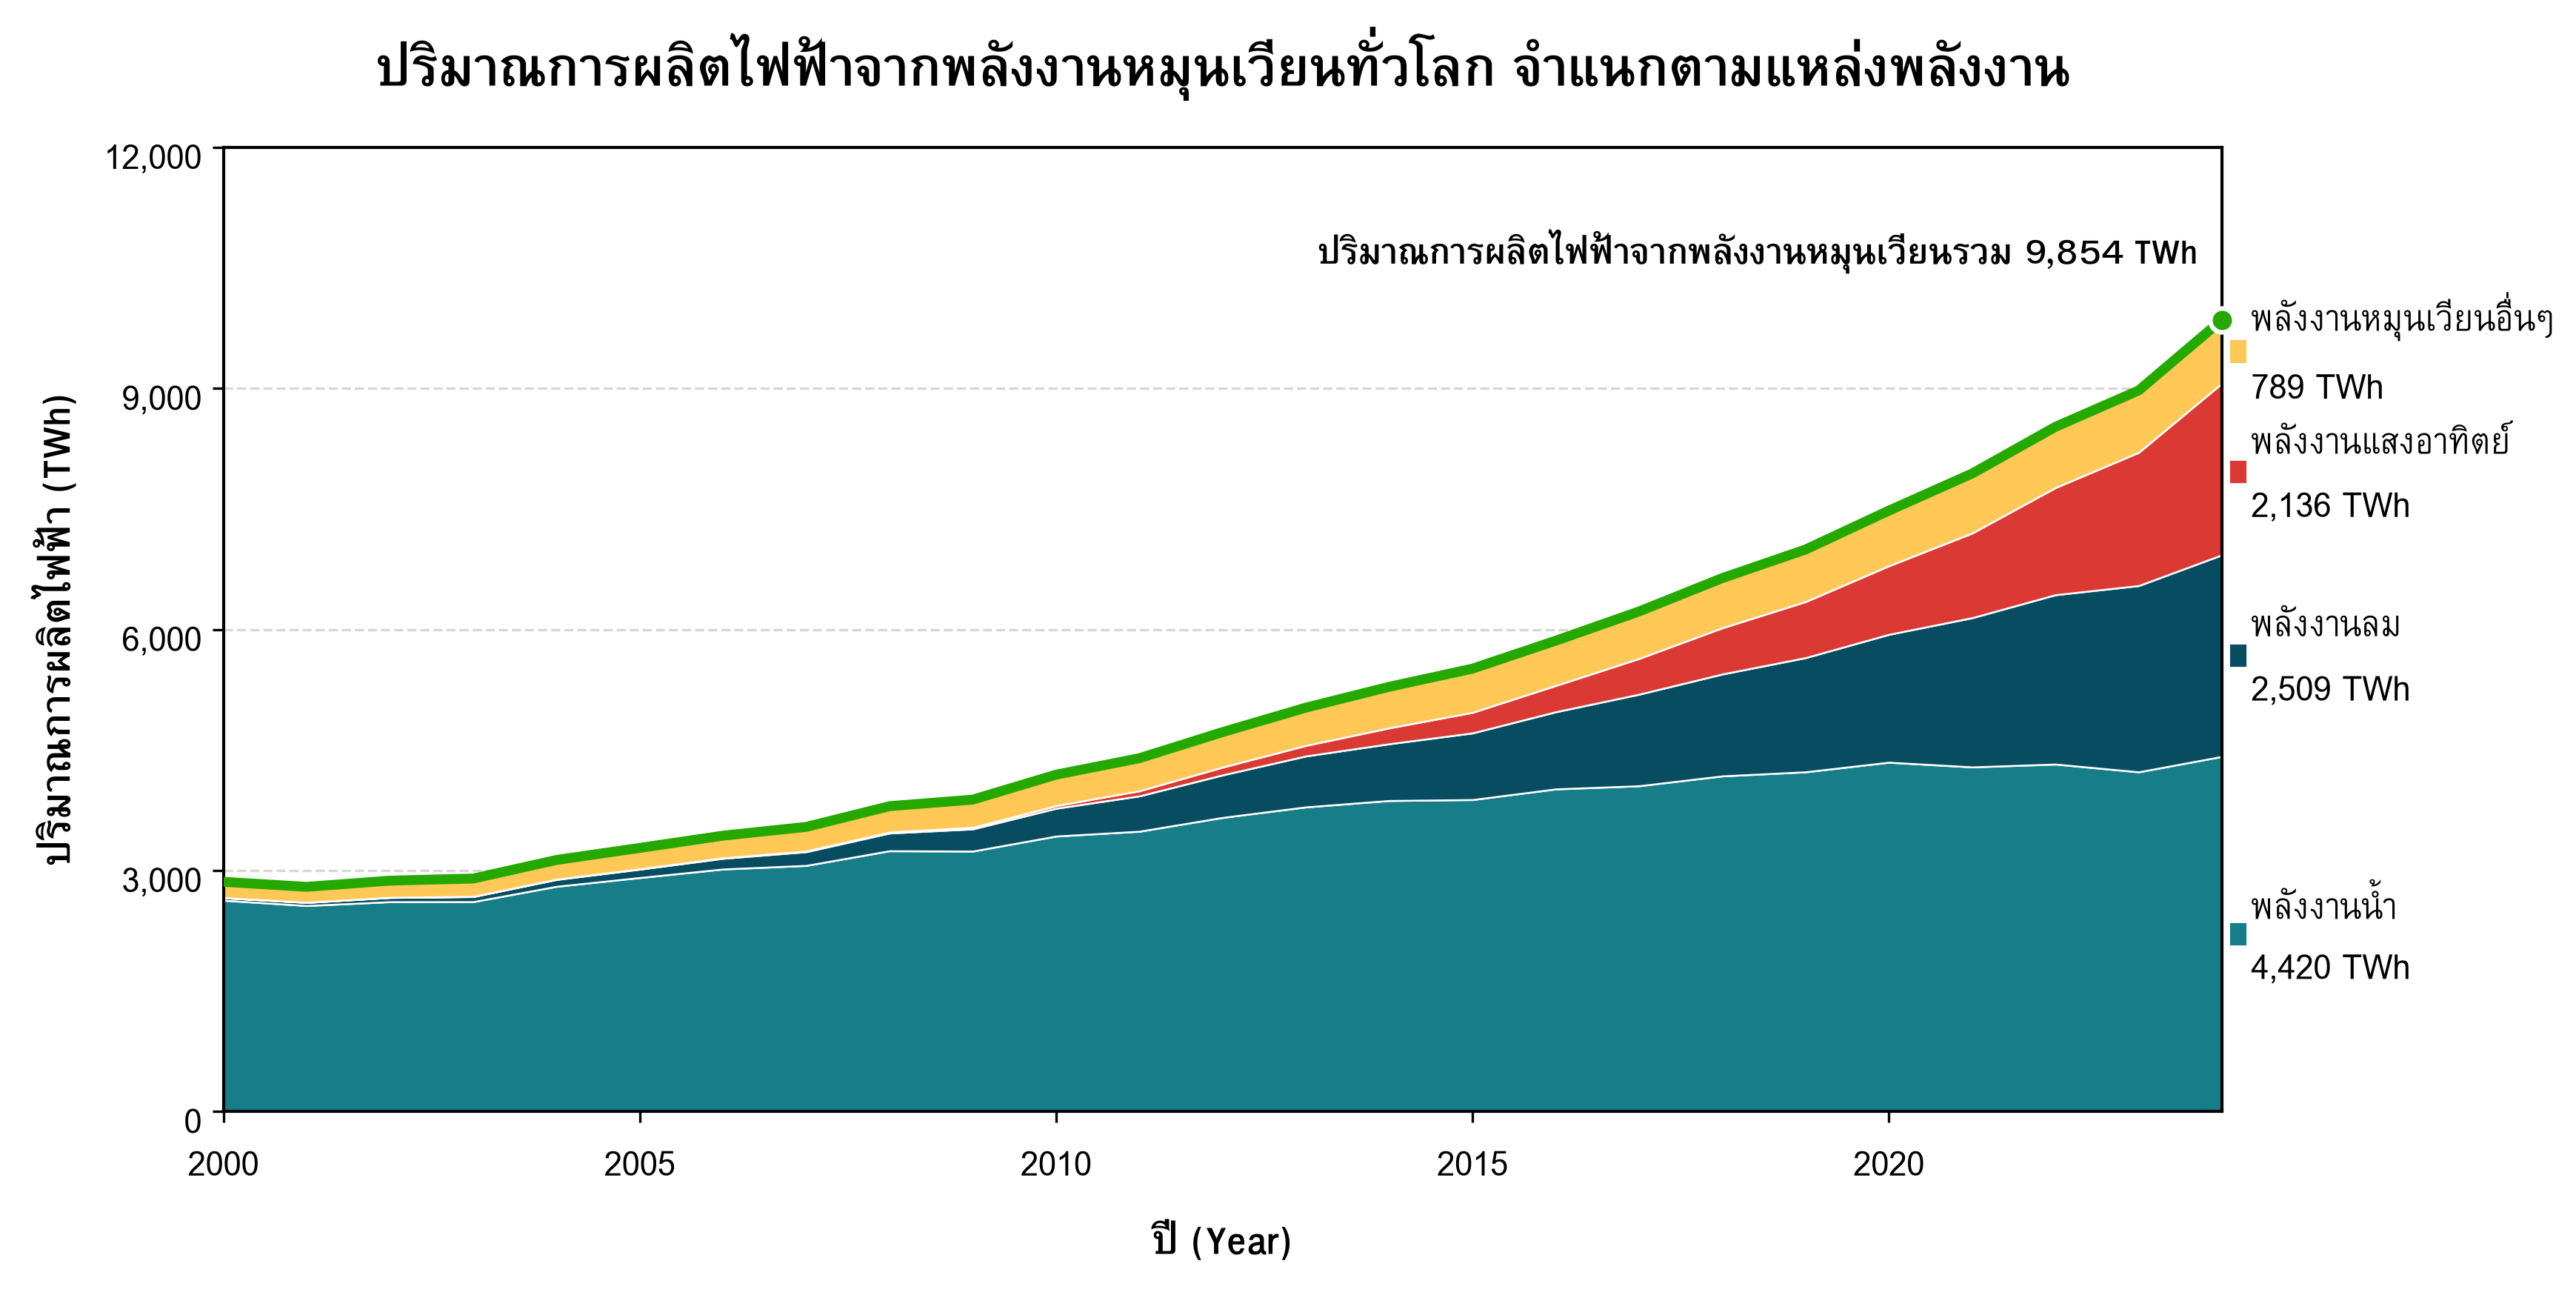

In [5]:
# ── Figure 1: พลังงานหมุนเวียนแยกตามแหล่ง (stacked) + เส้นรวม RE ──────────

# ── 1. เตรียมข้อมูล ────────────────────────────────────────────
df_fig1 = df[df['year'].between(2000, 2024)]

re_src = df_fig1.groupby('year').agg(
    hydro    = ('hydro_electricity',           'sum'),
    wind     = ('wind_electricity',            'sum'),
    solar    = ('solar_electricity',           'sum'),
    other_re = ('other_renewable_electricity', 'sum'),
    total    = ('electricity_generation',      'sum'),
    n_country= ('country',                     'nunique'),
).reset_index()

re_src['RE']       = re_src[['hydro', 'wind', 'solar', 'other_re']].sum(axis=1)
re_src['re_share'] = re_src['RE'] / re_src['total'] * 100
re_src = re_src.set_index('year')

years   = re_src.index.values
first_y = years.min()
last_y  = years.max()
re_0    = re_src.loc[first_y, 'RE']
re_1    = re_src.loc[last_y,  'RE']

# ── 2. สี ─────────────────────────────────────────────────────
# เส้นรวม RE ใช้สีหลักของ RE (#426214) ให้ต่อเนื่องกับ Figure อื่น
FILL_ALPHA = 1.0    # ความทึบของชั้นพื้นที่ (1 = ทึบ, ค่าน้อยลง = โปร่งแสงขึ้น)
C_RE = '#25A800'
SRC_STYLE = [
    # (คอลัมน์,   ชื่อไทย,        สี)
    ('hydro',    'พลังงานน้ำ',      '#177E89'),
    ('wind',     'พลังงานลม',      '#084C61'),
    ('solar',    'พลังงานแสงอาทิตย์', '#DB3A34'),
    ('other_re', 'พลังงานหมุนเวียนอื่นๆ', '#FFC857'),
]
C_TEXT  = '#000000'
C_MUTED = '#666666'

# ── 3. วาดกราฟ ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6), facecolor='white', dpi=300)

ax.stackplot(years,
             *[re_src[c] for c, _, _ in SRC_STYLE],
             colors=[col for _, _, col in SRC_STYLE],
             alpha=FILL_ALPHA, edgecolor='white', linewidth=0.6, zorder=2)

# เส้นทึบยอดรวม RE (= ขอบบนของชั้นซ้อน)
ax.plot(years, re_src['RE'], color=C_RE, linewidth=3.2, zorder=4,
        solid_capstyle='round')

# ตัวเลขยอดรวม RE ปีล่าสุด (ปลายเส้นสีเขียว)
ax.scatter(last_y, re_1, s=60, color=C_RE, edgecolor='white',
           linewidth=1.5, zorder=5, clip_on=False)
ax.annotate(f'ปริมาณการผลิตไฟฟ้าจากพลังงานหมุนเวียนรวม {re_1:,.0f} TWh', xy=(last_y, re_1),
            xytext=(-8, 12), textcoords='offset points',
            ha='right', va='bottom', fontsize=10.5, fontweight='bold',
            color='#000000', zorder=6)
            
y_step = 3000
y_max  = np.ceil(re_1 * 1.15 / y_step) * y_step

# ── 4. ป้ายชื่อชั้นที่ปลายขวา (แทน legend) ─────────────────────
# วางป้ายที่กึ่งกลางชั้น แล้วดันป้ายที่ชิดกันเกินไปลงมา (ไล่จากบนลงล่าง) ไม่ให้ทับกัน
LABEL_MIN_GAP = 1500   # ระยะห่างขั้นต่ำระหว่างป้าย (TWh)
mids, cum = [], 0
for col, _, _ in SRC_STYLE:
    v = re_src.loc[last_y, col]
    mids.append(cum + v / 2)
    cum += v
label_y = list(mids)
for i in range(len(label_y) - 2, -1, -1):
    label_y[i] = min(label_y[i], label_y[i + 1] - LABEL_MIN_GAP)
for (col, name, color), y in zip(SRC_STYLE, label_y):
    v = re_src.loc[last_y, col]
    ax.text(last_y + 0.35, y, f'{name}\n{v:,.0f} TWh',
            ha='left', va='center', fontsize=10.5, color=C_TEXT,
            linespacing=1.15, clip_on=False)
    ax.add_patch(Rectangle((last_y + 0.12, y - 120), 0.16, 240,
                           color=color, alpha=FILL_ALPHA, clip_on=False, zorder=5))

# ── 5. แกน / รูปแบบ ───────────────────────────────────────────
ax.set_xlim(first_y, last_y)
ax.set_ylim(0, y_max)
ax.set_yticks(np.arange(0, y_max + y_step, y_step))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))
ax.set_xticks(np.arange(2000, 2025, 5))
ax.tick_params(labelsize=10.5)

ax.set_title('ปริมาณการผลิตไฟฟ้าจากพลังงานหมุนเวียนทั่วโลก จำแนกตามแหล่งพลังงาน',
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('ปี (Year)', fontsize=12,fontweight='bold')
ax.set_ylabel('ปริมาณการผลิตไฟฟ้า (TWh)', fontsize=12,fontweight='bold')
ax.grid(axis='y', linestyle='--', alpha=0.5, zorder=0)
for sp in ax.spines.values():
    sp.set_visible(True)
    sp.set_color('#000000')
    sp.set_linewidth(1.0)

plt.tight_layout()
plt.subplots_adjust(right=0.84)
plt.savefig('figure1.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.close(fig)
display(Image(filename='figure1.png', width=850))   # แสดงเล็กกว่ารูปอื่นเล็กน้อย

#Figure 2-3

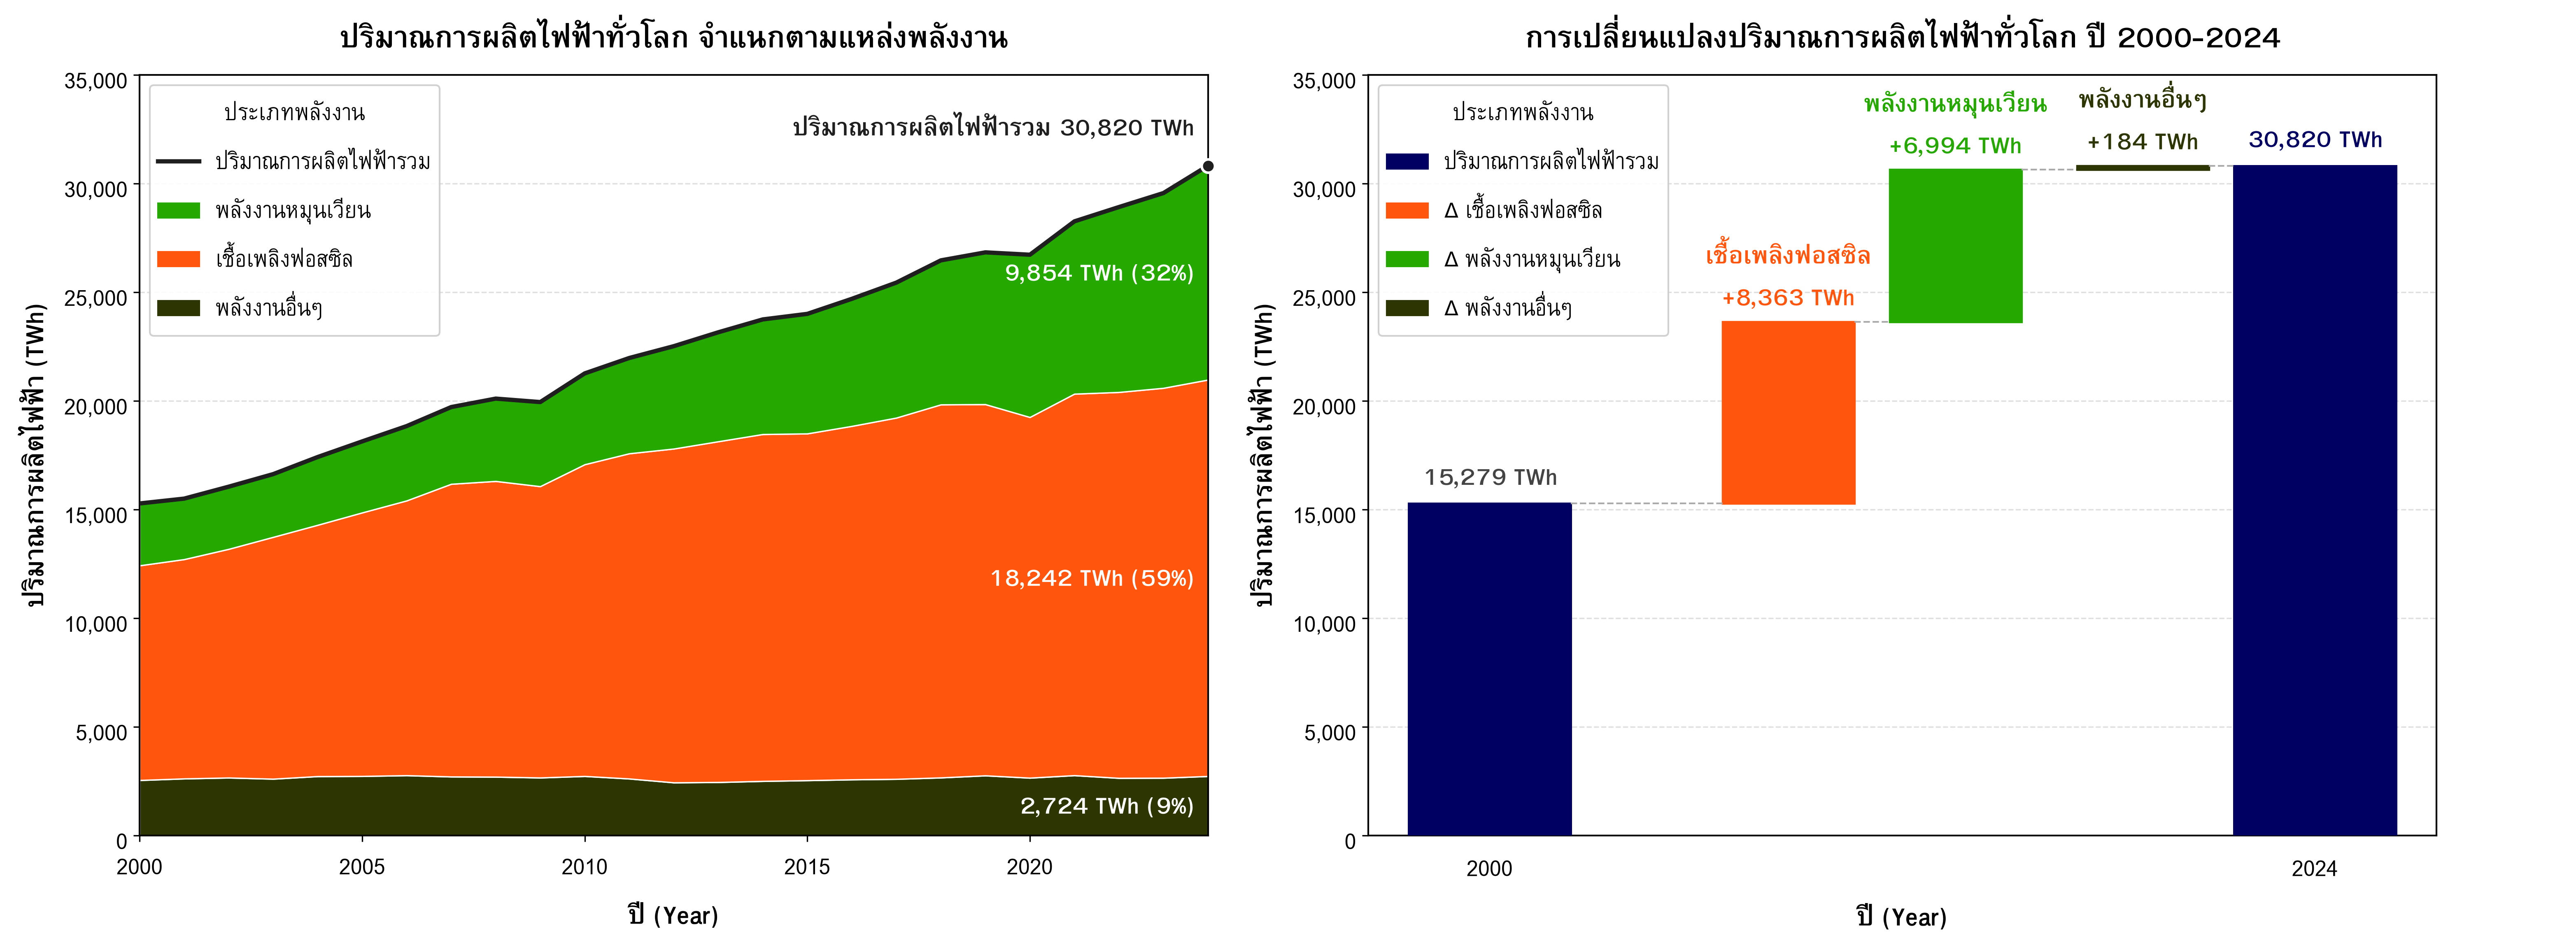

In [6]:
# ── Figure 2: การผลิตไฟฟ้าโลก (stacked area) + การเปลี่ยนแปลง 2000→2024 (waterfall) ──────

from matplotlib.transforms import Bbox

# ── 1. เตรียมข้อมูล ────────────────────────────────────────────
world = df.groupby('year').agg(
    coal     = ('coal_electricity',            'sum'),
    gas      = ('gas_electricity',             'sum'),
    oil      = ('oil_electricity',             'sum'),
    solar    = ('solar_electricity',           'sum'),
    wind     = ('wind_electricity',            'sum'),
    hydro    = ('hydro_electricity',           'sum'),
    other_re = ('other_renewable_electricity', 'sum'),
    Other    = ('nuclear_electricity',         'sum'),   # แสดงเป็นพลังงานอื่นๆ
).reset_index()

world['Fossil'] = world['coal'] + world['gas'] + world['oil']
world['RE']     = world['solar'] + world['wind'] + world['hydro'] + world['other_re']
world = world[world['year'].between(2000, 2024)].set_index('year')
world['Total']  = world[['Other', 'Fossil', 'RE']].sum(axis=1)

years   = world.index.values
first_y = years.min()
last_y  = years.max()

sources    = ['Fossil', 'RE', 'Other']
val2000    = {s: world.loc[first_y, s] for s in sources}
val2024    = {s: world.loc[last_y, s]  for s in sources}
delta      = {s: val2024[s] - val2000[s] for s in sources}
total_2000 = world.loc[first_y, 'Total']
total_2024 = world.loc[last_y, 'Total']

# ── 2. สี / ชื่อ (ชุดเดียวกันทั้งสองกราฟ) ─────────────────────────
C_src   = {'Fossil': '#FF550D', 'RE': '#25A800', 'Other': '#2D3502'}
th_name = {'Fossil': 'เชื้อเพลิงฟอสซิล', 'RE': 'พลังงานหมุนเวียน', 'Other': 'พลังงานอื่นๆ'}
C_TOTAL_LINE = '#1F1F1F'   # เส้นยอดรวม (กราฟซ้าย)
C_BAR        = '#000062'   # แท่งรวม (กราฟขวา)
FS_TICK, FS_LABEL = 12, 13 # ขนาดตัวอักษร: ตัวเลขแกน / ป้ายตัวเลขในกราฟ (เท่ากันทั้งสองกราฟ)

# ลำดับชั้นจากล่างขึ้นบน
LAYERS = ['Other', 'Fossil', 'RE']

def style_axes(ax):
    """กรอบดำ + กริดแนวนอน ใช้ร่วมกันทั้งสองกราฟ"""
    ax.grid(axis='y', linestyle='--', alpha=0.4, zorder=0)
    for sp in ax.spines.values():
        sp.set_visible(True)
        sp.set_color('#000000')
        sp.set_linewidth(1.0)

legend_kw = dict(loc='upper left', fontsize=12, framealpha=0.9,
                 title='ประเภทพลังงาน', title_fontsize=12)

# ── 3. วาดกราฟ ────────────────────────────────────────────────
with plt.rc_context({'font.family': [GARUDA, 'DejaVu Sans'],
                     'axes.unicode_minus': False}):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 8), dpi=300, facecolor='white',
                                   gridspec_kw={'width_ratios': [1, 1], 'wspace': 0.15})

    # ════ กราฟซ้าย: Stacked Area ════════════════════════════════
    ax1.stackplot(years, *[world[s] for s in LAYERS],
                  colors=[C_src[s] for s in LAYERS],
                  edgecolor='white', linewidth=0.8, zorder=2)

    ax1.plot(years, world['Total'], color=C_TOTAL_LINE, linewidth=2.5, zorder=4,
             solid_capstyle='round')
    ax1.scatter(last_y, total_2024, s=60, color=C_TOTAL_LINE, edgecolor='white',
                linewidth=1.5, zorder=5, clip_on=False)
    ax1.annotate(f'ปริมาณการผลิตไฟฟ้ารวม {total_2024:,.0f} TWh', xy=(last_y, total_2024),
                 xytext=(-8, 10), textcoords='offset points',
                 ha='right', va='bottom', fontsize=FS_LABEL, fontweight='bold',
                 color=C_TOTAL_LINE, zorder=6)

    y_step = 5000
    y_max1 = 35000
    ax1.set_xlim(first_y, last_y)
    ax1.set_ylim(0, y_max1)
    ax1.set_yticks(np.arange(0, y_max1 + y_step, y_step))
    ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))
    ax1.set_xticks(np.arange(2000, 2025, 5))
    ax1.tick_params(labelsize=FS_TICK)

    # ตัวเลขปีล่าสุดวางในแต่ละชั้นของกราฟ (ชิดขวา กึ่งกลางความหนาของชั้น)
    cum = 0
    for s in LAYERS:
        v   = val2024[s]
        pct = v / total_2024 * 100
        ax1.text(last_y - 0.3, cum + v / 2, f'{v:,.0f} TWh ({pct:.0f}%)',
                 ha='right', va='center', fontsize=FS_LABEL, fontweight='bold',
                 color='white', zorder=6)
        cum += v

    # Legend มุมบนซ้าย: เส้นยอดรวม + ชื่อแหล่งพลังงาน เรียงบน→ล่างตามชั้นในกราฟ
    handles1  = [Line2D([0], [0], color=C_TOTAL_LINE, linewidth=2.5,
                        label='ปริมาณการผลิตไฟฟ้ารวม')]
    handles1 += [mpatches.Patch(color=C_src[s], label=th_name[s]) for s in reversed(LAYERS)]
    ax1.legend(handles=handles1, **legend_kw)
    
    ax1.set_xlabel('ปี (Year)', fontsize=14, fontweight='bold')
    ax1.set_ylabel('ปริมาณการผลิตไฟฟ้า (TWh)', fontsize=14, fontweight='bold')
    ax1.set_title('ปริมาณการผลิตไฟฟ้าทั่วโลก จำแนกตามแหล่งพลังงาน',
                  fontsize=16, fontweight='bold', pad=16)
    style_axes(ax1)

    # ════ กราฟขวา: Waterfall 2000 → 2024 ════════════════════════
    bw, dw = 1.6, 1.3                        # ความกว้างแท่งรวม / แท่ง Δ (กว้างขึ้นให้เนื้อหาแน่นใกล้เคียงกราฟซ้าย)
    widths = np.array([bw, dw, dw, dw, bw])
    # ช่องแรก (2000 -> Δฟอสซิล) กว้างกว่า เพื่อให้ป้ายฟอสซิลพ้น legend มุมบนซ้าย
    gaps = np.array([1.5, 0.35, 0.55, 0.25])
    left_edge = 0.15
    x_pad = left_edge + 0.25                 # ระยะขอบซ้าย/ขวาของกรอบ เท่ากันทั้งสองฝั่ง
    centers = [left_edge + bw / 2]
    for i, gap in enumerate(gaps):
        centers.append(centers[-1] + widths[i] / 2 + gap + widths[i + 1] / 2)
    x_left, x_right = centers[0], centers[-1]
    x_deltas = dict(zip(sources, centers[1:-1]))

    ax2.bar(x_left,  total_2000, width=bw, color=C_BAR, edgecolor=C_BAR, linewidth=1.2, zorder=3)
    ax2.bar(x_right, total_2024, width=bw, color=C_BAR, edgecolor=C_BAR, linewidth=1.2, zorder=3)
    ax2.text(x_left,  total_2000 + 250, f'{total_2000:,.0f} TWh', ha='center', va='bottom',
             fontsize=FS_LABEL, fontweight='bold', color='#444444')
    ax2.text(x_right, total_2024 + 250, f'{total_2024:,.0f} TWh', ha='center', va='bottom',
             fontsize=FS_LABEL, fontweight='bold', color=C_BAR)

    running = total_2000
    for i, s in enumerate(sources):
        d, xd = delta[s], x_deltas[s]
        bar_bot, bar_top = (running, running + d) if d >= 0 else (running + d, running)
        ax2.bar(xd, abs(d), bottom=bar_bot, width=dw, color=C_src[s],
                edgecolor=C_src[s], linewidth=1.3, zorder=4)
        sign = '+' if d >= 0 else ''
        ax2.text(xd, bar_top + 150, f'{th_name[s]}\n{sign}{d:,.0f} TWh',
                 ha='center', va='bottom', fontsize=FS_LABEL, fontweight='bold',
                 color=C_src[s], zorder=6)
        # เส้นประเชื่อมไปแท่งถัดไป
        x_next = x_deltas[sources[i + 1]] - dw / 2 if i + 1 < len(sources) else x_right - bw / 2
        ax2.plot([xd + dw / 2, x_next], [running + d, running + d],
                 color='#AAAAAA', lw=1.0, ls='--', zorder=4)
        running += d
    ax2.plot([x_left + bw / 2, x_deltas['Fossil'] - dw / 2], [total_2000, total_2000],
             color='#AAAAAA', lw=1.0, ls='--', zorder=4)

    ax2.set_xlim(left_edge - x_pad, x_right + bw / 2 + x_pad)
    # ใช้ช่วงค่าและระยะ tick ของแกน Y เดียวกับกราฟซ้าย
    waterfall_y_max = y_max1
    ax2.set_ylim(0, waterfall_y_max)
    ax2.set_yticks(np.arange(0, waterfall_y_max + y_step, y_step))
    ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))
    ax2.tick_params(labelsize=FS_TICK)
    ax2.set_xticks([x_left, x_right])
    ax2.set_xticklabels(['2000', '2024'], fontsize=FS_TICK)
    ax2.tick_params(axis='x', length=0, pad=8)
    ax2.set_xlabel('ปี (Year)', fontsize=14, fontweight='bold')
    ax2.set_ylabel('ปริมาณการผลิตไฟฟ้า (TWh)', fontsize=14, fontweight='bold')
    ax2.set_title(f'การเปลี่ยนแปลงปริมาณการผลิตไฟฟ้าทั่วโลก ปี {first_y}-{last_y}',
                  fontsize=16, fontweight='bold', pad=16)
    style_axes(ax2)

    handles2 = [mpatches.Patch(color=C_BAR, label='ปริมาณการผลิตไฟฟ้ารวม')]
    handles2 += [mpatches.Patch(color=C_src[s], label=f'Δ {th_name[s]}') for s in sources]
    ax2.legend(handles=handles2, **legend_kw)

    
    # ขอบขวาของรูปให้กว้างเท่าขอบซ้าย (ฝั่งซ้ายมีชื่อแกน Y) ภาพจะได้ไม่เอียงไปข้างใดข้างหนึ่ง
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    tight = fig.get_tightbbox(renderer)                           # หน่วยนิ้ว
    left_gap = ax1.get_window_extent(renderer).x0 / fig.dpi - tight.x0
    right_gap = tight.x1 - ax2.get_window_extent(renderer).x1 / fig.dpi
    pad = 0.1
    bbox = Bbox.from_extents(tight.x0 - pad, tight.y0 - pad,
                             tight.x1 + max(0, left_gap - right_gap) + pad, tight.y1 + pad)
    plt.savefig('figure2-3.png', dpi=300, bbox_inches=bbox, facecolor='white')
    plt.close(fig)
    display(Image(filename='figure2-3.png', width=1000))

#Table 1-2

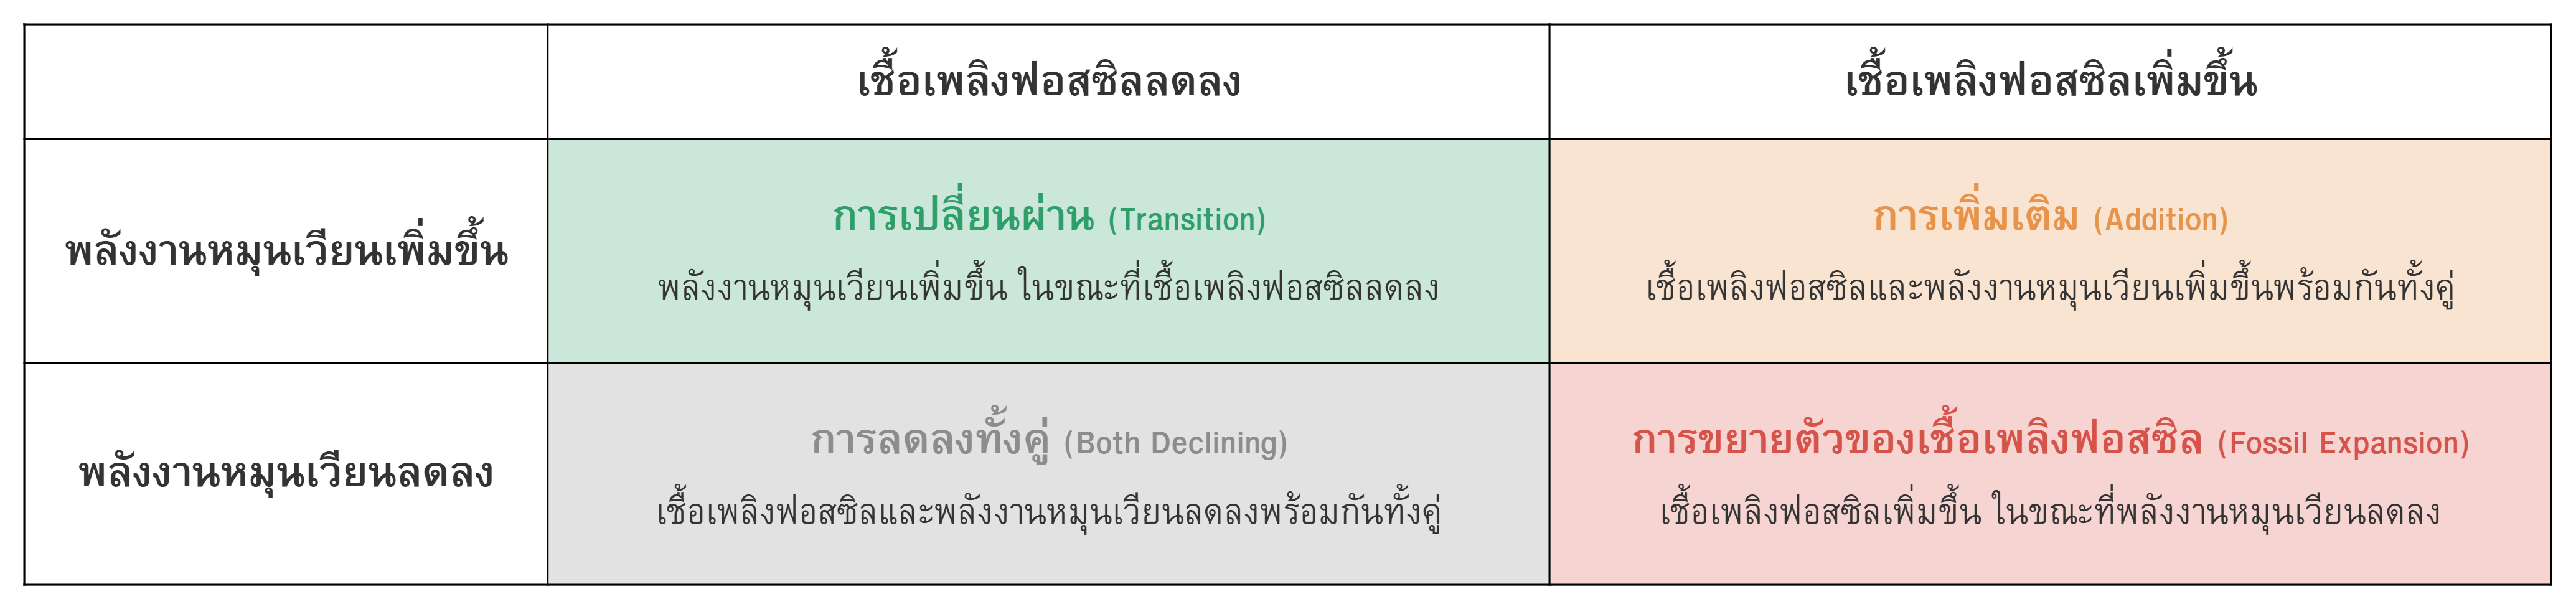

In [7]:
# 1. เตรียมตัวช่วยส่งออกภาพ
project_dir = Path.cwd()
if not (project_dir / "export_table_image.py").is_file():
    project_dir = project_dir / "dads 5001"
if str(project_dir) not in sys.path:
    sys.path.insert(0, str(project_dir))
from export_table_image import export_table

# 2. ข้อมูลตาราง: หัวคอลัมน์ หัวแถว และ 4 จตุภาค (ชื่อไทย, ชื่ออังกฤษ, คำอธิบาย)
column_headers = ["เชื้อเพลิงฟอสซิลลดลง", "เชื้อเพลิงฟอสซิลเพิ่มขึ้น"]
rows = [
    ("พลังงานหมุนเวียนเพิ่มขึ้น", [
        ("การเปลี่ยนผ่าน", "Transition",
         "พลังงานหมุนเวียนเพิ่มขึ้น ในขณะที่เชื้อเพลิงฟอสซิลลดลง"),
        ("การเพิ่มเติม", "Addition",
         "เชื้อเพลิงฟอสซิลและพลังงานหมุนเวียนเพิ่มขึ้นพร้อมกันทั้งคู่"),
    ]),
    ("พลังงานหมุนเวียนลดลง", [
        ("การลดลงทั้งคู่", "Both Declining",
         "เชื้อเพลิงฟอสซิลและพลังงานหมุนเวียนลดลงพร้อมกันทั้งคู่"),
        ("การขยายตัวของเชื้อเพลิงฟอสซิล", "Fossil Expansion",
         "เชื้อเพลิงฟอสซิลเพิ่มขึ้น ในขณะที่พลังงานหมุนเวียนลดลง"),
    ]),
]

# 3. สีตัวอักษรและพื้นหลังของแต่ละประเภท (ชุดเดียวกับ Figure 5)
colors = {
    "การเปลี่ยนผ่าน": {"text": "#2E9E6B", "background": "#2E9E6B"},
    "การเพิ่มเติม": {"text": "#E8934A", "background": "#E8934A"},
    "การลดลงทั้งคู่": {"text": "#8C8C8C", "background": "#8C8C8C"},
    "การขยายตัวของเชื้อเพลิงฟอสซิล": {"text": "#D6534A", "background": "#D6534A"},
}
background_opacity = 25  # เปอร์เซ็นต์ความทึบของสีพื้นหลัง

# 4. รูปแบบตาราง (ไม่มีหัวข้อหรือ caption)
table_css = """
<style>
#table1 {
    border-collapse: collapse;
    font-family: Garuda, sans-serif;
    font-size: 20px;
    width: 1300px;
}
#table1 th, #table1 td {
    border: 1px solid #000000;
    padding: 24px 20px;
    text-align: center;
    vertical-align: middle;
    line-height: 1.5;
    font-weight: bold;
}
#table1 th { background: white; color: #333333; }
#table1 thead th { padding: 14px 20px; }
#table1 tbody th { white-space: nowrap; }
#table1 td { width: 535px; }
#table1 .en { font-size: 16px; }
#table1 .desc { font-size: 17px; font-weight: normal; color: #333333; margin-top: 10px; }
</style>
"""

# 5. สร้างหัวแถวและช่องข้อมูลจากรายการด้านบน
header_html = "<th></th>" + "".join(
    f"<th>{escape(header)}</th>" for header in column_headers
)
body_rows = []
for row_label, categories in rows:
    cells = [f"<th>{escape(row_label)}</th>"]
    for name_th, name_en, desc in categories:
        color = colors[name_th]
        style = (
            f"color: {color['text']}; "
            f"background-color: color-mix(in srgb, "
            f"{color['background']} {background_opacity}%, transparent);"
        )
        cells.append(
            f'<td style="{style}">'
            f'<div>{escape(name_th)} <span class="en">({escape(name_en)})</span></div>'
            f'<div class="desc">{escape(desc)}</div></td>'
        )
    body_rows.append("<tr>" + "".join(cells) + "</tr>")

table1_html = (
    table_css
    + '<table id="table1">'
    + f"<thead><tr>{header_html}</tr></thead>"
    + "<tbody>" + "".join(body_rows) + "</tbody>"
    + "</table>"
)

# 6. บันทึก PNG (300 DPI) และแสดงรูปใน Notebook
table12_path = export_table(table1_html, "table1_2_side_by_side", width=1380)
display(Image(filename=str(table12_path), width=1000))

#Figure 4

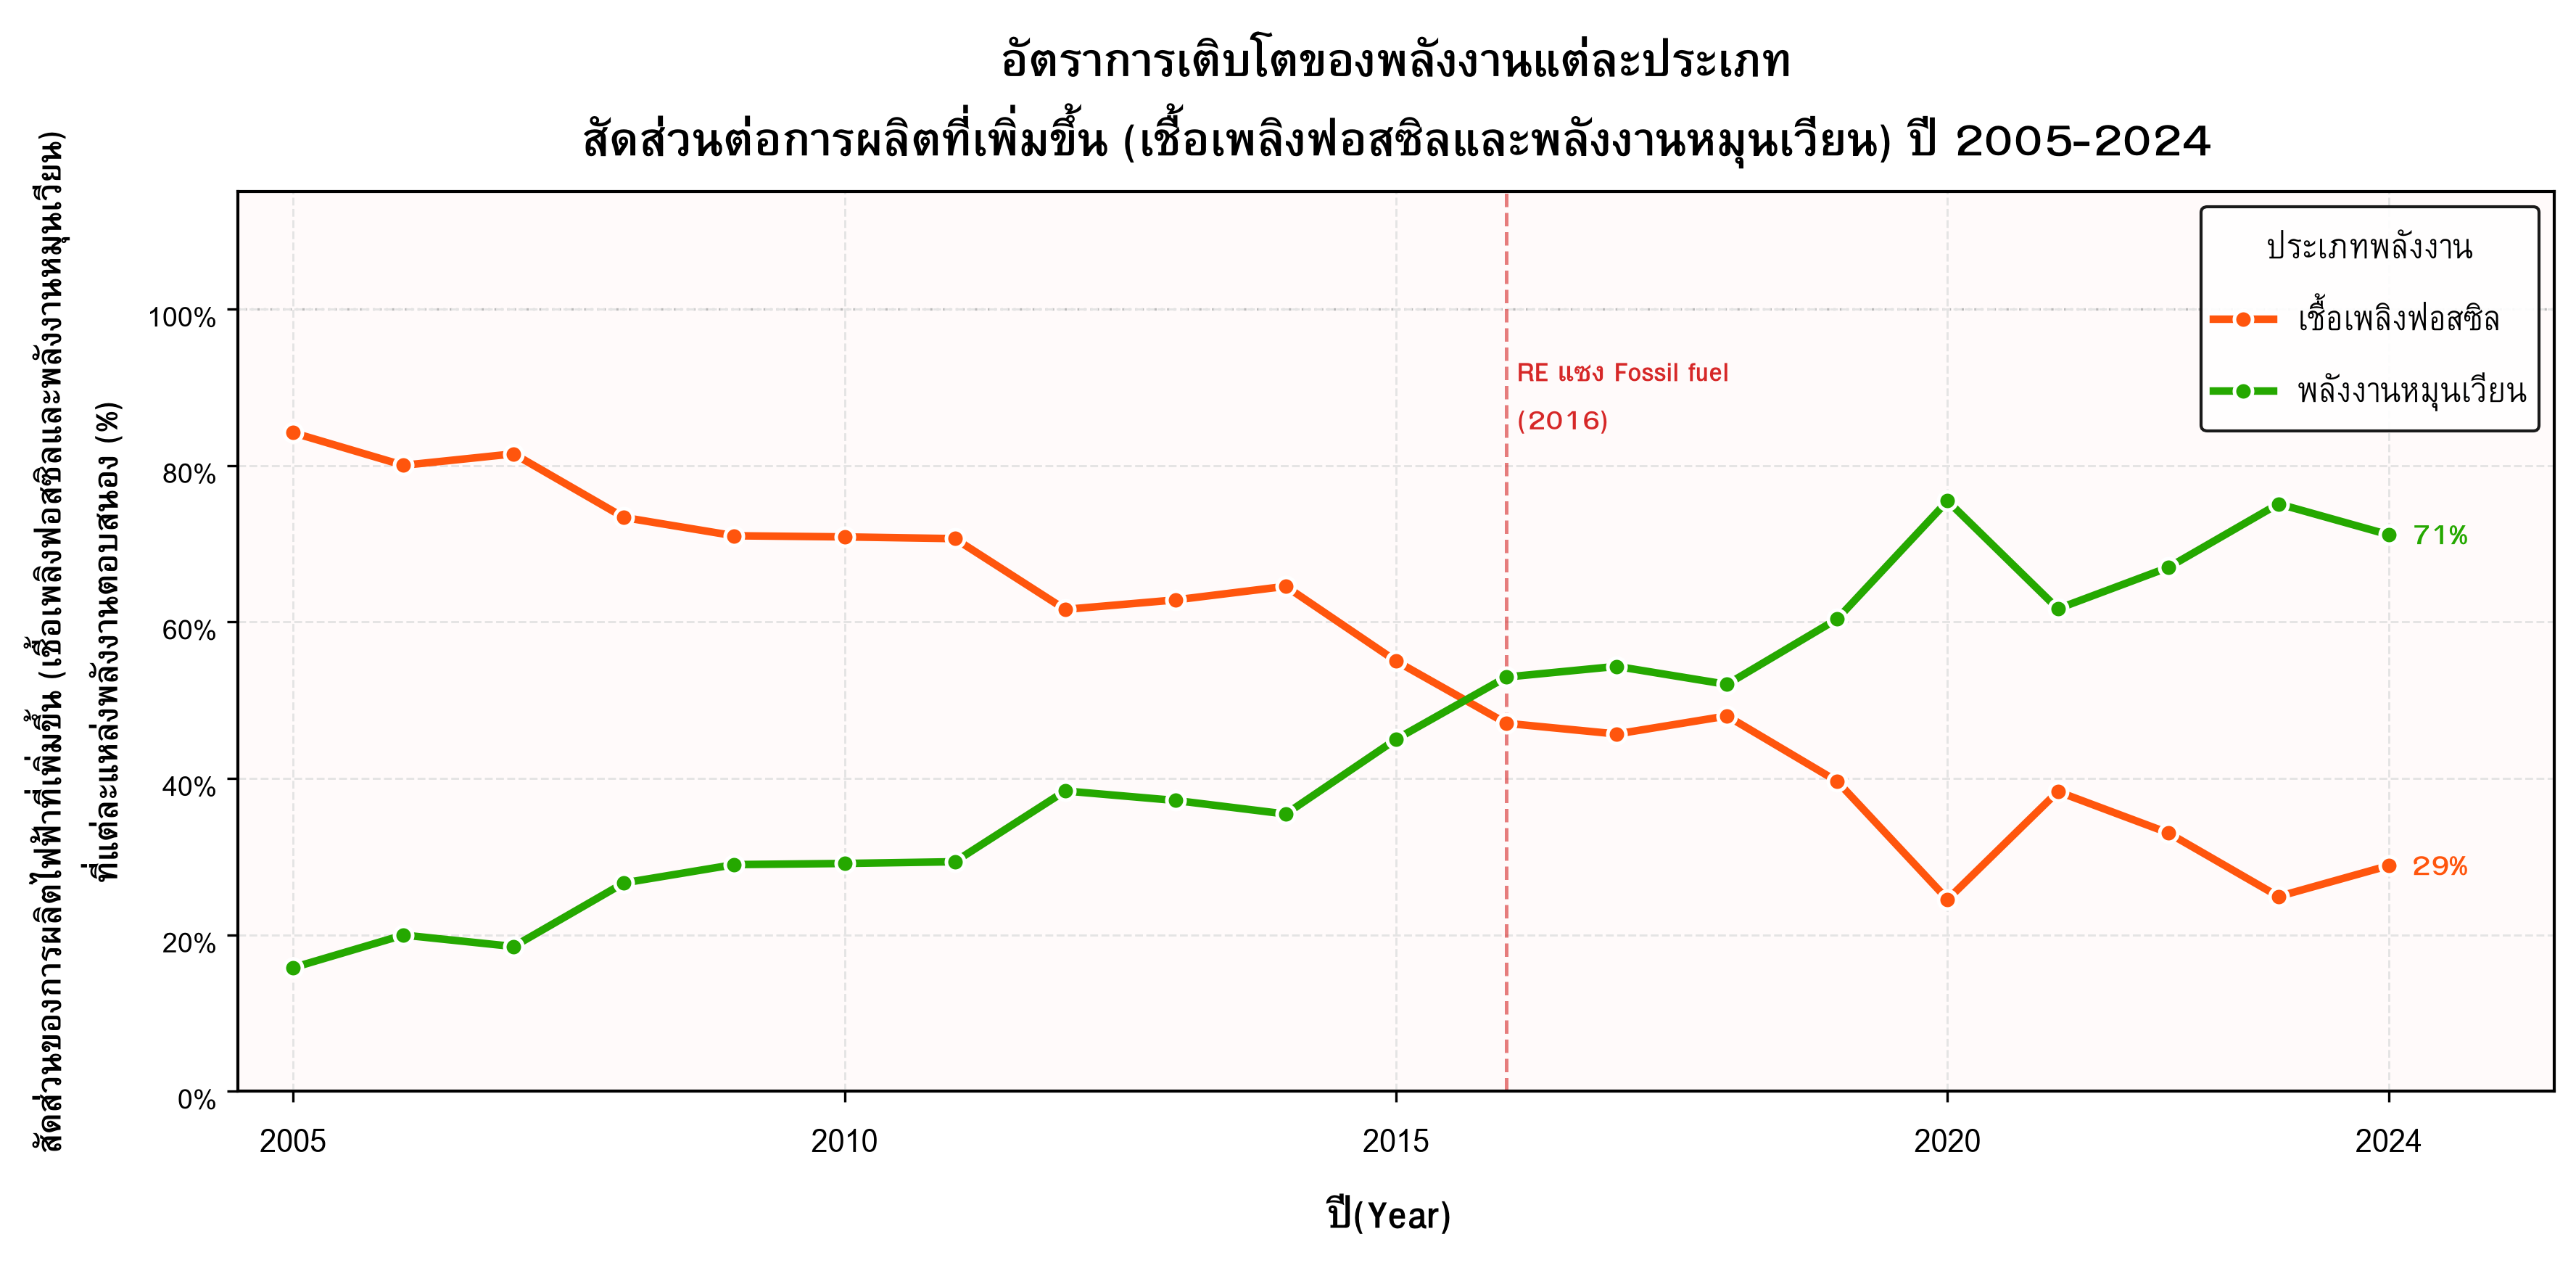

In [8]:

world = df.groupby('year').agg(
    coal     = ('coal_electricity',            'sum'),
    gas      = ('gas_electricity',             'sum'),
    oil      = ('oil_electricity',             'sum'),
    solar    = ('solar_electricity',           'sum'),
    wind     = ('wind_electricity',            'sum'),
    hydro    = ('hydro_electricity',           'sum'),
    other_re = ('other_renewable_electricity', 'sum'),
).reset_index()

world['Fossil']  = world['coal'] + world['gas'] + world['oil']
world['RE']      = world['solar'] + world['wind'] + world['hydro'] + world['other_re']
world['Total']   = world['Fossil'] + world['RE']

world = world[world['year'].between(2000, 2024)].reset_index(drop=True)
world = world.set_index('year')

# ── คำนวณ 5-year rolling share ───────────────────────────────
results = []
for y in range(2005, 2025):
    if y-5 not in world.index or y not in world.index:
        continue
    d_total   = world.loc[y, 'Total']   - world.loc[y-5, 'Total']
    d_fossil  = world.loc[y, 'Fossil']  - world.loc[y-5, 'Fossil']
    d_re      = world.loc[y, 'RE']      - world.loc[y-5, 'RE']
    if d_total == 0:
        continue
    results.append({
        'year':    y,
        'Fossil':  d_fossil  / d_total * 100,
        'RE':      d_re      / d_total * 100,
    })

roll = pd.DataFrame(results)

# ── สี ────────────────────────────────────────────────────────
C_FOSSIL  = '#FF550D'   # ชุดสีเดียวกับ Figure 3
C_RE      = '#25A800'

# ── Figure ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6), facecolor='white', dpi=300)
ax.set_facecolor("#fffafa")

# เส้น reference
ax.axhline(100, color='#bbbbbb', lw=0.8, ls=':', zorder=1)
ax.axhline(0,   color='#888888', lw=1.0, ls='-', zorder=1)

# วาด 2 เส้น
for col, color, label in [
    ('Fossil',  C_FOSSIL,  'เชื้อเพลิงฟอสซิล'),
    ('RE',      C_RE,      'พลังงานหมุนเวียน'),
]:
    ax.plot(roll['year'], roll[col],
            color=color, lw=2.5, marker='o',
            markersize=6, markerfacecolor=color,
            markeredgecolor='white', markeredgewidth=1.2,
            label=label, zorder=4)

    # label ปลายเส้น
    last = roll.iloc[-1]
    ax.text(last['year'] + 0.2, last[col],
            f"{last[col]:.0f}%",
            fontsize=9, color=color, fontweight='bold',
            va='center', zorder=5)

# จุดที่ RE แซง Fossil
cross_year = None
for i in range(len(roll)-1):
    if roll.iloc[i]['RE'] < roll.iloc[i]['Fossil'] and \
       roll.iloc[i+1]['RE'] >= roll.iloc[i+1]['Fossil']:
        cross_year = roll.iloc[i+1]['year']
        break

if cross_year:
    ax.axvline(cross_year, color='#D62828', lw=1.2,
               ls='--', alpha=0.6, zorder=2)
    ax.text(cross_year + 0.1, 95,
            f'RE แซง Fossil fuel\n({cross_year:.0f})',
            fontsize=8.5, color='#D62828',
            va='top', fontweight='bold')

# ── Axes ──────────────────────────────────────────────────────
ax.set_xlim(2004.5, 2025.5)
ax.set_ylim(0, 115)

# แกน x ทีละ 5 ปี
ax.set_xticks([2005, 2010, 2015, 2020, 2024])
ax.set_xticklabels(['2005', '2010', '2015', '2020', '2024'], fontsize=10)

ax.set_yticks(range(0, 120, 20))
ax.set_yticklabels([f'{v}%' for v in range(0, 120, 20)], fontsize=9)

ax.set_xlabel('ปี(Year) ', fontsize=12,fontweight='bold')
ax.set_ylabel('สัดส่วนของการผลิตไฟฟ้าที่เพิ่มขึ้น (เชื้อเพลิงฟอสซิลและพลังงานหมุนเวียน)\nที่แต่ละแหล่งพลังงานตอบสนอง (%)', fontsize=10,fontweight='bold')
ax.set_title('อัตราการเติบโตของพลังงานแต่ละประเภท\n'
             'สัดส่วนต่อการผลิตที่เพิ่มขึ้น (เชื้อเพลิงฟอสซิลและพลังงานหมุนเวียน) ปี 2005-2024',
             fontsize=14,fontweight='bold', pad=12)

ax.grid(True, which='major', color='#E4E4E4', linewidth=0.7, linestyle='--', zorder=1)
for sp in ax.spines.values():
    sp.set_visible(True)
    sp.set_color('#000000')
    sp.set_linewidth(1.0)
# Legend
ax.legend(loc='upper right', fontsize=10, framealpha=0.9,
          edgecolor="#010101",
          title='ประเภทพลังงาน', title_fontsize=10)

plt.tight_layout()
plt.savefig('figure4.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

#figure 5

ประเทศที่แสดงชื่อ:
    continent                      quadrant             country  gen_2024
       Africa การขยายตัวของเชื้อเพลิงฟอสซิล            Eswatini      0.61
       Africa การขยายตัวของเชื้อเพลิงฟอสซิล             Lesotho      0.00
       Africa                การเปลี่ยนผ่าน            Ethiopia     25.20
       Africa                การเปลี่ยนผ่าน               Kenya     13.26
       Africa                การเปลี่ยนผ่าน              Malawi      1.83
       Africa                  การเพิ่มเติม        South Africa    247.52
       Africa                  การเพิ่มเติม               Egypt    237.39
       Africa                  การเพิ่มเติม             Algeria     96.36
         Asia การขยายตัวของเชื้อเพลิงฟอสซิล               Syria     24.88
         Asia                การเปลี่ยนผ่าน          Kyrgyzstan     15.77
         Asia                การเปลี่ยนผ่าน               Nepal     11.13
         Asia                การเปลี่ยนผ่าน             Lebanon      5.34
         Asia      

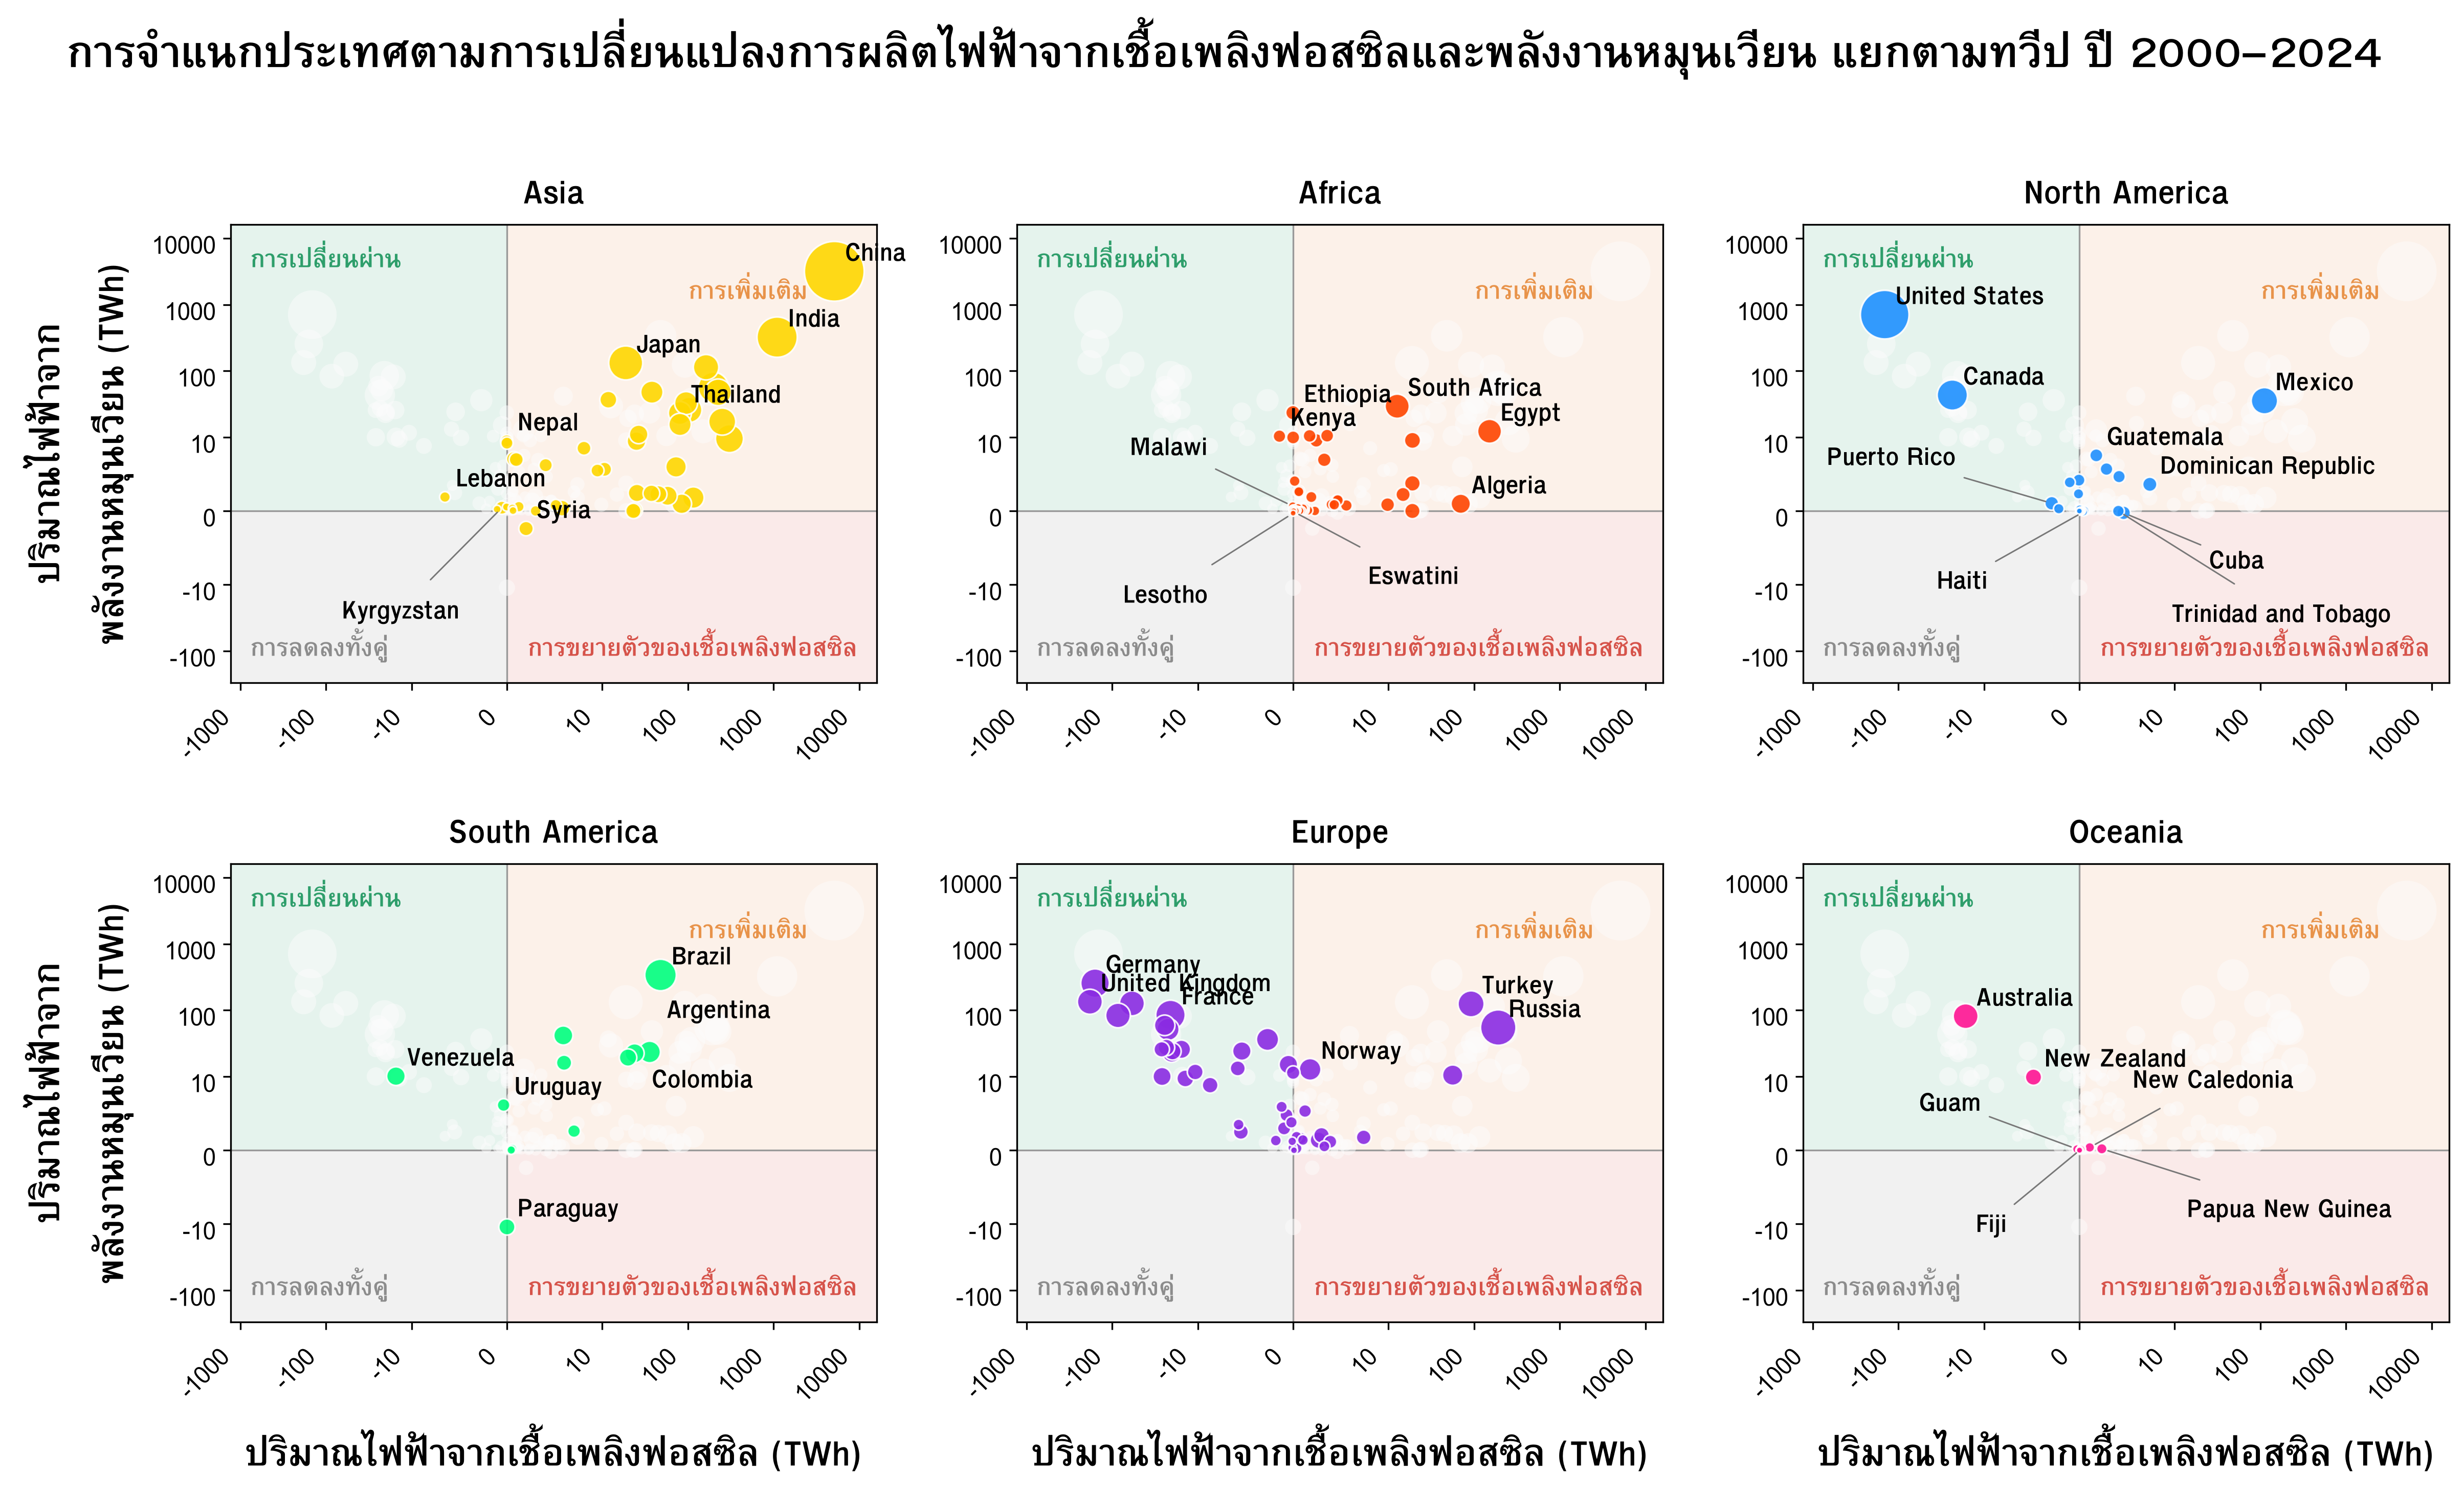

In [9]:
# Prepare Figure 5 directly from the imported df.
figure5_source = df.copy()

figure5_source['fossil'] = figure5_source['coal_electricity'] + figure5_source['gas_electricity'] + figure5_source['oil_electricity']
figure5_source['renewables'] = (figure5_source['hydro_electricity'] + figure5_source['solar_electricity']
                     + figure5_source['wind_electricity'] + figure5_source['other_renewable_electricity'])

p0 = figure5_source[figure5_source.year == 2000][['country', 'iso_code', 'continent', 'fossil', 'renewables', 'electricity_generation']] \
        .rename(columns={'fossil': 'fossil_2000', 'renewables': 'ren_2000'})
p1 = figure5_source[figure5_source.year == 2024][['country', 'fossil', 'renewables', 'electricity_generation']] \
        .rename(columns={'fossil': 'fossil_2024', 'renewables': 'ren_2024',
                          'electricity_generation': 'gen_2024'})

figure5_data = p0.merge(p1, on='country').dropna(subset=['electricity_generation', 'gen_2024'])

figure5_data['delta_fossil'] = figure5_data['fossil_2024'] - figure5_data['fossil_2000']
figure5_data['delta_ren'] = figure5_data['ren_2024'] - figure5_data['ren_2000']

# ---------- 2. จัด 4 quadrant ----------
def figure5_quadrant(row):
    if row['delta_fossil'] >= 0 and row['delta_ren'] >= 0: return 'การเพิ่มเติม'          # top-right
    if row['delta_fossil'] < 0 and row['delta_ren'] >= 0: return 'การเปลี่ยนผ่าน'         # top-left
    if row['delta_fossil'] >= 0 and row['delta_ren'] < 0: return 'การขยายตัวของเชื้อเพลิงฟอสซิล'   # bottom-right
    return 'การลดลงทั้งคู่'

figure5_data['quadrant'] = figure5_data.apply(figure5_quadrant, axis=1)

# ---------- 2. สีตามทวีป ----------
CONTINENT_COLORS = {          # ชุดเดียวกับ Figure 5
    'Asia':          '#FFD700',
    'North America': '#1e90ff',
    'Europe':        '#8A2BE2',
    'Africa':        '#FF4500',
    'South America': '#00FF7F',
    'Oceania':       '#FF1493',
}
GRAY = "#fcfcfc"

# ---------- 3. ขนาด bubble จาก electricity_generation (gen_2024) - scale เดียวกันทุกกราฟย่อย ----------
FIG6_SIZE = (16.5, 10.5)   # ย่อจาก 22x14 ให้ตัวอักษรใหญ่ขึ้นเมื่อแสดงบน GitHub
FIG6_SCALE = (FIG6_SIZE[0] / 22) ** 2   # ย่อฟองตามพื้นที่รูป ให้สัดส่วนเท่าเดิม
size_raw = np.sqrt(figure5_data['gen_2024'].clip(lower=0.01))
size_min, size_max = 15 * FIG6_SCALE, 1400 * FIG6_SCALE
figure5_data['bubble_size'] = np.interp(size_raw, (size_raw.min(), size_raw.max()), (size_min, size_max))

# ---------- 4. เลือกป้ายชื่อ: 3 ประเทศใหญ่สุด (ตาม gen_2024) ต่อจตุภาคในแต่ละทวีป + ไทย (ในทวีปเอเชีย) ----------
LABEL_TOP_N = 3
top_idx = (figure5_data.groupby(['continent', 'quadrant'])['gen_2024']
             .nlargest(LABEL_TOP_N).index.get_level_values(-1))
label_idx = set(top_idx)
thailand_idx = figure5_data[figure5_data['country'] == 'Thailand'].index
label_idx.update(thailand_idx)
figure5_data['show_label'] = figure5_data.index.isin(label_idx)

print("ประเทศที่แสดงชื่อ:")
print(figure5_data[figure5_data['show_label']][['continent', 'quadrant', 'country', 'gen_2024']]
      .sort_values(['continent', 'quadrant', 'gen_2024'], ascending=[True, True, False])
      .to_string(index=False))

# ---------- 5. แกน (scale เดียวกันทุกกราฟ แบบ symlog เหมือน Figure 7) ----------
LINTHRESH = 10
XLIM_4 = (-1300, 16000)
YLIM_4 = (-300, 16000)

X_TICKS = [-1000, -100, -10, 0, 10, 100, 1000, 10000]
Y_TICKS = [-100, -10, 0,10, 100, 1000, 10000]

# ---------- 5b. สี quadrant: ใช้ชุดเดียวกับกราฟ Bubble รวม (Cell 3) ----------
COLOR_ORANGE = '#E8934A'   # การเพิ่มเติม
COLOR_GREEN  = '#2E9E6B'   # การเปลี่ยนผ่าน
COLOR_RED    = '#D6534A'   # การขยายตัวของเชื้อเพลิงฟอสซิล
COLOR_GRAY   = '#8C8C8C'   # การลดลงทั้งคู่

QUADRANT_COLOR = {
    'การเพิ่มเติม': COLOR_ORANGE,
    'การเปลี่ยนผ่าน': COLOR_GREEN,
    'การขยายตัวของเชื้อเพลิงฟอสซิล': COLOR_RED,
    'การลดลงทั้งคู่': COLOR_GRAY,
}
QUADRANT_BG_ALPHA = 0.12   # เท่ากับกราฟ Bubble รวม

# ป้ายชื่อ quadrant บนพื้นหลังสี (ครบทั้ง 4 quadrant)
# (x, y, ha, va, พิกัด) - 'axes' = สัดส่วนของกรอบกราฟ (วางชิดมุมที่ไม่มีฟอง), 'data' = ค่าบนแกน
quadrant_label_pos = {
    'การเพิ่มเติม': (500, 1600, 'center', 'center', 'data'),   # เลี่ยงฟองจีน
    'การเปลี่ยนผ่าน': (0.03, 0.97, 'left', 'top', 'axes'),
    'การขยายตัวของเชื้อเพลิงฟอสซิล': (0.97, 0.03, 'right', 'bottom', 'axes'),
    'การลดลงทั้งคู่': (0.03, 0.03, 'left', 'bottom', 'axes'),
}

def add_quadrant_labels(ax, positions):
    for label, (x, y, ha, va, coords) in positions.items():
        ax.text(x, y, label, transform=ax.transAxes if coords == 'axes' else ax.transData,
                fontsize=10.5, fontfamily=GARUDA, fontweight='bold',
                color=QUADRANT_COLOR[label], alpha=1.0,
                ha=ha, va=va, zorder=1.5)

def add_quadrant_bg(ax, xlim, ylim):
    ax.add_patch(Rectangle((0, 0), xlim[1], ylim[1],
                            facecolor=QUADRANT_COLOR['การเพิ่มเติม'], edgecolor='none',
                            alpha=QUADRANT_BG_ALPHA, zorder=0))
    ax.add_patch(Rectangle((xlim[0], 0), 0 - xlim[0], ylim[1],
                            facecolor=QUADRANT_COLOR['การเปลี่ยนผ่าน'], edgecolor='none',
                            alpha=QUADRANT_BG_ALPHA, zorder=0))
    ax.add_patch(Rectangle((0, ylim[0]), xlim[1], 0 - ylim[0],
                            facecolor=QUADRANT_COLOR['การขยายตัวของเชื้อเพลิงฟอสซิล'], edgecolor='none',
                            alpha=QUADRANT_BG_ALPHA, zorder=0))
    ax.add_patch(Rectangle((xlim[0], ylim[0]), 0 - xlim[0], 0 - ylim[0],
                            facecolor=QUADRANT_COLOR['การลดลงทั้งคู่'], edgecolor='none',
                            alpha=QUADRANT_BG_ALPHA, zorder=0))

# ---------- 6. วาดกราฟ 2x3 ----------
continents = ['Asia', 'Africa', 'North America', 'South America', 'Europe', 'Oceania']
fig, axes = plt.subplots(2, 3, figsize=FIG6_SIZE, dpi=300)
axes = axes.flatten()

# ปรับตำแหน่ง offset ของป้ายชื่อประเทศเฉพาะจุดที่ชิด/ทับกัน (หน่วย points จากจุดศูนย์กลางฟอง)
LABEL_OFFSET_OVERRIDES = {
    'Argentina': (8, 16),
    'Colombia': (8, -16),
    # ประเทศเล็กที่กระจุกใกล้จุด 0 -> ดึงป้ายออกมาพร้อมเส้นโยง
    'Kyrgyzstan': (-20, -48),
    'Malawi': (-40, 28), 'Eswatini': (35, -30), 'Lesotho': (-40, -38),
    'Haiti': (-45, -32), 'Cuba': (40, -22), 'Trinidad and Tobago': (25, -48),
    'Puerto Rico': (-45, 22),
    'Guam': (-45, 22), 'Fiji': (-35, -35), 'New Caledonia': (20, 32), 'Papua New Guinea': (40, -28),
}
LEADER_LINE_MIN = 20   # ถ้า offset ไกลกว่านี้ (points) จะวาดเส้นโยงไปที่ฟอง
DEFAULT_LABEL_OFFSET = (5, 5)

for i, cont in enumerate(continents):
    ax = axes[i]
    color = CONTINENT_COLORS[cont]

    # ทวีปอื่น -> สีเทาอ่อน (พื้นหลัง)
    other = figure5_data[figure5_data['continent'] != cont]
    ax.scatter(other['delta_fossil'], other['delta_ren'], s=other['bubble_size'],
               color=GRAY, alpha=0.5, edgecolor='none', zorder=2)

    # ทวีปนี้ -> สีของทวีป (ขอบขาวแบบ Figure 5 / ฟองใหญ่วาดก่อน ฟองเล็กอยู่บน)
    sub = figure5_data[figure5_data['continent'] == cont].sort_values('gen_2024', ascending=False)
    ax.scatter(sub['delta_fossil'], sub['delta_ren'], s=sub['bubble_size'],
               color=color, alpha=0.9, edgecolor='white', linewidth=0.8, zorder=3)

    # เส้นแบ่ง quadrant ที่ 0
    ax.axhline(0, color='#999999', linewidth=0.8, zorder=1)
    ax.axvline(0, color='#999999', linewidth=0.8, zorder=1)

    # พื้นหลังสี quadrant
    add_quadrant_bg(ax, XLIM_4, YLIM_4)
    add_quadrant_labels(ax, quadrant_label_pos)

    # ป้ายชื่อประเทศ (เฉพาะของทวีปนี้) - แก้ทับกัน + ตัวหนา
    labels = sub[sub['show_label']]
    for _, r in labels.iterrows():
        dx, dy = LABEL_OFFSET_OVERRIDES.get(r['country'], DEFAULT_LABEL_OFFSET)
        far = max(abs(dx), abs(dy)) >= LEADER_LINE_MIN
        ax.annotate(r['country'], (r['delta_fossil'], r['delta_ren']),
                    xytext=(dx, dy), textcoords='offset points',
                    ha='right' if dx < 0 else 'left',
                    va='center' if far else 'baseline',
                    fontsize=11.5, fontfamily=GARUDA, fontweight='bold',
                    color='#000000', zorder=4,
                    arrowprops=dict(arrowstyle='-', color='#777777', lw=0.7,
                                    shrinkA=2, shrinkB=3) if far else None)

    # ชื่อทวีป (เหนือกราฟ)
    ax.set_title(cont, fontsize=15, fontfamily=GARUDA, fontweight='bold', color='#000000', pad=10)

    # scale และแกน
    ax.set_xscale('symlog', linthresh=LINTHRESH, linscale=1)
    ax.set_yscale('symlog', linthresh=LINTHRESH, linscale=1)
    ax.set_xlim(XLIM_4)
    ax.set_ylim(YLIM_4)
    ax.set_xticks(X_TICKS)
    ax.set_yticks(Y_TICKS)
    ax.set_xticklabels([f"{t:g}" for t in X_TICKS], fontsize=11, rotation=45, ha='right')
    ax.set_yticklabels([f"{t:g}" for t in Y_TICKS], fontsize=11)
    ax.grid(True, which='major', color='None', linewidth=0.6, zorder=1)

    # แสดงชื่อแกนเฉพาะขอบนอกของตาราง (ซ้ายสุด / แถวล่างสุด) เพื่อลดความรก
    row, col = divmod(i, 3)
    if col == 0:
        ax.set_ylabel('ปริมาณไฟฟ้าจาก\nพลังงานหมุนเวียน (TWh)', fontsize=16, fontfamily=GARUDA, fontweight='bold')
    if row == 1:
        ax.set_xlabel('ปริมาณไฟฟ้าจากเชื้อเพลิงฟอสซิล (TWh)', fontsize=16, fontfamily=GARUDA, fontweight='bold')

# ---------- หัวข้อรวม ----------
fig.suptitle('การจำแนกประเทศตามการเปลี่ยนแปลงการผลิตไฟฟ้าจากเชื้อเพลิงฟอสซิลและพลังงานหมุนเวียน แยกตามทวีป ปี 2000–2024',
             fontsize=19, fontfamily=GARUDA, fontweight='bold', color='#000000', x=0.5, y=0.965, ha='center')

plt.tight_layout(rect=[0.012, 0.035, 0.995, 0.955])
plt.savefig('figure6.png', dpi=300, facecolor='white')
print("saved")

#Figure 6

จำนวนประเทศที่มีข้อมูลครบ 2000 & 2024: 194
quadrant
Addition            132
Transition           53
Fossil Expansion      8
Decline               1
Name: count, dtype: int64

=== % นับประเทศ ===
quadrant       Transition  Addition  Fossil Expansion  Decline
continent                                                     
Africa               10.0      86.0               4.0      0.0
Asia                 11.4      86.4               2.3      0.0
Europe               64.4      33.3               0.0      2.2
North America        27.6      58.6              13.8      0.0
Oceania              28.6      71.4               0.0      0.0
South America        16.7      75.0               8.3      0.0

=== % ถ่วงด้วย Δren ===
quadrant       Transition  Addition  Fossil Expansion  Decline
continent                                                     
Africa               21.6      78.4               0.0      0.0
Asia                  0.3      99.7               0.0      0.0
Europe               82.

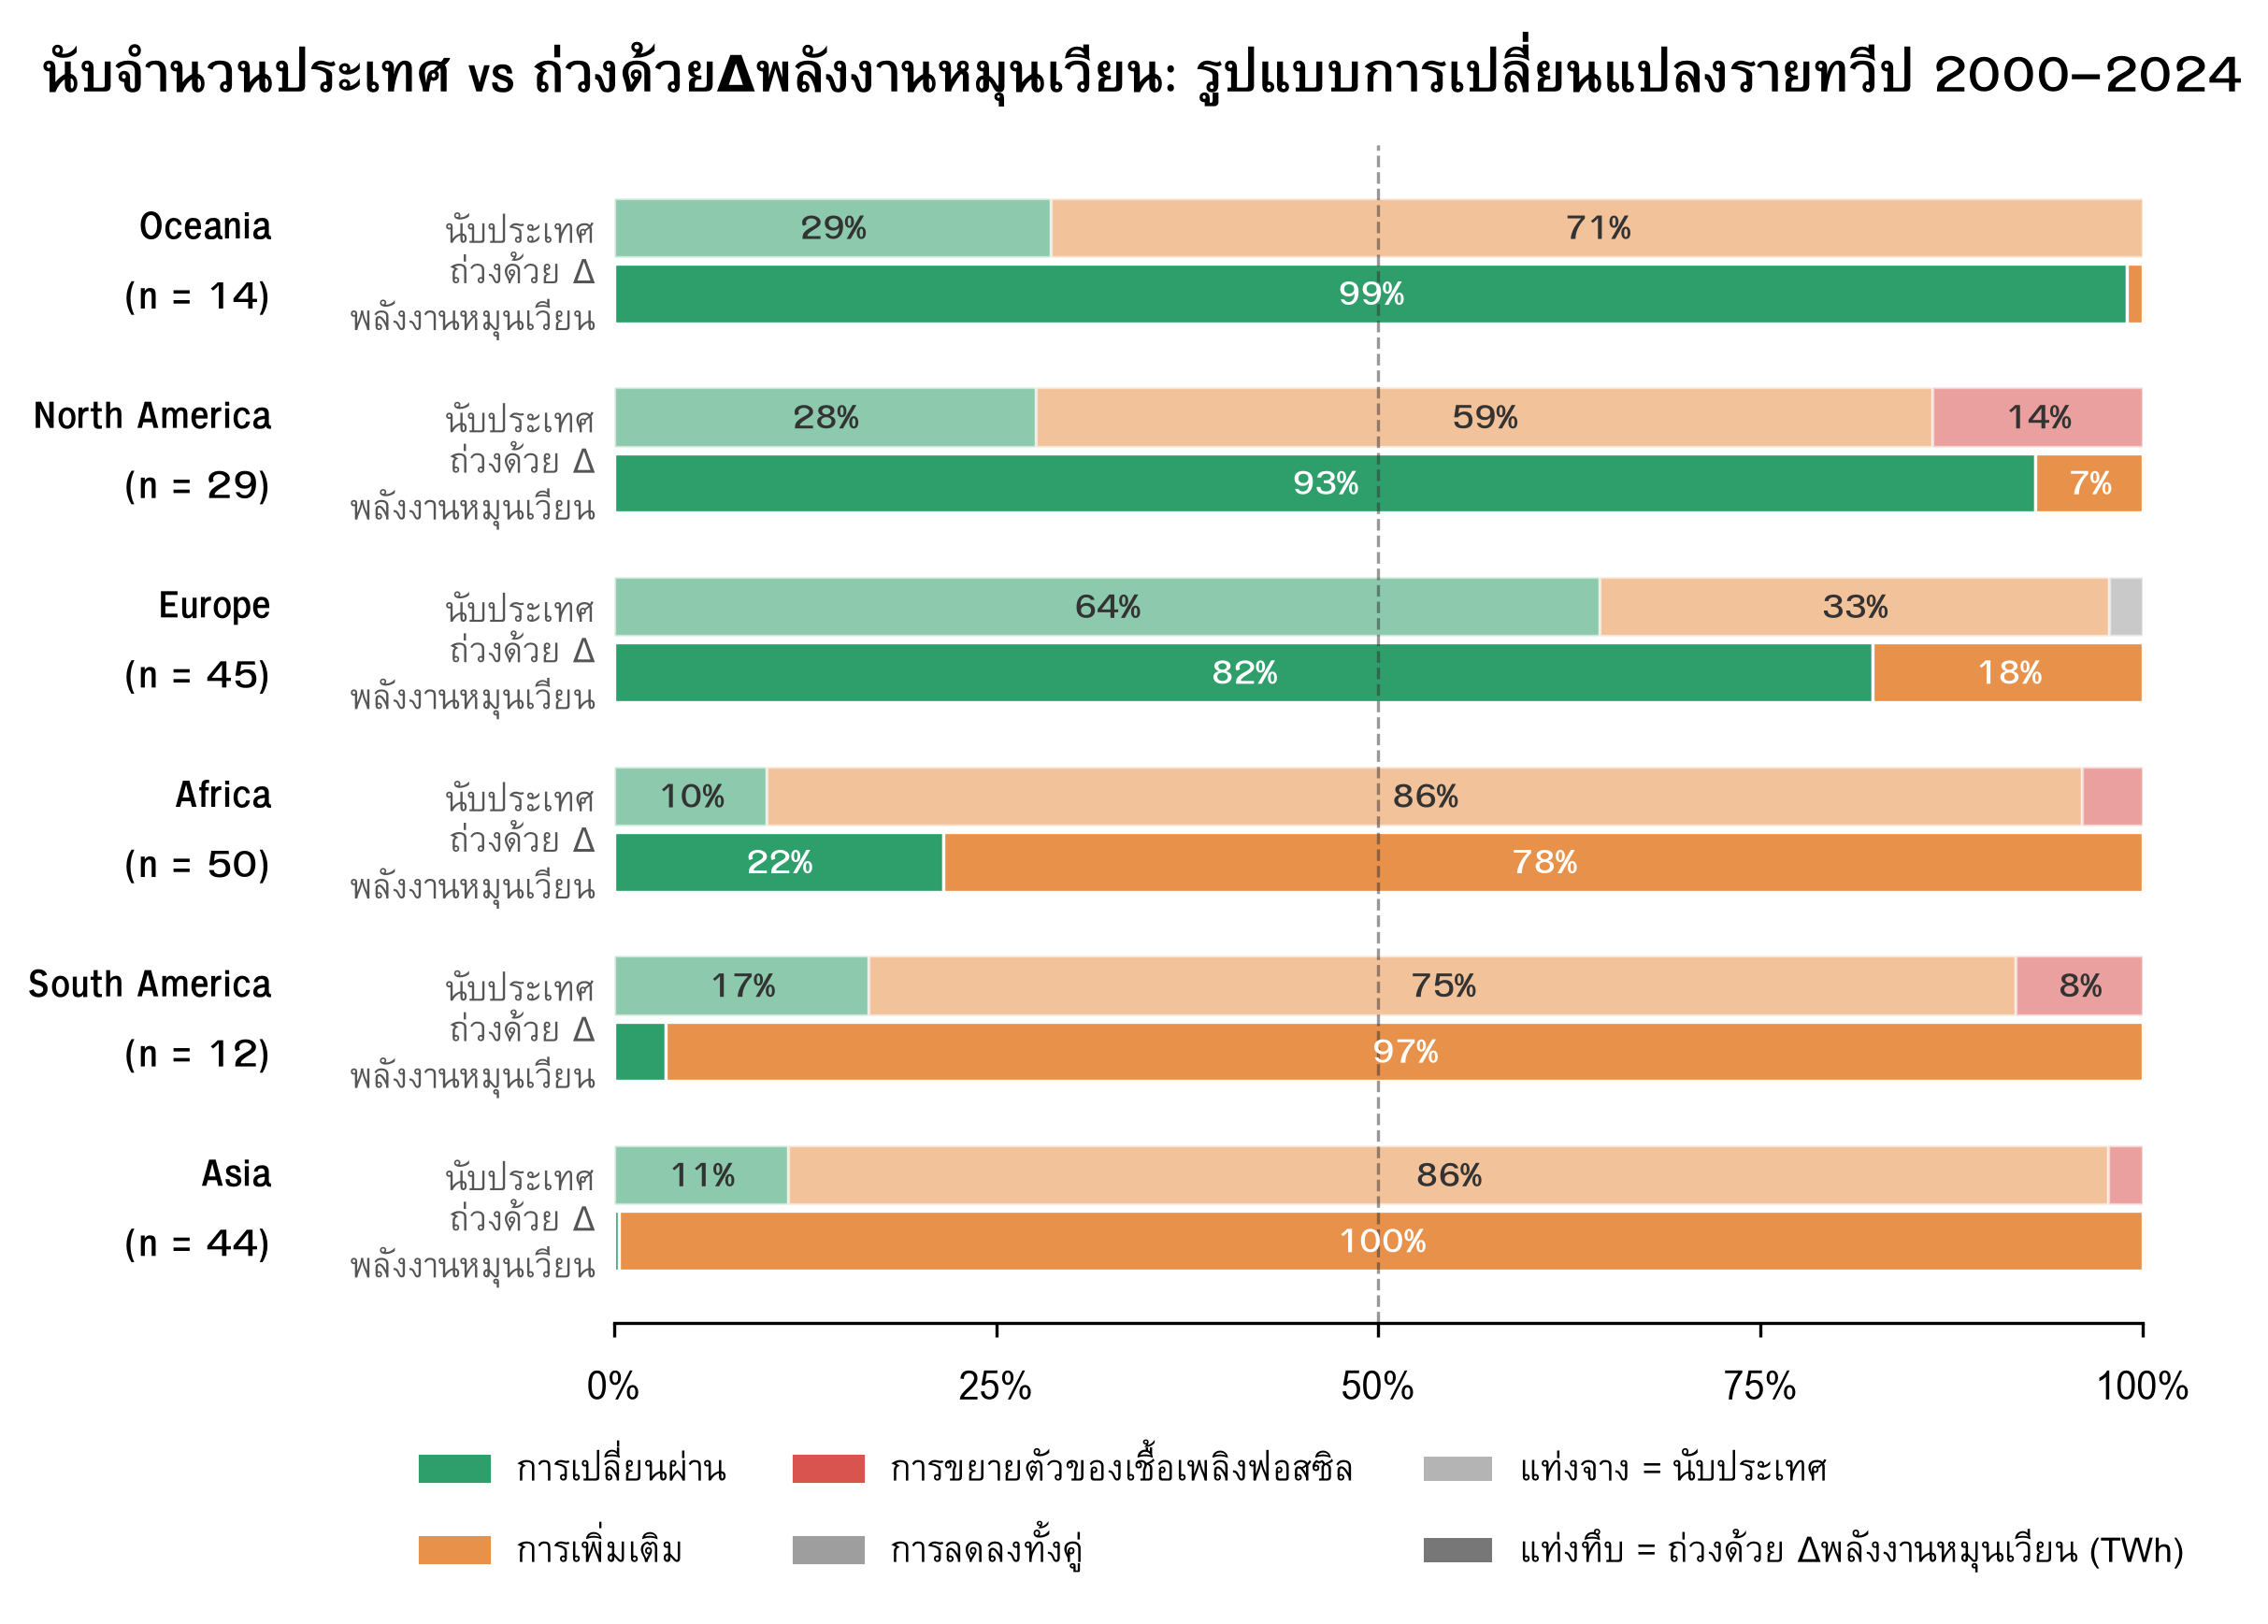

In [ ]:
"""
Figure 6: นับจำนวนประเทศ vs ถ่วงด้วย Δพลังงานหมุนเวียน (Δren) รายทวีป
"""

# ============================================================
# 0. ตั้งค่า
# ============================================================
HAS_CONTINENT_COL = True   # True ถ้าไฟล์ cleaned มีคอลัมน์ continent อยู่แล้ว
YEAR_START, YEAR_END = 2000, 2024
FIG_W = 9.5                # ความกว้างรูป (นิ้ว) ลดลงเพื่อให้แท่งแนวนอนสั้นลง

FOSSIL_COLS = ["coal_electricity", "gas_electricity", "oil_electricity"]
# ปรับให้ตรงกับนิยาม "renewable" ที่ใช้จริงในโน้ตบุ๊กหลัก (Figure 1-5)
REN_COLS = ["solar_electricity", "wind_electricity", "hydro_electricity",
            "other_renewable_electricity"]

QUADRANTS = ["Transition", "Addition", "Fossil Expansion", "Decline"]
LABELS_TH = {"Transition": "การเปลี่ยนผ่าน", "Addition": "การเพิ่มเติม",
             "Fossil Expansion": "การขยายตัวของเชื้อเพลิงฟอสซิล",
             "Decline": "การลดลงทั้งคู่"}
COLORS = {"Transition": "#2E9E6B", "Addition": "#E8914A",
          "Fossil Expansion": "#D9534F", "Decline": "#9E9E9E"}
CONTINENT_LABEL = {"Europe": "Europe", "North America": "North America",
                    "Oceania": "Oceania", "South America": "South America",
                    "Asia": "Asia", "Africa": "Africa"}

plt.rcParams["font.family"] = ["Garuda", "Loma", "DejaVu Sans"]


# ============================================================
# 1. โหลดข้อมูล + จับคู่ทวีป (ข้ามได้ถ้า HAS_CONTINENT_COL = True)
# ============================================================
MANUAL_CONTINENT = {
    "East Timor": "Asia",
    "Western Sahara": "Africa",
    "Netherlands Antilles": "North America",
}


def map_continent(country, iso3):
    if country in MANUAL_CONTINENT:
        return MANUAL_CONTINENT[country]
    import pycountry_convert as pc
    try:
        iso2 = pc.country_alpha3_to_country_alpha2(iso3)
        code = pc.country_alpha2_to_continent_code(iso2)
        return {"AF": "Africa", "AS": "Asia", "EU": "Europe",
                "NA": "North America", "OC": "Oceania",
                "SA": "South America", "AN": "Antarctica"}.get(code)
    except Exception:
        return None


def load_data(source_df):
    d = source_df[source_df["iso_code"].notna()].copy()
    if not HAS_CONTINENT_COL:
        d["continent"] = d.apply(
            lambda r: map_continent(r["country"], r["iso_code"]), axis=1)
    d = d[d["continent"] != "Antarctica"]
    return d


# ============================================================
# 2. คำนวณ Δfossil, Δren ต่อประเทศ (2000→2024) แล้วจำแนกกลุ่ม
# ============================================================
def classify_countries(d):
    d = d[d["year"].isin([YEAR_START, YEAR_END])].copy()
    d["fossil"] = d[FOSSIL_COLS].sum(axis=1, min_count=1)
    d["ren"] = d[REN_COLS].sum(axis=1, min_count=1)

    p_fossil = d.pivot(index="country", columns="year", values="fossil")
    p_ren = d.pivot(index="country", columns="year", values="ren")

    # เก็บเฉพาะประเทศที่มีข้อมูลครบทั้งสองปี ทั้ง fossil และ ren
    complete = p_fossil.dropna().index.intersection(p_ren.dropna().index)

    cont_map = d.drop_duplicates("country").set_index("country")["continent"]

    res = pd.DataFrame({
        "continent": cont_map.loc[complete],
        "d_fossil": p_fossil.loc[complete, YEAR_END] - p_fossil.loc[complete, YEAR_START],
        "d_ren": p_ren.loc[complete, YEAR_END] - p_ren.loc[complete, YEAR_START],
    })

    def quadrant(row):
        if row["d_ren"] >= 0 and row["d_fossil"] < 0:
            return "Transition"
        if row["d_ren"] >= 0 and row["d_fossil"] >= 0:
            return "Addition"
        if row["d_ren"] < 0 and row["d_fossil"] >= 0:
            return "Fossil Expansion"
        return "Decline"

    res["quadrant"] = res.apply(quadrant, axis=1)
    return res


# ============================================================
# 3. สร้างตาราง % นับประเทศ vs % ถ่วงด้วย Δren
# ============================================================
def build_percentages(res):
    count_pct = pd.crosstab(res["continent"], res["quadrant"], normalize="index") * 100

    # ถ่วงด้วย Δren: ประเทศกลุ่ม Fossil Expansion มี d_ren ติดลบ (renewable ลดลง)
    # -> clip เป็น 0 ก่อนคำนวณสัดส่วน เพราะเป็นสัดส่วนที่เล็กมากเทียบกับผลรวมทวีป
    #    (ตรวจสอบขนาดจริงก่อนใช้ — ถ้าทวีปไหนมีค่าลบมากผิดปกติ ต้องดูเป็นกรณีพิเศษ)
    raw = res.groupby(["continent", "quadrant"])["d_ren"].sum().unstack(fill_value=0)
    raw_clipped = raw.clip(lower=0)
    weighted_pct = raw_clipped.div(raw_clipped.sum(axis=1), axis=0) * 100

    count_pct = count_pct.reindex(columns=QUADRANTS, fill_value=0)
    weighted_pct = weighted_pct.reindex(columns=QUADRANTS, fill_value=0).fillna(0)
    return count_pct, weighted_pct


# ============================================================
# 4. วาดกราฟ
# ============================================================
def plot(count_pct, weighted_pct, n_per_continent, save_path="images/figure6b.png"):
    order = weighted_pct["Transition"].sort_values().index.tolist()

    plot_scale = 0.8
    fig, ax = plt.subplots(figsize=(FIG_W * plot_scale, 7.5 * plot_scale), dpi=300)
    bar_h, gap = 0.36, 0.04
    ypos = np.arange(len(order)) * 1.15

    for i, cont in enumerate(order):
        rows = [(count_pct, ypos[i] + bar_h / 2 + gap / 2, "นับประเทศ", 0.55),
                (weighted_pct, ypos[i] - bar_h / 2 - gap / 2, "ถ่วงด้วย Δ\nพลังงานหมุนเวียน", 1.0)]
        for table, y, row_label, alpha in rows:
            left = 0
            for q in QUADRANTS:
                v = table.loc[cont, q]
                if v <= 0:
                    continue
                ax.barh(y, v, left=left, height=bar_h, color=COLORS[q],
                        alpha=alpha, edgecolor="white", linewidth=0.8)
                if v >= 6:
                    ax.text(left + v / 2, y, f"{v:.0f}%", ha="center", va="center",
                            fontsize=10.5 * plot_scale, color="white" if alpha == 1.0 else "#333",
                            fontweight="bold")
                left += v
            # ระยะป้ายด้านซ้ายกำหนดเป็น point เพื่อไม่ให้ชนกันเมื่อปรับความกว้างกราฟ
            ax.annotate(row_label, (0, y), xytext=(-6 * plot_scale, 0), textcoords="offset points",
                        ha="right", va="center", fontsize=10.5 * plot_scale, color="#555", linespacing=0.85)
        ax.annotate(f"{CONTINENT_LABEL.get(cont, cont)}\n(n = {n_per_continent[cont]})", (0, ypos[i]),
                    xytext=(-110 * plot_scale, 0), textcoords="offset points",
                    ha="right", va="center", fontsize=12 * plot_scale, fontweight="bold")

    ax.axvline(50, color="#333", lw=0.8, ls="--", alpha=0.5)
    ax.set_xlim(0, 100)
    ax.set_ylim(ypos[0] - 0.7, ypos[-1] + 0.7)
    ax.set_yticks([])
    ax.tick_params(axis="x", labelsize=12 * plot_scale)
    ax.set_xticks(range(0, 101, 25))
    ax.set_xticklabels([f"{x}%" for x in range(0, 101, 25)])
    for s in ["top", "right", "left"]:
        ax.spines[s].set_visible(False)

    fig.suptitle("นับจำนวนประเทศ vs ถ่วงด้วยΔพลังงานหมุนเวียน: รูปแบบการเปลี่ยนแปลงรายทวีป 2000–2024",
                 fontsize=16 * plot_scale, fontweight="bold", x=0.5, y=0.95)
    handles = [mpatches.Patch(color=COLORS[q], label=LABELS_TH[q]) for q in QUADRANTS]
    handles += [mpatches.Patch(facecolor="#777", alpha=0.55, label="แท่งจาง = นับประเทศ"),
                mpatches.Patch(facecolor="#777", label="แท่งทึบ = ถ่วงด้วย Δพลังงานหมุนเวียน (TWh)")]
    ax.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.45, -0.07),
              ncol=3, frameon=False, fontsize=11 * plot_scale)
    fig.subplots_adjust(left=2.4 / FIG_W, right=0.97, top=0.88, bottom=0.18)
    Path(save_path).parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(save_path, dpi=300, bbox_inches="tight")
    return fig

# ============================================================
# main
# ============================================================
if __name__ == "__main__":
    d = load_data(df)
    res = classify_countries(d)

    print(f"จำนวนประเทศที่มีข้อมูลครบ 2000 & {YEAR_END}: {len(res)}")
    print(res["quadrant"].value_counts())
    print()

    count_pct, weighted_pct = build_percentages(res)
    n = res["continent"].value_counts()

    print("=== % นับประเทศ ===")
    print(count_pct.round(1))
    print("\n=== % ถ่วงด้วย Δren ===")
    print(weighted_pct.round(1))

    fig = plot(count_pct, weighted_pct, n, save_path="images/figure6b.png")
    plt.close(fig)
    # แสดงที่ ~81 px ต่อนิ้ว (รูปกว้าง 12 นิ้ว = 1000 px) ให้ตัวอักษรบน GitHub ขนาดเท่ากับรูปอื่น
    fig_px = PILImage.open("images/figure6b.png").width
    display(Image(filename="images/figure6b.png", width=round(fig_px / 300 * 81)))
    count_pct.round(1).to_csv("continent_count_pct.csv")
    weighted_pct.round(1).to_csv("continent_weighted_pct.csv")
    res.to_csv("country_classification.csv")

#Table3-4

Saved: table3_4_side_by_side.png


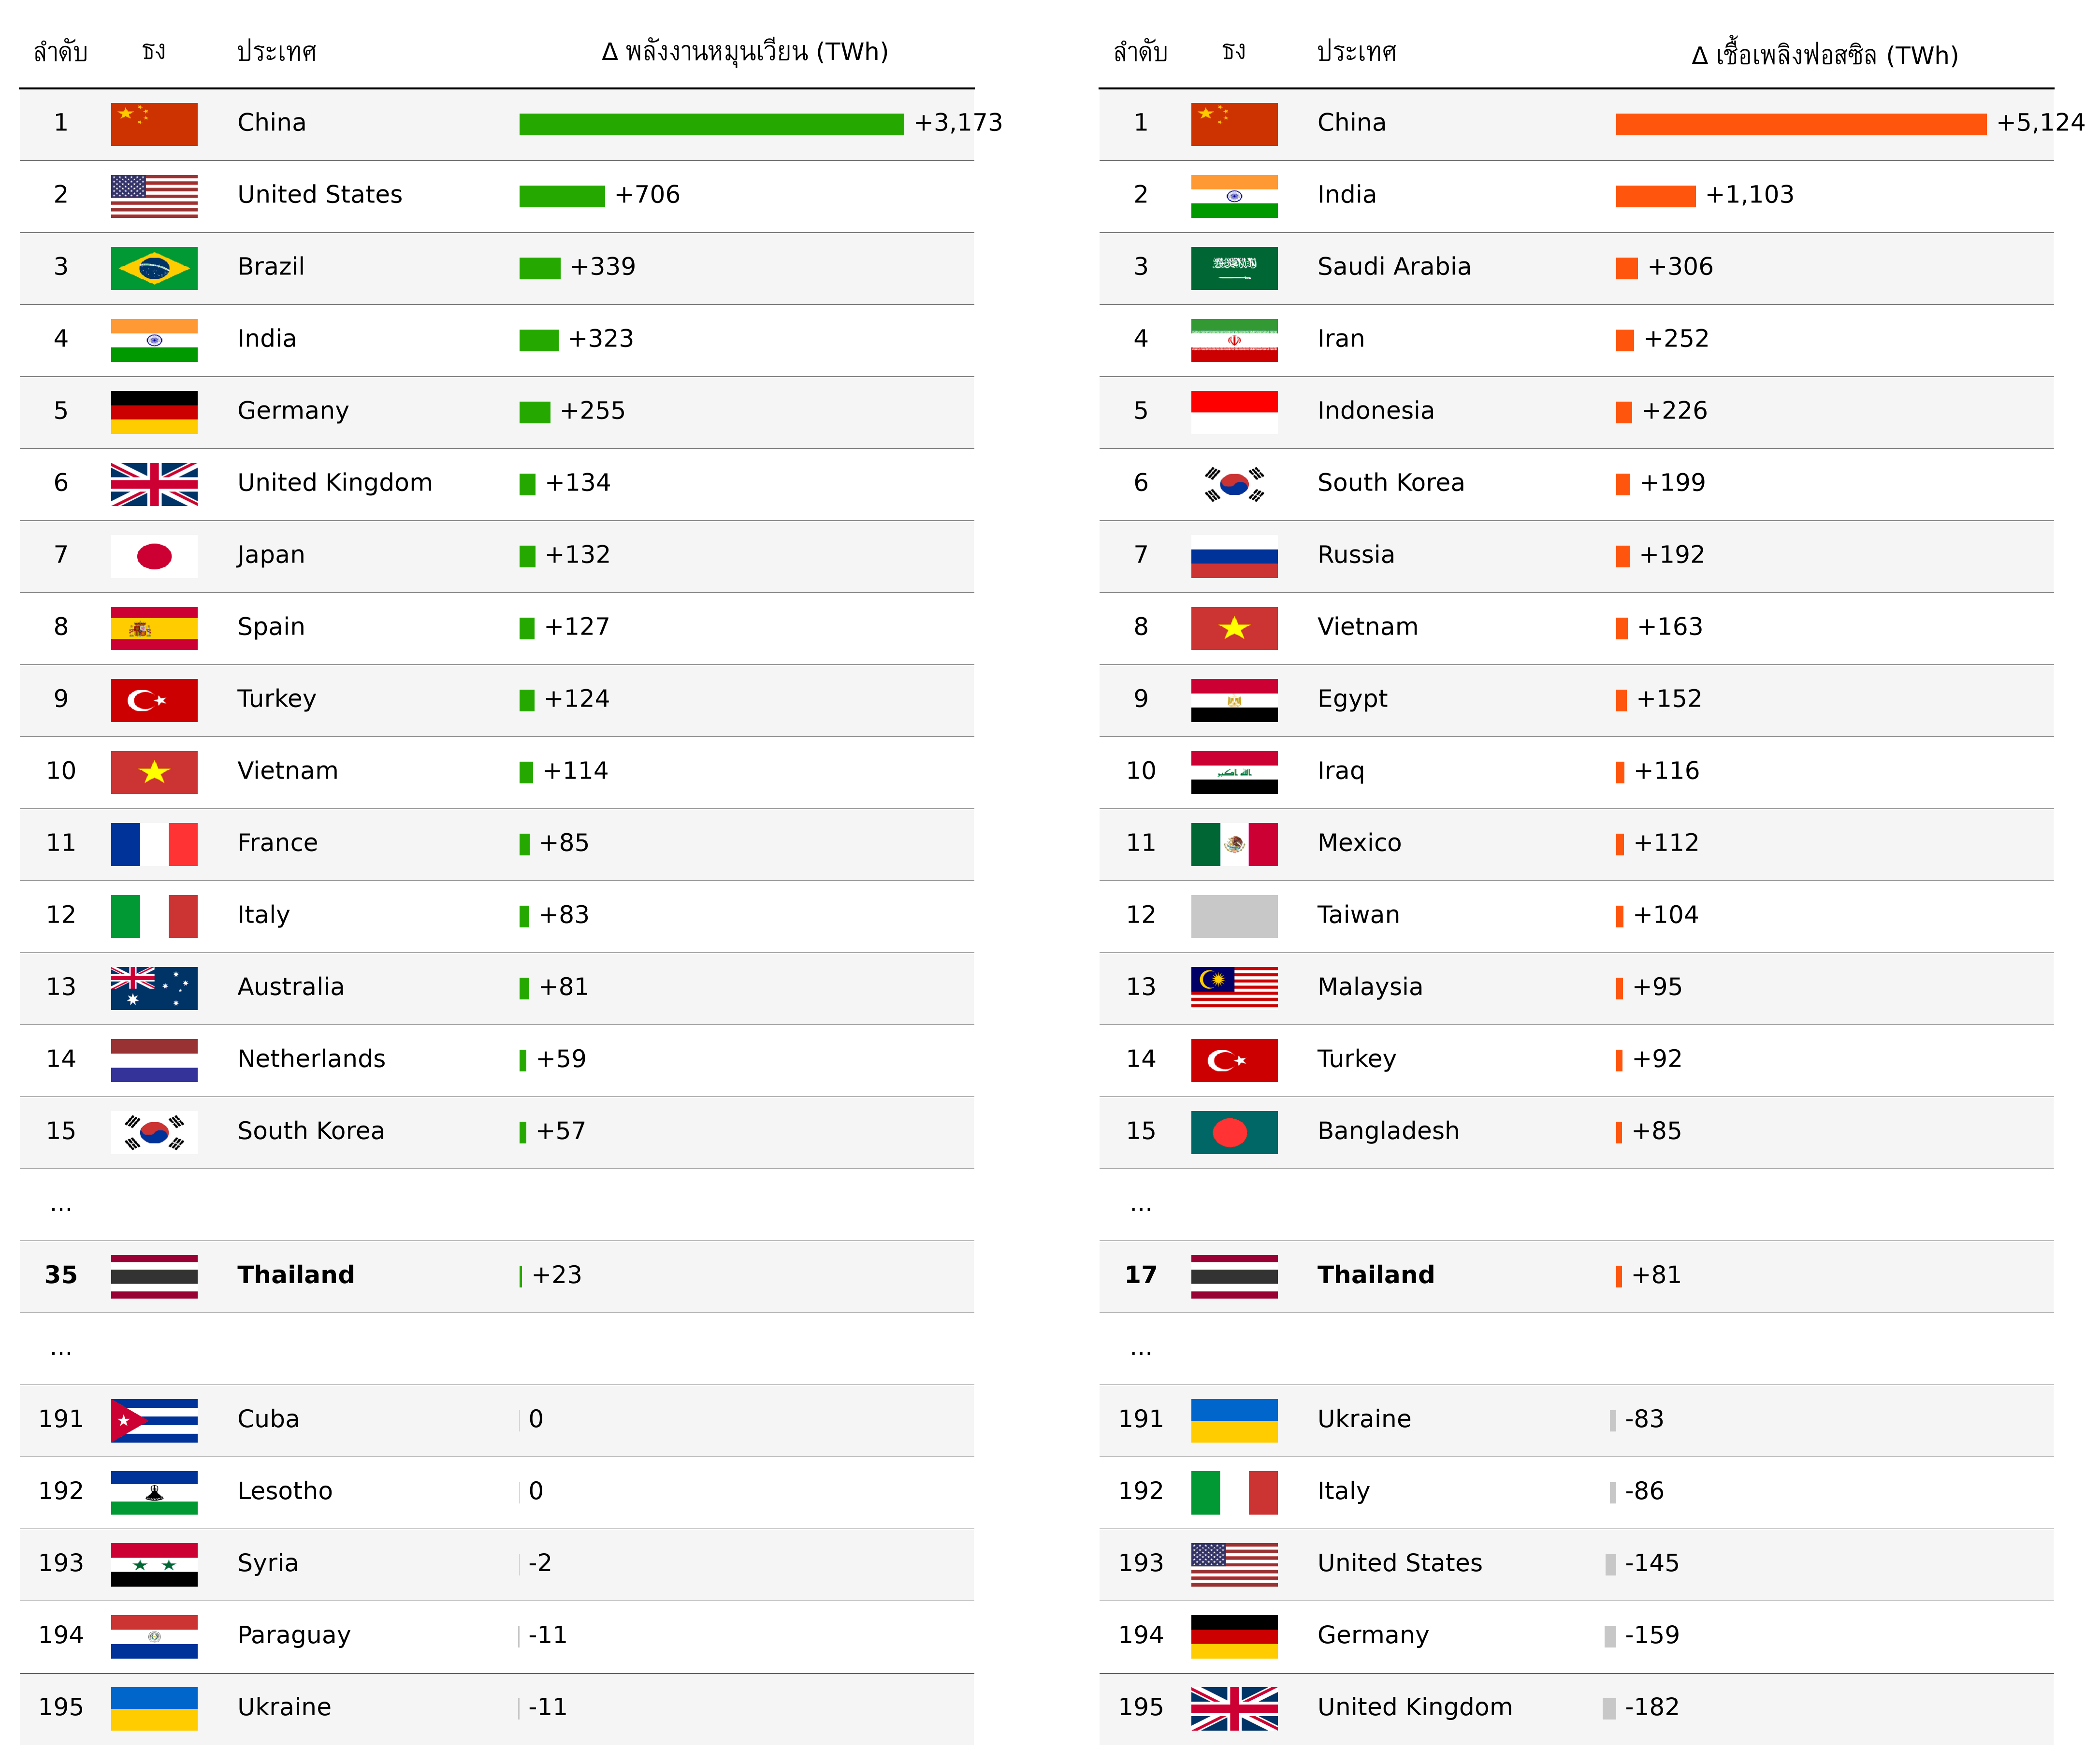

In [11]:
GARUDA_PATHS = [
    "/usr/share/fonts/truetype/tlwg/Garuda.ttf",
    "/usr/share/fonts/truetype/tlwg/Garuda-Bold.ttf",
]
for p in GARUDA_PATHS:
    if os.path.exists(p):
        fm.fontManager.addfont(p)

THAI_FONT = ["DejaVu Sans", "Garuda"]   # ใช้กับข้อความไทย (หัวข้อ/หัวตาราง) — DejaVu นำหน้าเพื่อกัน glyph เพี้ยนตอนผสมกับอังกฤษ/ตัวเลข
EN_FONT = ["DejaVu Sans"]               # ใช้กับชื่อประเทศ / ตัวเลขล้วน

plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.unicode_minus"] = False

TITLE_SIZE = 18
BODY_SIZE = 12

# --------------------------------------------------------------------------
# 1) โหลดข้อมูล + คำนวณ Delta RE / Delta Fossil (2000 -> 2024)
# --------------------------------------------------------------------------
# RE     = solar + wind + hydro + other_renewable   (ไม่รวม nuclear / biofuel เพราะไม่มีคอลัมน์แยก)
# Fossil = coal + gas + oil

# ใช้ข้อมูล df ที่โหลดไว้ในเซลล์ Import file
table_df = df.copy()
table_df["RE"] = (
    table_df["solar_electricity"]
    + table_df["wind_electricity"]
    + table_df["hydro_electricity"]
    + table_df["other_renewable_electricity"]
)
table_df["Fossil"] = table_df["coal_electricity"] + table_df["gas_electricity"] + table_df["oil_electricity"]

pivot = table_df[table_df["year"].isin([2000, 2024])].pivot(
    index="country", columns="year", values=["RE", "Fossil"]
)
pivot.columns = [f"{a}_{b}" for a, b in pivot.columns]
pivot["delta_re"] = pivot["RE_2024"] - pivot["RE_2000"]
pivot["delta_fossil"] = pivot["Fossil_2024"] - pivot["Fossil_2000"]
pivot = pivot.dropna(subset=["delta_re", "delta_fossil"]).reset_index()

# --------------------------------------------------------------------------
# 2) เตรียมธงประเทศ (flagpy) -> เซฟเป็นไฟล์ png ให้ plottable เรียกใช้
# --------------------------------------------------------------------------
FLAG_NAME_MAP = {
    "United States": "The United States",
    "United Kingdom": "The United Kingdom",
    "United Arab Emirates": "The United Arab Emirates",
    "Czechia": "The Czech Republic",
    "Netherlands": "The Netherlands",
    "Philippines": "The Philippines",
    "Democratic Republic of Congo": "The Democratic Republic Of The Congo",
    "Congo": "The Republic Of The Congo",
    "Bahamas": "The Bahamas",
    "Gambia": "The Gambia",
    "Maldives": "The Maldives",
    "Marshall Islands": "The Marshall Islands",
    "Micronesia (country)": "The Federated States Of Micronesia",
    "Central African Republic": "The Central African Republic",
    "Comoros": "The Comoros",
    "Dominican Republic": "The Dominican Republic",
    "Timor": "East Timor",
    "Cote d'Ivoire": "Ivory Coast",
    "Sao Tome and Principe": "São Tomé And Príncipe",
    "Saint Kitts and Nevis": "Saint Kitts And Nevis",
    "Saint Vincent and the Grenadines": "Saint Vincent And The Grenadines",
    "Antigua and Barbuda": "Antigua And Barbuda",
    "Bosnia and Herzegovina": "Bosnia And Herzegovina",
    "Trinidad and Tobago": "Trinidad And Tobago",
}

FLAG_DIR = "flags"
os.makedirs(FLAG_DIR, exist_ok=True)


def get_flag_path(country: str) -> str:
    """โหลดธงจาก flagpy แล้วเซฟเป็นไฟล์ .png คืน path (มี cache กันโหลดซ้ำ)"""
    safe_name = country.replace(" ", "_").replace("/", "-")
    out_path = os.path.join(FLAG_DIR, f"{safe_name}.png")
    if os.path.exists(out_path):
        return out_path

    lookup_name = FLAG_NAME_MAP.get(country, country)
    try:
        img = fp.get_flag_img(lookup_name)
        img.save(out_path)
    except Exception:
        placeholder = PILImage.new("RGB", (180, 90), color=(200, 200, 200))
        placeholder.save(out_path)
    return out_path


# --------------------------------------------------------------------------
# 3) ฟังก์ชันจัดอันดับ: Top 15 + Thailand (ถ้าไม่ติด Top15) + Bottom 5
# --------------------------------------------------------------------------
N_TOP = 15
N_BOTTOM = 5


def build_rank_table(pivot_df: pd.DataFrame, sort_col: str, n_top=N_TOP, n_bottom=N_BOTTOM):
    ranked = pivot_df.sort_values(sort_col, ascending=False).reset_index(drop=True)
    ranked["No."] = ranked.index + 1

    top = ranked.head(n_top)
    bottom = ranked.tail(n_bottom)
    th_row = ranked[ranked["country"] == "Thailand"]

    parts = [top]
    if not th_row.empty and th_row["No."].iloc[0] not in top["No."].values:
        parts.append(th_row)
    parts.append(bottom)

    out = pd.concat(parts).drop_duplicates(subset="No.").sort_values("No.")
    return out.reset_index(drop=True)


# --------------------------------------------------------------------------
# 3b) แทรกแถวคั่น "..." ตรงจุดที่อันดับกระโดดข้าม (เช่น 15 -> 35 -> 191)
#     ใส่ "..." เฉพาะคอลัมน์ลำดับ ส่วนคอลัมน์อื่นเว้นว่างไว้
# --------------------------------------------------------------------------
def insert_gap_rows(df: pd.DataFrame, rank_col: str) -> pd.DataFrame:
    df = df.reset_index(drop=True)
    out_rows = []
    prev_no = None
    gap_id = 0  # ใช้เป็นเลขติดลบ ไม่ซ้ำกัน เผื่อมีมากกว่า 1 จุดกระโดด
    for _, row in df.iterrows():
        cur_no = row[rank_col]
        if prev_no is not None and (cur_no - prev_no) > 1:
            gap_id -= 1
            gap_row = {}
            for col in df.columns:
                if col == rank_col:
                    gap_row[col] = gap_id  # sentinel ติดลบ -> format เป็น "..."
                elif pd.api.types.is_numeric_dtype(df[col]):
                    gap_row[col] = np.nan
                else:
                    gap_row[col] = ""  # ว่างไว้ (ไม่ใช่ None กัน str(None) โชว์คำว่า "None")
            out_rows.append(gap_row)
        out_rows.append(row.to_dict())
        prev_no = cur_no
    return pd.DataFrame(out_rows)


def format_rank(v) -> str:
    """แสดงเลขลำดับปกติ หรือ '...' สำหรับแถวคั่น (sentinel ติดลบ)"""
    if v is None or (isinstance(v, float) and pd.isna(v)):
        return "..."
    if v < 0:
        return "..."
    return f"{int(v)}"


# --------------------------------------------------------------------------
# 4) ตัวช่วยจัดรูปแบบตัวเลข -> เครื่องหมาย +/- และจำนวนเต็ม (ไม่มีทศนิยม)
# --------------------------------------------------------------------------
def format_plusminus(val) -> str:
    if val is None or (isinstance(val, float) and pd.isna(val)):
        return ""
    v = round(val)
    if v == 0:
        return "0"
    return f"{v:+,}"


# --------------------------------------------------------------------------
# 4a) วาดธงแบบปลอดภัย: ถ้าไม่มี path (แถวคั่น) ให้เว้นว่าง ไม่ error
# --------------------------------------------------------------------------
def safe_image(ax, path):
    ax.axis("off")
    if path is None or (isinstance(path, float) and pd.isna(path)) or path == "":
        return
    return image(ax, path)


# --------------------------------------------------------------------------
# 4b) Custom bar-in-cell: ตัวเลขอยู่ "นอกแท่งเสมอ" (กันตัวเลขทับแท่งสีเข้ม)
#     ค่าติดลบ -> แท่งสีเทาอ่อน (แยกให้เห็นชัดจากค่าบวก)
# --------------------------------------------------------------------------
NEG_BAR_COLOR = "#C7C7C7"


def bar_outside_label(ax, val, xlim, pos_color, neg_color=NEG_BAR_COLOR,
                       formatter=format_plusminus, textprops=None, bar_height=0.5):
    textprops = textprops or {}
    ax.set_xlim(xlim)
    ax.set_ylim(0, 1)
    ax.axis("off")

    if val is None or (isinstance(val, float) and pd.isna(val)):
        return  # แถวคั่น "..." -> ไม่วาดอะไรในคอลัมน์นี้

    color = pos_color if val >= 0 else neg_color
    ax.barh(0.5, val, height=bar_height, color=color, ec="None", zorder=0.05)

    text = formatter(val)
    pad = 0.02 * (xlim[1] - xlim[0])  # ระยะห่างคงที่จากปลายแท่ง / จากเส้นศูนย์
    # ข้อความอยู่ "ทางขวาเสมอ" ไม่ว่าค่าจะบวกหรือลบ (อ่านง่าย เรียงแนวเดียวกัน)
    x = val + pad if val >= 0 else pad
    ax.text(x, 0.5, text, va="center", ha="left", zorder=0.3, **textprops)


# --------------------------------------------------------------------------
# 5) Verdict logic (ตาม Four Quadrants)
# --------------------------------------------------------------------------
def get_verdict(row):
    re_up = row["delta_re"] > 0
    fossil_up = row["delta_fossil"] > 0
    if fossil_up and re_up:
        return "การเพิ่มเติม"
    elif (not fossil_up) and re_up:
        return "การเปลี่ยนผ่าน"
    elif fossil_up and (not re_up):
        return "การขยายตัวของเชื้อเพลิงฟอสซิล"
    else:
        return "การลดลงทั้งคู่"


# สีตัวอักษรตรงกับนิยามใน Table 1
VERDICT_COLORS = {'การเปลี่ยนผ่าน': '#426214', 'การเพิ่มเติม': '#C3773F', 'การลดลงทั้งคู่': '#5A5E60', 'การขยายตัวของเชื้อเพลิงฟอสซิล': '#D40123'}
NEUTRAL_VERDICT_COLOR = "#5A5E60"


def bold_country_row(tab: Table, table_df: pd.DataFrame, country="Thailand",
                      country_col="country", col_names=None):
    """ทำให้แถวของ 'country' (เช่น Thailand) เป็นตัวหนาทุกคอลัมน์ข้อความที่กำหนด"""
    row_idx = table_df.index[table_df[country_col] == country]
    if len(row_idx) == 0:
        return
    row_idx = row_idx[0]
    if col_names is None:
        col_names = table_df.columns
    for col in col_names:
        try:
            column = tab.columns[col]
        except KeyError:
            continue
        cell = column.cells[row_idx]
        if hasattr(cell, "text"):
            cell.text.set_fontweight("bold")


def set_column_font(tab: Table, col_name: str, font_list):
    """ตั้งฟอนต์ของ 'เนื้อหา' cells ในคอลัมน์ (ไม่รวมหัวตาราง) เป็น font_list ที่กำหนด"""
    try:
        column = tab.columns[col_name]
    except KeyError:
        return
    for cell in column.cells:
        if hasattr(cell, "text"):
            cell.text.set_fontfamily(font_list)


def save_fig(fig, path, dpi=300):
    fig.savefig(path, dpi=dpi, bbox_inches="tight", facecolor="white")
    print("Saved:", path)


def draw_split_title(ax, prefix: str, thai_rest: str, fontsize=TITLE_SIZE, y=1.04):
    """Use the same Garuda font, size and baseline for the complete title."""
    return ax.text(
        0.0, y, prefix + thai_rest,
        transform=ax.transAxes, ha="left", va="baseline",
        fontsize=fontsize, fontweight="bold", fontfamily="Garuda",
    )




# ==========================================================================
# TABLE 3: ตารางอันดับประเทศตามผลต่างพลังงานหมุนเวียน (Delta RE) — ไฮไลท์ไทย
# ==========================================================================
t3 = build_rank_table(pivot, "delta_re")
t3["flag_path"] = t3["country"].apply(get_flag_path)
t3_display = t3[["No.", "flag_path", "country", "delta_re"]].copy()
t3_display.columns = ["ลำดับ", "ธง", "ประเทศ", "Δ พลังงานหมุนเวียน (TWh)"]

re_max = t3_display["Δ พลังงานหมุนเวียน (TWh)"].max()
re_min = t3_display["Δ พลังงานหมุนเวียน (TWh)"].min()

t3_display = insert_gap_rows(t3_display, rank_col="ลำดับ")

col_defs_3 = [
    ColumnDefinition(name="ลำดับ", width=0.4, formatter=format_rank, textprops={"ha": "center"}),
    ColumnDefinition(name="ธง", width=0.5, plot_fn=safe_image, textprops={"ha": "center"}),
    ColumnDefinition(name="ประเทศ", width=1.5, textprops={"ha": "left"}),
    ColumnDefinition(
        name="Δ พลังงานหมุนเวียน (TWh)",
        width=2.2,
        plot_fn=partial(
            bar_outside_label,
            xlim=(min(0, re_min * 1.4), re_max * 1.18),
            pos_color="#25A800",
            formatter=format_plusminus,
            textprops={"fontsize": BODY_SIZE, "fontfamily": EN_FONT},
            bar_height=0.5,
        ),
    ),
]

t4 = build_rank_table(pivot, "delta_fossil")
t4["flag_path"] = t4["country"].apply(get_flag_path)
t4_display = t4[["No.", "flag_path", "country", "delta_fossil"]].copy()
t4_display.columns = ["ลำดับ", "ธง", "ประเทศ", "Δ เชื้อเพลิงฟอสซิล (TWh)"]

fossil_max = t4_display["Δ เชื้อเพลิงฟอสซิล (TWh)"].max()
fossil_min = t4_display["Δ เชื้อเพลิงฟอสซิล (TWh)"].min()

t4_display = insert_gap_rows(t4_display, rank_col="ลำดับ")

col_defs_4 = [
    ColumnDefinition(name="ลำดับ", width=0.4, formatter=format_rank, textprops={"ha": "center"}),
    ColumnDefinition(name="ธง", width=0.5, plot_fn=safe_image, textprops={"ha": "center"}),
    ColumnDefinition(name="ประเทศ", width=1.5, textprops={"ha": "left"}),
    ColumnDefinition(
        name="Δ เชื้อเพลิงฟอสซิล (TWh)",
        width=2.2,
        plot_fn=partial(
            bar_outside_label,
            xlim=(min(0, fossil_min * 1.4), fossil_max * 1.18),
            pos_color="#FF550D",
            formatter=format_plusminus,
            textprops={"fontsize": BODY_SIZE, "fontfamily": EN_FONT},
            bar_height=0.5,
        ),
    ),
]


# สร้างรูปเดียว: ตารางพลังงานหมุนเวียนซ้าย / ฟอสซิลขวา
max_rows = max(len(t3_display), len(t4_display))
fig34, (ax3, ax4) = plt.subplots(1, 2, figsize=(15, max_rows * 0.5 + 1.5), facecolor='white', dpi=300)
fig34.subplots_adjust(left=0.03, right=0.97, top=0.95, bottom=0.03, wspace=0.12)
tab3 = Table(
    t3_display,
    index_col="ลำดับ",
    column_definitions=col_defs_3,
    row_dividers=True,
    col_label_divider=True,
    footer_divider=False,
    textprops={"fontsize": BODY_SIZE, "ha": "center", "fontfamily": THAI_FONT},
    even_row_color="#f5f5f5",
    ax=ax3,
)
set_column_font(tab3, "ประเทศ", EN_FONT)
bold_country_row(
    tab3,
    t3_display.reset_index(drop=True),
    country="Thailand",
    country_col="ประเทศ",
    col_names=["ประเทศ", "Δ พลังงานหมุนเวียน (TWh)", "ลำดับ"],
)



# ==========================================================================
# TABLE 4: ตารางอันดับประเทศตามผลต่างเชื้อเพลิงฟอสซิล (Delta Fossil) — ไฮไลท์ไทย
# ==========================================================================

tab4 = Table(
    t4_display,
    index_col="ลำดับ",
    column_definitions=col_defs_4,
    row_dividers=True,
    col_label_divider=True,
    footer_divider=False,
    textprops={"fontsize": BODY_SIZE, "ha": "center", "fontfamily": THAI_FONT},
    even_row_color="#f5f5f5",
    ax=ax4,
)
set_column_font(tab4, "ประเทศ", EN_FONT)
bold_country_row(
    tab4,
    t4_display.reset_index(drop=True),
    country="Thailand",
    country_col="ประเทศ",
    col_names=["ประเทศ", "Δ เชื้อเพลิงฟอสซิล (TWh)", "ลำดับ"],
)
# ใช้ขอบเขตแกน Y เดียวกันเพื่อให้แถวของทั้งสองตารางสูงเท่ากัน
shared_limits = ax3.get_ylim() if len(t3_display) >= len(t4_display) else ax4.get_ylim()
ax3.set_ylim(shared_limits)
ax4.set_ylim(shared_limits)
save_fig(fig34, "table3_4_side_by_side.png", dpi=300)

#Figure 7

ฟอนต์ไทย: Garuda -> C:\nida\work\dads 5001\fonts\Garuda.otf
จำนวนประเทศ: 195 {'Addition': 133, 'Transition': 53, 'Fossil Expansion': 8, 'Decline': 1}
Thailand: อันดับ 18 ในกลุ่ม Addition
บันทึก table3-5_butterfly.png (3084, 1530)


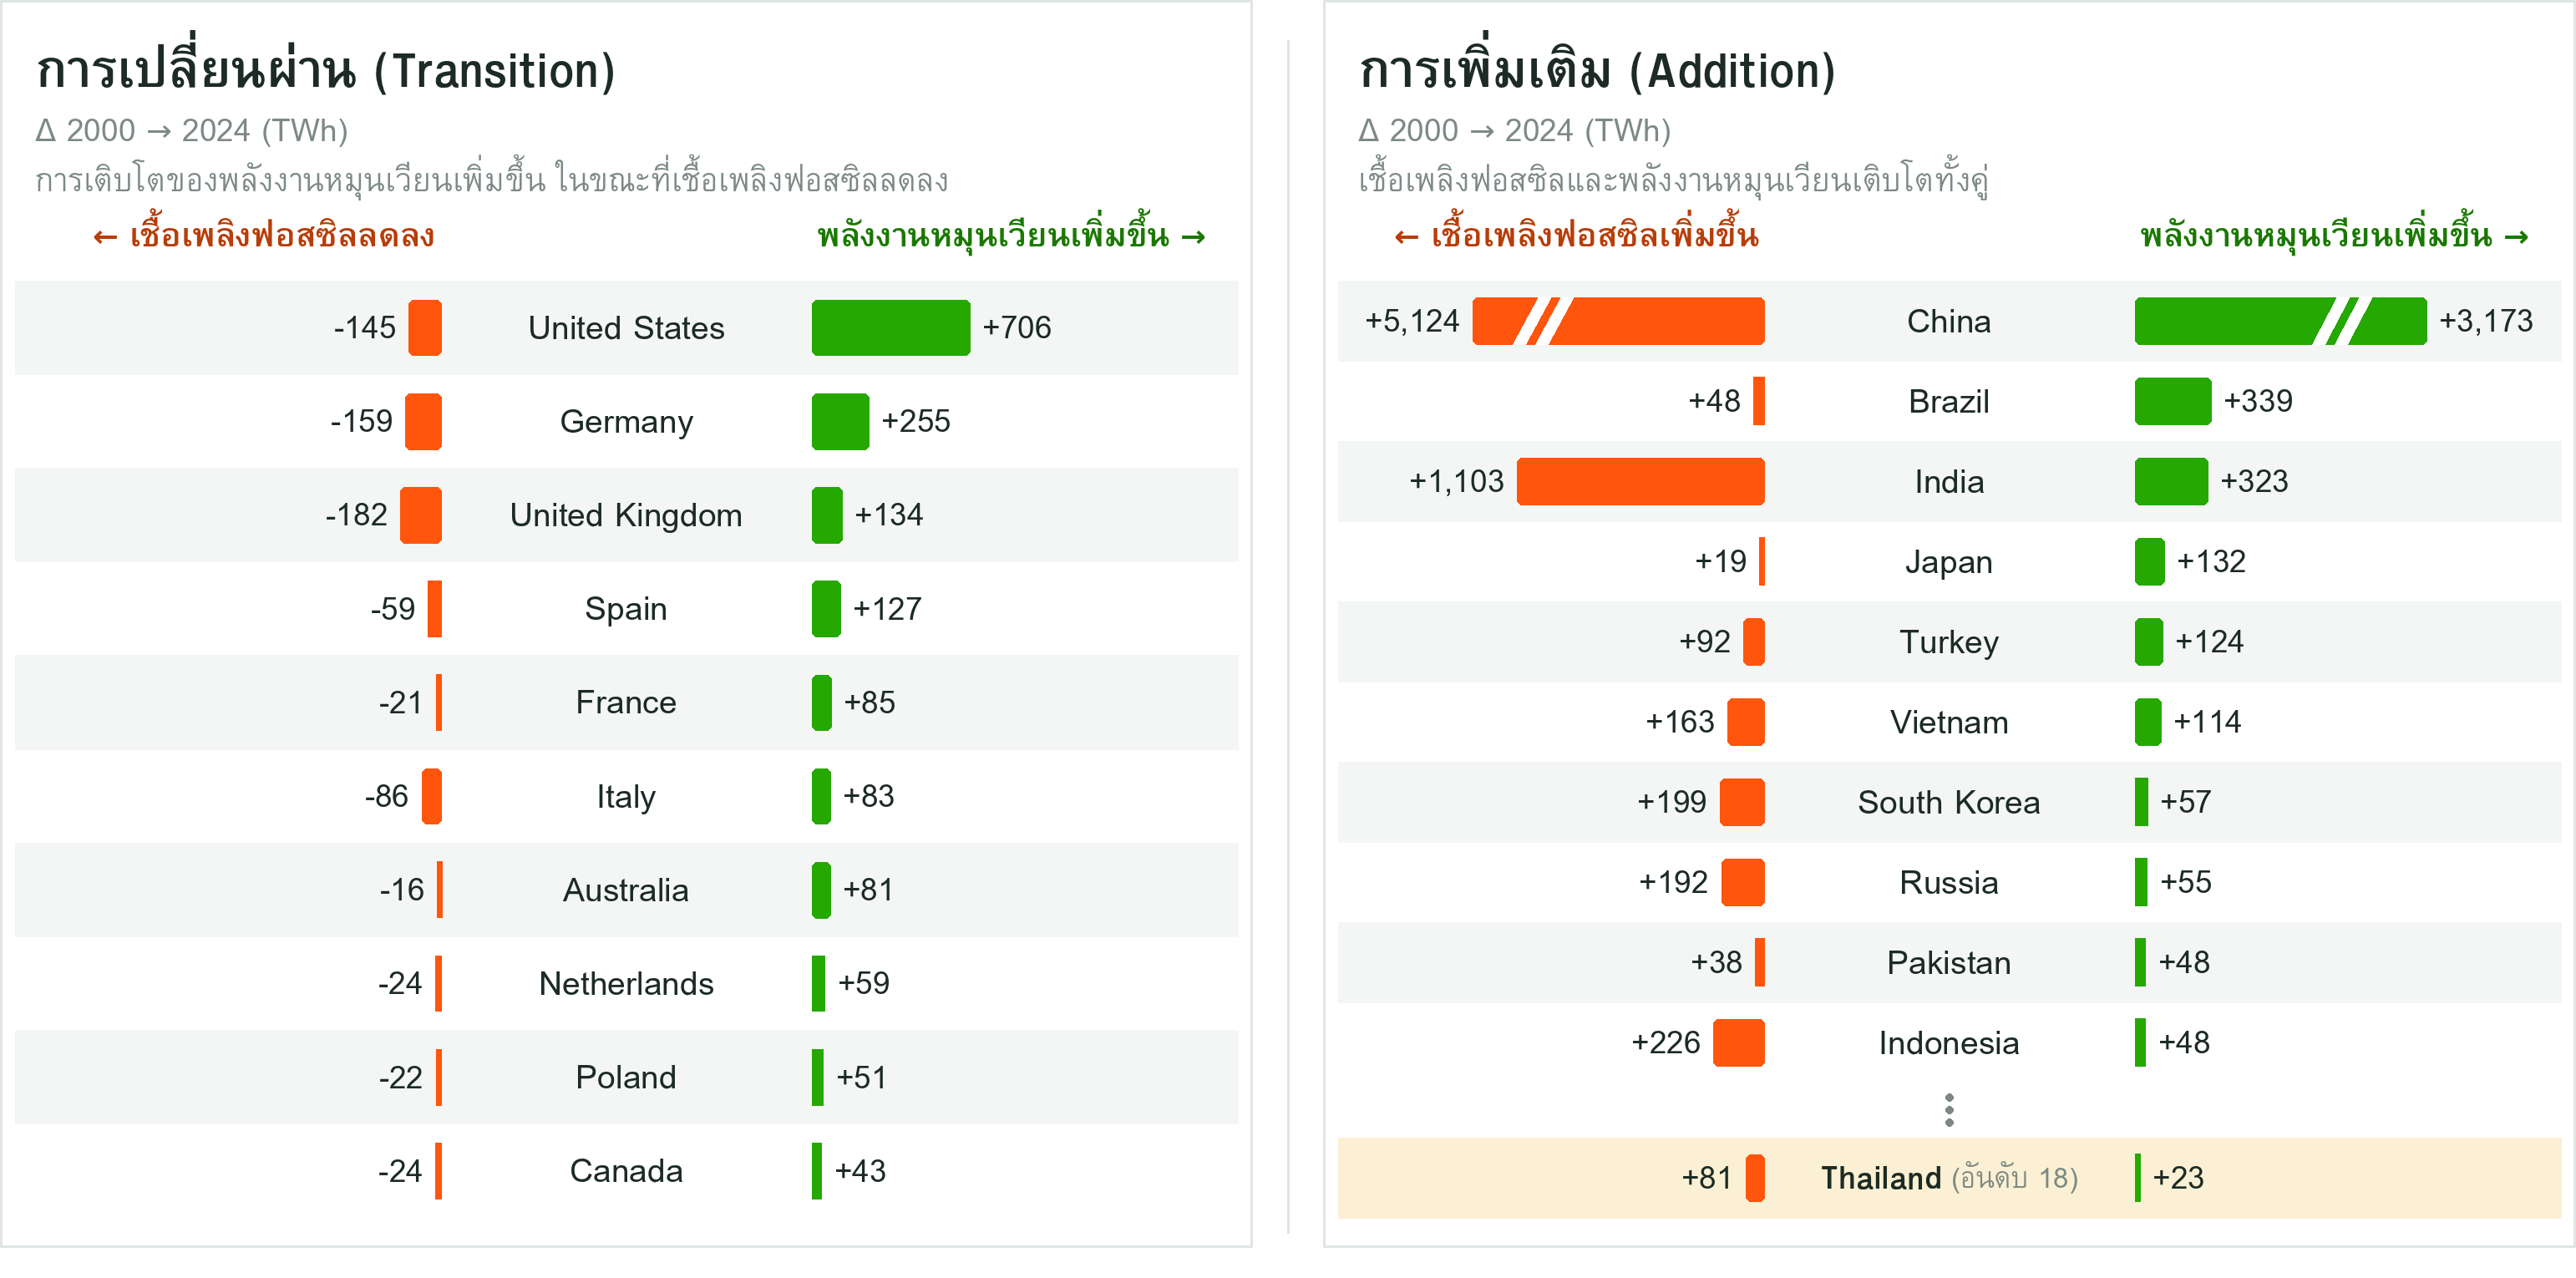

In [12]:
from functools import lru_cache

import matplotlib
import uharfbuzz as hb
import freetype
from PIL import ImageDraw

# ── 1. ตั้งค่า ─────────────────────────────────────────────────
Y0, Y1    = 2000, 2024
TOP_N     = 10             # จำนวนประเทศต่อฝั่ง
HIGHLIGHT = "Thailand"     # แสดงต่อท้ายเฉพาะกราฟของกลุ่มที่ไทยอยู่
CAP_TWH   = 1300           # ตัดแท่งที่ยาวเกินค่านี้ ใช้กับทั้งสองกราฟ (None = ไม่ตัด)
SCALE     = 3              # ความละเอียด
OUT_PNG   = "table3-5_butterfly.png"
Y_LABEL = f"การเปลี่ยนแปลง (% ของไฟฟ้าที่ผลิตปี {Y0})"


C_FOS, C_RE = "#FF550D", "#25A800"          # ชุดเดียวกับ Figure 2-4 / Figure 10
QUAD_TH = {"Transition": "การเปลี่ยนผ่าน", "Addition": "การเพิ่มเติม"}
# คำอธิบายตาม Table 2
QUAD_DESCRIPTION = {'Transition': 'การเติบโตของพลังงานหมุนเวียนเพิ่มขึ้น ในขณะที่เชื้อเพลิงฟอสซิลลดลง', 'Addition': 'เชื้อเพลิงฟอสซิลและพลังงานหมุนเวียนเติบโตทั้งคู่'}
COL = dict(ink="#1c2b24", muted="#7d8a83", band="#f3f6f4", hl="#fbf0d3",
           white="#ffffff", line="#dfe5e1")

# ฟอนต์: ใช้ตัวเดียวกับรูปอื่น (ตัวแปร GARUDA จากเซลล์ตั้งค่าฟอนต์) ให้ matplotlib หาไฟล์ให้
_thai_family = globals().get("GARUDA") or globals().get("thai_font_name") or "Tahoma"
_dv = Path(matplotlib.get_data_path()) / "fonts" / "ttf"
FONTS = {
    "regular":  fm.findfont(fm.FontProperties(family=_thai_family), fallback_to_default=False),
    "bold":     fm.findfont(fm.FontProperties(family=_thai_family, weight="bold"), fallback_to_default=False),
    "sym":      str(_dv / "DejaVuSans.ttf"),        # Garuda ไม่มี Δ → ← จึงใช้ DejaVu เฉพาะตัวเหล่านี้
    "sym_bold": str(_dv / "DejaVuSans-Bold.ttf"),
}
SYMBOLS = set("Δ→←")
print("ฟอนต์ไทย:", _thai_family, "->", FONTS["regular"])


# ── 2. คำนวณ Δ และจัดกลุ่ม (นิยามเดียวกับ Figure 5-6) ─────────────
bf = df[df["year"].isin([Y0, Y1])].copy()
bf["RE"]     = bf[["solar_electricity", "wind_electricity", "hydro_electricity",
                   "other_renewable_electricity"]].sum(axis=1, min_count=4)
bf["Fossil"] = bf[["coal_electricity", "gas_electricity", "oil_electricity"]].sum(axis=1, min_count=3)
pv = bf.pivot(index="country", columns="year", values=["RE", "Fossil"])
bf = pd.DataFrame({"d_ren": pv["RE"][Y1] - pv["RE"][Y0],
                   "d_fos": pv["Fossil"][Y1] - pv["Fossil"][Y0]}).dropna()

bf["group"] = np.select(
    [(bf["d_fos"] >= 0) & (bf["d_ren"] >= 0), (bf["d_fos"] < 0) & (bf["d_ren"] >= 0),
     (bf["d_fos"] >= 0) & (bf["d_ren"] < 0)],
    ["Addition", "Transition", "Fossil Expansion"], default="Decline")
bf = bf.sort_values("d_ren", ascending=False)
bf["rank_in_group"] = bf.groupby("group").cumcount() + 1     # อันดับภายในกลุ่ม เรียงตาม ΔRE

n_group  = bf["group"].value_counts().to_dict()
hl_group = bf.loc[HIGHLIGHT, "group"]
hl_rank  = int(bf.loc[HIGHLIGHT, "rank_in_group"])
print("จำนวนประเทศ:", len(bf), n_group)
print(f"{HIGHLIGHT}: อันดับ {hl_rank} ในกลุ่ม {hl_group}")


# ── 3. ตัวจัดวางข้อความไทย (HarfBuzz + FreeType) ─────────────────
class TFont:
    """ฟอนต์หนึ่งขนาด: key = ชื่อใน FONTS, size = ขนาด (pt ก่อนคูณ SCALE)"""
    def __init__(self, key, size):
        self.key, self.px = key, int(size * SCALE)

@lru_cache(None)
def _hb_font(path):
    return hb.Font(hb.Face(hb.Blob.from_file_path(path)))

@lru_cache(None)
def _ft_face(path):
    return freetype.Face(path)

def _shape(s, path, px):
    """คืน [(glyph_id, x, dx, dy)] หน่วย px และความกว้างรวม"""
    f = _hb_font(path)
    k = px / f.face.upem
    buf = hb.Buffer()
    buf.add_str(s)
    # บังคับสคริปต์ไทยทั้งบรรทัด: ถ้าให้เดาเอง ข้อความที่ขึ้นต้นด้วยอังกฤษ (เช่น "TWh (ตัวเลข...")
    # จะถูกจัดเป็นละติน แล้ววรรณยุกต์ไทยจะวางผิดที่
    buf.direction, buf.script, buf.language = "ltr", "Thai", "th"
    hb.shape(f, buf, {"kern": True, "liga": True})
    out, x = [], 0.0
    for info, pos in zip(buf.glyph_infos, buf.glyph_positions):
        out.append((info.codepoint, x, pos.x_offset * k, pos.y_offset * k))
        x += pos.x_advance * k
    return out, x

def _runs(s, font):
    """แบ่งข้อความเป็นช่วง: สัญลักษณ์ใช้ DejaVu ที่เหลือใช้ฟอนต์ไทย"""
    sym = "sym_bold" if font.key == "bold" else "sym"
    out = []
    for ch in s:
        key = sym if ch in SYMBOLS else font.key
        if out and out[-1][1] == key:
            out[-1][0] += ch
        else:
            out.append([ch, key])
    return [(t, FONTS[k]) for t, k in out]

def text_w(s, font):
    """ความกว้างข้อความ (หน่วยก่อนคูณ SCALE)"""
    return sum(_shape(t, p, font.px)[1] for t, p in _runs(s, font)) / SCALE

def draw_text(img, x, y, s, font, fill, anchor="lm"):
    """วาดข้อความที่ (x, y) หน่วยก่อนคูณ SCALE | anchor: l/m/r + m (กึ่งกลางแนวตั้ง)"""
    color = PILImage.new("RGB", (1, 1), fill).getpixel((0, 0))
    runs = [(p, *_shape(t, p, font.px)) for t, p in _runs(s, font)]
    total = sum(w for _, _, w in runs)
    pen = x * SCALE - {"l": 0, "m": total / 2, "r": total}[anchor[0]]
    face0 = _ft_face(FONTS[font.key]); face0.set_pixel_sizes(0, font.px)
    asc, desc = face0.size.ascender / 64, face0.size.descender / 64
    base = y * SCALE + (asc + desc) / 2                           # เส้น baseline จาก anchor กึ่งกลาง
    for path, glyphs, w in runs:
        face = _ft_face(path); face.set_pixel_sizes(0, font.px)
        for gid, gx, dx, dy in glyphs:
            face.load_glyph(gid, freetype.FT_LOAD_RENDER | freetype.FT_LOAD_TARGET_NORMAL)
            g, bm = face.glyph, face.glyph.bitmap
            if bm.width == 0 or bm.rows == 0:
                continue
            a = np.array(bm.buffer, dtype=np.uint8).reshape(bm.rows, bm.pitch)[:, :bm.width]
            mask = PILImage.fromarray(a, "L")
            px_ = int(round(pen + gx + dx + g.bitmap_left))
            py_ = int(round(base - dy - g.bitmap_top))
            img.paste(PILImage.new("RGB", mask.size, color), (px_, py_), mask)
        pen += w

def fnt(key, size):
    return TFont(key, size)

def fmt(v):
    sign = "+" if v > 0 else "\u2212" if v < 0 else ""
    return f"{sign}{abs(v):,.0f}"

def darker(hex_color, k=0.72):
    r, g, b = (int(hex_color[i:i + 2], 16) for i in (1, 3, 5))
    return "#{:02x}{:02x}{:02x}".format(int(r * k), int(g * k), int(b * k))

def wrap(text, font, max_w):
    lines, cur = [], ""
    for word in text.split(" "):
        trial = (cur + " " + word).strip()
        if text_w(trial, font) <= max_w or not cur:
            cur = trial
        else:
            lines.append(cur); cur = word
    return lines + [cur]


# ── 4. วาดกราฟหนึ่งฝั่ง ────────────────────────────────────────
def draw_panel(kind, rows, vmax, highlight=None, panel_w=500, name_w=140, margin=14,
               row_h=32, bar_h=19, gap_h=22, body_height=None):
    """กราฟผีเสื้อหนึ่งฝั่ง | ซ้าย = ΔFossil, ขวา = ΔRE (สเกลเดียวกันทั้งสองฝั่ง)"""
    is_t    = kind == "Transition"
    half_w  = (panel_w - 2 * margin - name_w) / 2
    unit    = 0.70 * half_w / vmax

    entries = [(n, r.d_ren, r.d_fos, False) for n, r in rows.iterrows()]
    # ไทยแสดงเฉพาะกราฟของกลุ่มตัวเอง (ถ้ายังไม่ติด Top N)
    if highlight and highlight not in rows.index and bf.loc[highlight, "group"] == kind:
        r = bf.loc[highlight]
        entries += [None, (highlight, r.d_ren, r.d_fos, True)]

    if body_height is not None:
        row_count = sum(entry is not None for entry in entries)
        gap_count = len(entries) - row_count
        fitted_row_h = (body_height - gap_count * gap_h) / row_count
        bar_h *= fitted_row_h / row_h
        row_h = fitted_row_h

    description_lines = wrap(QUAD_DESCRIPTION[kind], fnt("regular", 12.5), panel_w - 2 * margin)
    y_rows0 = 94 + 18 * len(description_lines)
    H = y_rows0 + sum(gap_h if e is None else row_h for e in entries) + 12
    img = PILImage.new("RGB", (int(panel_w * SCALE), int(H * SCALE)), COL["white"])
    dr = ImageDraw.Draw(img)
    S = lambda v: v * SCALE

    def text(x, y, s, font, fill, anchor="lm"):
        draw_text(img, x, y, s, font, fill, anchor)

    # หัวเรื่อง
    text(margin, 28, f"{QUAD_TH[kind]} ({kind})", fnt("bold", 19), COL["ink"])
    text(margin, 52, f"Δ {Y0} → {Y1} (TWh)", fnt("regular", 12.5), COL["muted"])
    for line_index, line in enumerate(description_lines):
        text(margin, 72 + 18 * line_index, line, fnt("regular", 12.5), COL["muted"])
    left_end, right_start = margin + half_w, margin + half_w + name_w
    text(left_end - 6, y_rows0 - 18, "← " + ("เชื้อเพลิงฟอสซิลลดลง" if is_t else "เชื้อเพลิงฟอสซิลเพิ่มขึ้น"),
         fnt("bold", 12.5), darker(C_FOS), "rm")
    text(right_start + 6, y_rows0 - 18, "พลังงานหมุนเวียนเพิ่มขึ้น →", fnt("bold", 12.5), darker(C_RE), "lm")

    def bar(x0, x1, y_mid, color):
        """วาดแท่งสีทึบทั้งค่าบวกและค่าลบ"""
        x0, x1 = S(x0), max(S(x1), S(x0) + 2 * SCALE)
        y0, y1 = S(y_mid - bar_h / 2), S(y_mid + bar_h / 2)
        rad = 0 if (x1 - x0) < 6 * SCALE else min(2 * SCALE, (x1 - x0) / 2)
        dr.rounded_rectangle([x0, y0, x1, y1], radius=rad, fill=color)

    def brk(near_x, y_mid, direction):          # รอยขาดบนแท่งที่ถูกตัด
        top, bot, skew, w = y_mid - bar_h / 2, y_mid + bar_h / 2, bar_h * 0.53, 5
        for off in (0, 9):
            x = near_x - direction * (off + w)
            pts = [(x, top), (x + w, top), (x + w - skew, bot), (x - skew, bot)]
            dr.polygon([(S(px), S(py)) for px, py in pts], fill=COL["white"])

    y, zebra = y_rows0, 0
    for e in entries:
        if e is None:                           # แถวคั่น ⋮
            for k in (-1, 0, 1):
                cx, cy = left_end + name_w / 2, y + gap_h / 2 + k * 5
                dr.ellipse([S(cx - 1.4), S(cy - 1.4), S(cx + 1.4), S(cy + 1.4)], fill=COL["muted"])
            y += gap_h
            continue
        name, ren, fos, is_hl = e
        y_mid = y + row_h / 2
        if is_hl or zebra % 2 == 0:
            dr.rectangle([S(margin - 8), S(y), S(panel_w - margin + 8), S(y + row_h)],
                         fill=COL["hl"] if is_hl else COL["band"])
        zebra += 1

        # ชื่อประเทศกึ่งกลางช่อง (ไทย: ตัวหนา + อันดับในกลุ่มในวงเล็บ)
        cx = left_end + name_w / 2
        if is_hl:
            f1, f2, s2 = fnt("bold", 13), fnt("regular", 11), f" (อันดับ {hl_rank})"
            w1, w2 = text_w(name, f1), text_w(s2, f2)
            text(cx - (w1 + w2) / 2, y_mid, name, f1, COL["ink"])
            text(cx - (w1 + w2) / 2 + w1, y_mid, s2, f2, COL["muted"])
        else:
            text(cx, y_mid, name, fnt("regular", 13), COL["ink"], "mm")

        # ฝั่งซ้าย: ΔFossil
        fos_len = min(abs(fos), vmax) * unit
        x_end = left_end - 4
        bar(x_end - fos_len, x_end, y_mid, C_FOS)
        if abs(fos) > vmax:
            brk(x_end - fos_len + 0.14 * fos_len + 5, y_mid, -1)
        text(x_end - fos_len - 5, y_mid, fmt(fos), fnt("regular", 12.5), COL["ink"], "rm")

        # ฝั่งขวา: ΔRE
        ren_len = min(abs(ren), vmax) * unit
        x_start = right_start + 4
        bar(x_start, x_start + ren_len, y_mid, C_RE)
        if abs(ren) > vmax:
            brk(x_start + ren_len - 0.14 * ren_len - 5, y_mid, 1)
        text(x_start + ren_len + 5, y_mid, fmt(ren), fnt("regular", 12.5), COL["ink"], "lm")
        y += row_h
    return img


# ── 5. วาดสองฝั่งแล้วรวมเป็นภาพเดียว ─────────────────────────────
T = bf[bf["group"] == "Transition"].head(TOP_N)
A = bf[bf["group"] == "Addition"].head(TOP_N)

# สเกลเดียวกันทั้งสองกราฟ -> เทียบความยาวแท่งข้ามกราฟได้ (ตัดที่ CAP_TWH ถ้ามีค่าเกิน)
_shown = pd.concat([T, A, bf.loc[[HIGHLIGHT]]])
VMAX = max(_shown["d_ren"].abs().max(), _shown["d_fos"].abs().max())
if CAP_TWH:
    VMAX = min(VMAX, CAP_TWH)

# Allocate the same data height to both panels, including Thailand's extra row.
def panel_body_height(kind, rows):
    has_extra = (HIGHLIGHT not in rows.index and bf.loc[HIGHLIGHT, "group"] == kind)
    return len(rows) * 32 + (22 + 32 if has_extra else 0)

shared_body_height = max(panel_body_height("Transition", T), panel_body_height("Addition", A))
panel_t = draw_panel("Transition", T, VMAX, highlight=HIGHLIGHT, body_height=shared_body_height)
panel_a = draw_panel("Addition", A, VMAX, highlight=HIGHLIGHT, body_height=shared_body_height)

# Match panel dimensions without stretching text or changing bar scales.
shared_panel_size = (max(panel_t.width, panel_a.width),
                     max(panel_t.height, panel_a.height))
def frame_panel(panel):
    framed = PILImage.new("RGB", shared_panel_size, COL["white"])
    framed.paste(panel, (0, 0))
    ImageDraw.Draw(framed).rectangle(
        (0, 0, framed.width - 1, framed.height - 1),
        outline=COL["line"], width=SCALE,
    )
    return framed

panel_t = frame_panel(panel_t)
panel_a = frame_panel(panel_a)


GAP = 28
total_w = (panel_t.width + panel_a.width) / SCALE + GAP

top_h = max(panel_t.height, panel_a.height) / SCALE
H = top_h + 12
canvas = PILImage.new("RGB", (int(total_w * SCALE), int(H * SCALE)), COL["white"])
canvas.paste(panel_t, (0, 0))
canvas.paste(panel_a, (int((panel_t.width / SCALE + GAP) * SCALE), 0))

cd = ImageDraw.Draw(canvas)
mid_x = (panel_t.width / SCALE + GAP / 2) * SCALE
cd.line([(mid_x, 16 * SCALE), (mid_x, (top_h - 6) * SCALE)], fill=COL["line"], width=SCALE)

canvas.save(OUT_PNG, dpi=(300, 300))
print("บันทึก", OUT_PNG, canvas.size)
display(Image(filename=OUT_PNG, width=1000))

#Figure 9

ren     Transition n= 53 | ช่วงกลาง +19.1% ถึง +66.7% | มัธยฐาน +37.5%
ren     Addition   n=133 | ช่วงกลาง +11.1% ถึง +83.0% | มัธยฐาน +26.9%
demand  Transition n= 53 | ช่วงกลาง -4.1% ถึง +38.9% | มัธยฐาน +14.1%
demand  Addition   n=133 | ช่วงกลาง +73.9% ถึง +261.5% | มัธยฐาน +150.3%
กลุ่มอื่นที่ไม่นำมาเทียบ: 8 ประเทศ
บันทึกแล้ว: figure10.png (1920, 1008)
<IPython.core.display.Image object>


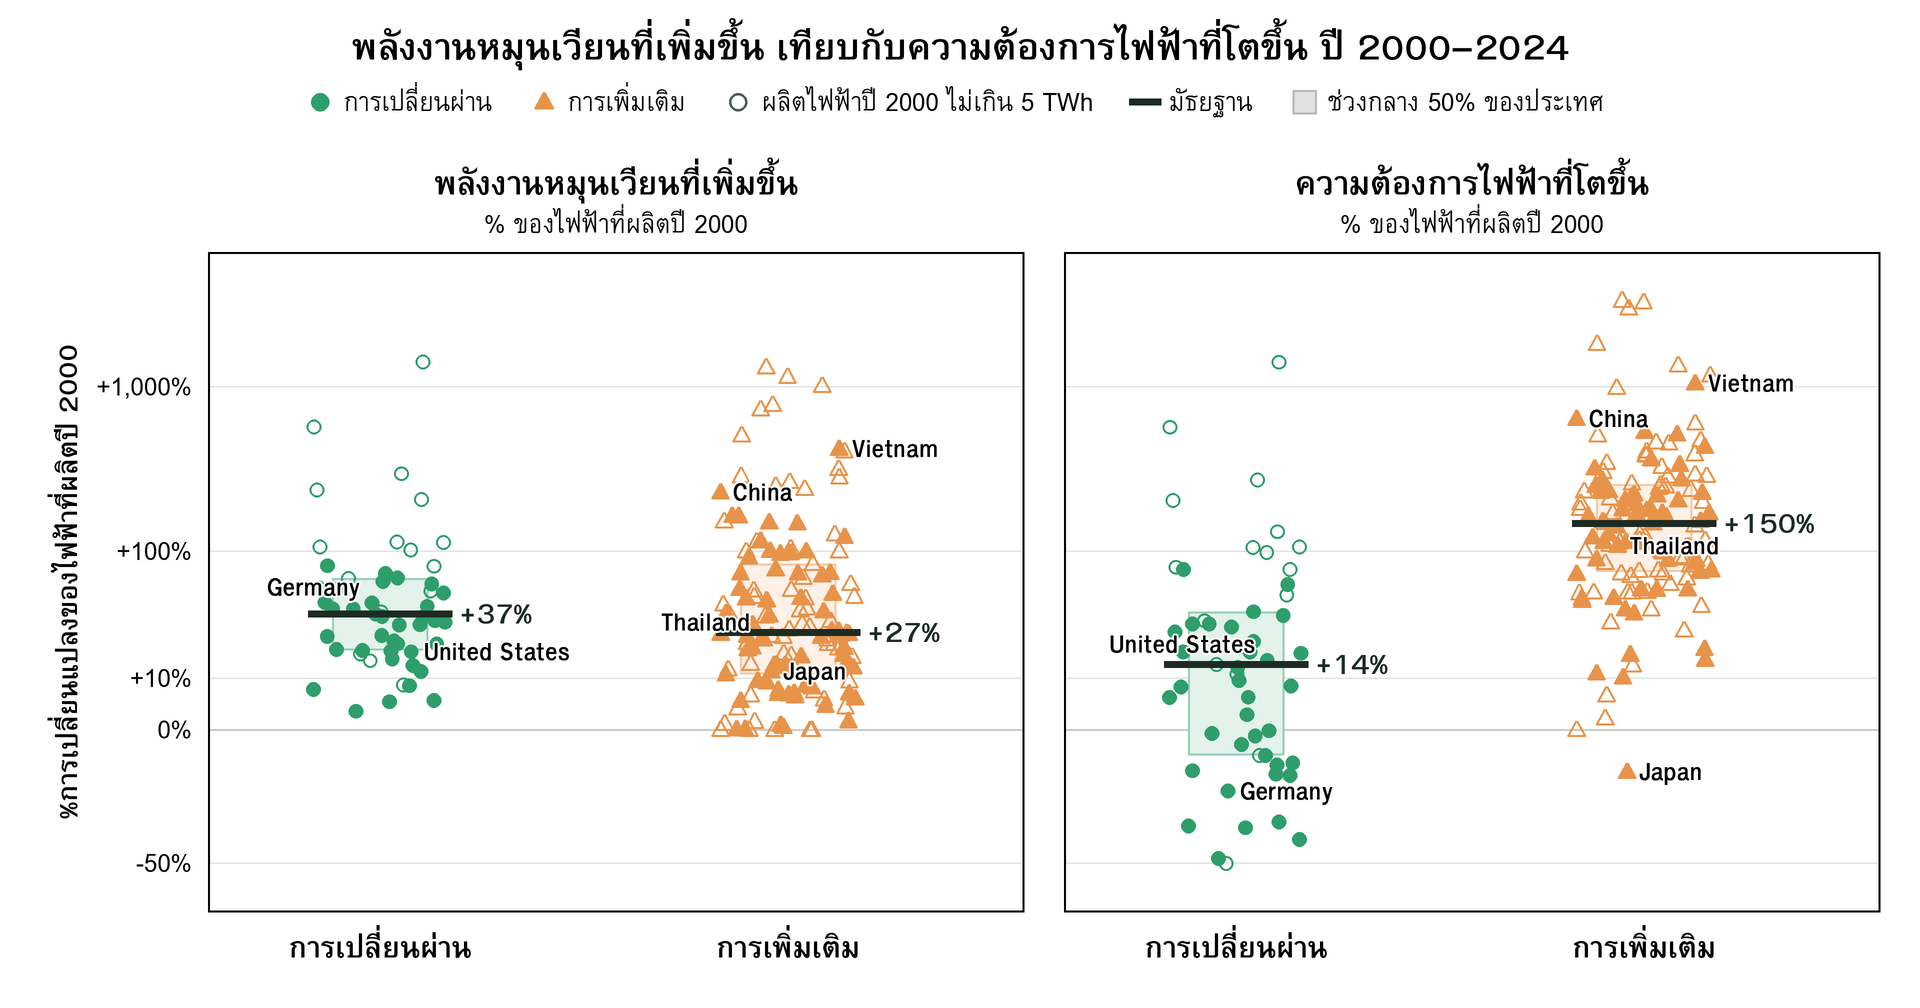

In [ ]:
from functools import lru_cache
import matplotlib

# ── Figure 9: หมุนเวียนที่เพิ่ม vs ความต้องการไฟฟ้าที่โต (การเปลี่ยนผ่าน เทียบ การเพิ่มเติม) ──────
# กราฟจุดสองแผง วัดเป็น % ของไฟฟ้าที่ผลิตปี 2000 | จุด = ประเทศ, แถบดำ = มัธยฐาน, กล่อง = ช่วงกลาง 50%
# ข้อความไทยจัดรูปด้วย HarfBuzz + วาดด้วย FreeType (แบบเดียวกับ Table 3-5)
import uharfbuzz as hb
import freetype
from PIL import Image as PILImage, ImageDraw   # ตั้งชื่อ PILImage กันชนกับ IPython Image ใน Table 1-2
from IPython.display import display

# ── 1. ตั้งค่า ─────────────────────────────────────────────────
Y0, Y1         = 2000, 2024
SMALL_BASE_TWH = 5          # ประเทศที่ผลิตไฟฟ้าปี 2000 ไม่เกินค่านี้ วาดเป็นจุดกลวง
SEED           = 7          # ตำแหน่งสุ่มแนวนอนของจุด (ภาพเหมือนเดิมทุกครั้งที่รัน)
OUT_SCALE      = 2          # ภาพกว้าง W x 2 px (W = 960 -> 1,920 px)
SS             = 4          # วาดใหญ่ 4 เท่าแล้วย่อ ให้ขอบเรียบ
OUT_PNG        = "figure10.png"
Y_LABEL = f"%การเปลี่ยนแปลงของไฟฟ้าที่ผลิตปี {Y0}"      # ชื่อแกน y + หน่วย
TITLE = f"พลังงานหมุนเวียนที่เพิ่มขึ้น เทียบกับความต้องการไฟฟ้าที่โตขึ้น ปี {Y0}–{Y1}"

# สีจตุภาค: ชุดเดียวกับ Table 1-2 / Figure 5-6
COL = dict(ink="#1c2b24", muted="#7d8a83", sub="#4f5e56", grid="#dfe5e1", zero="#c4cdc8",
           frame="#000000", T="#2E9E6B", A="#E8934A", gray="#898781")
GROUP_TH = {"Transition": "การเปลี่ยนผ่าน", "Addition": "การเพิ่มเติม"}
# 6 ประเทศกรณีศึกษา (ชุดเดียวกับ Figure 9) | ฝั่งของป้ายต่อแผง: 'r' = ขวาของจุด, 'l' = ซ้ายของจุด
HIGHLIGHT10 = ["China", "United States", "Germany", "Japan", "Vietnam", "Thailand"]
LABEL_SIDE10 = {("Germany", "ren"): "l", ("Thailand", "ren"): "l",      # ย้ายไปซ้าย ไม่ให้ทับตัวเลขมัธยฐาน
                ("United States", "demand"): "l"}
LABEL_DY10 = {("Germany", "ren"): -8, ("Thailand", "ren"): -8,  # เลื่อนป้ายขึ้น (หน่วยพิกเซลก่อนย่อ) ไม่ให้ทับแถบมัธยฐาน
              ("United States", "demand"): -8}

# ฟอนต์: ตัวเดียวกับรูปอื่น (ตัวแปร GARUDA จากเซลล์ตั้งค่าฟอนต์)
_thai_family = globals().get("GARUDA") or globals().get("thai_font_name") or "Tahoma"
_dv = Path(matplotlib.get_data_path()) / "fonts" / "ttf"
F10_FONTS = {
    "regular":  fm.findfont(fm.FontProperties(family=_thai_family), fallback_to_default=False),
    "bold":     fm.findfont(fm.FontProperties(family=_thai_family, weight="bold"), fallback_to_default=False),
    "sym":      str(_dv / "DejaVuSans.ttf"),     # Garuda ไม่มี Δ → ← จึงใช้ DejaVu เฉพาะตัวเหล่านี้
    "sym_bold": str(_dv / "DejaVuSans-Bold.ttf"),
}
F10_SYMBOLS = set("Δ→←")


# ── 2. คำนวณและจัดกลุ่ม (นิยามเดียวกับ Figure 5-6 และ Table 3-5) ─────
_s = df[df["year"].isin([Y0, Y1])].copy()
_s["RE"]     = _s[["solar_electricity", "wind_electricity", "hydro_electricity",
                   "other_renewable_electricity"]].sum(axis=1, min_count=4)
_s["Fossil"] = _s[["coal_electricity", "gas_electricity", "oil_electricity"]].sum(axis=1, min_count=3)
_p = _s.pivot(index="country", columns="year", values=["electricity_generation", "RE", "Fossil"])
d10 = pd.DataFrame({
    "gen0": _p["electricity_generation"][Y0], "gen1": _p["electricity_generation"][Y1],
    "ren0": _p["RE"][Y0], "ren1": _p["RE"][Y1],
    "fos0": _p["Fossil"][Y0], "fos1": _p["Fossil"][Y1],
}).dropna()
d10 = d10[d10["gen0"] > 0]

d_ren, d_fos = d10["ren1"] - d10["ren0"], d10["fos1"] - d10["fos0"]
d10["group"] = np.select([(d_fos < 0) & (d_ren >= 0), (d_fos >= 0) & (d_ren >= 0)],
                         ["Transition", "Addition"], default="Other")

# สองตัวชี้วัด: ทั้งคู่เป็น % ของไฟฟ้าที่ผลิตปี 2000
d10["demand"] = (d10["gen1"] - d10["gen0"]) / d10["gen0"] * 100
d10["ren"]    = d_ren / d10["gen0"] * 100

n_other = int((d10["group"] == "Other").sum())
d10 = d10[d10["group"] != "Other"].copy()           # เทียบเฉพาะสองกลุ่มนี้
d10["small"]  = d10["gen0"] <= SMALL_BASE_TWH
d10["jitter"] = np.random.default_rng(SEED).uniform(-1, 1, len(d10))

def f10_stats(measure, group):
    v = d10.loc[d10["group"] == group, measure]
    q1, med, q3 = np.percentile(v, [25, 50, 75])
    return dict(q1=q1, med=med, q3=q3, n=len(v))

for m in ("ren", "demand"):
    for g in ("Transition", "Addition"):
        s = f10_stats(m, g)
        print(f"{m:7s} {g:10s} n={s['n']:3d} | ช่วงกลาง {s['q1']:+.1f}% ถึง {s['q3']:+.1f}% | มัธยฐาน {s['med']:+.1f}%")
print("กลุ่มอื่นที่ไม่นำมาเทียบ:", n_other, "ประเทศ")


# ── 3. ตัวจัดวางข้อความไทย (HarfBuzz + FreeType) ─────────────────
K = SS

@lru_cache(None)
def _f10_hb(path):
    return hb.Font(hb.Face(hb.Blob.from_file_path(path)))

@lru_cache(None)
def _f10_ft(path):
    return freetype.Face(path)

def _f10_shape(s, path, px):
    f = _f10_hb(path)
    k = px / f.face.upem
    buf = hb.Buffer()
    buf.add_str(s)
    buf.direction, buf.script, buf.language = "ltr", "Thai", "th"   # บังคับไทย กันวรรณยุกต์วางผิด
    hb.shape(f, buf, {"kern": True, "liga": True})
    out, x = [], 0.0
    for info, pos in zip(buf.glyph_infos, buf.glyph_positions):
        out.append((info.codepoint, x, pos.x_offset * k, pos.y_offset * k))
        x += pos.x_advance * k
    return out, x

def _f10_runs(s, key):
    sym = "sym_bold" if key == "bold" else "sym"
    out = []
    for ch in s:
        kk = sym if ch in F10_SYMBOLS else key
        if out and out[-1][1] == kk:
            out[-1][0] += ch
        else:
            out.append([ch, kk])
    return [(t_, F10_FONTS[kk]) for t_, kk in out]

def tw(s, key, size):
    """ความกว้างข้อความ (หน่วยก่อนคูณ K)"""
    px = int(size * K)
    return sum(_f10_shape(t_, p, px)[1] for t_, p in _f10_runs(s, key)) / K

def put_text(img, x, y, s, key, size, fill, anchor="lm"):
    """วาดข้อความที่ (x, y) หน่วยก่อนคูณ K | anchor: l/m/r + m (กึ่งกลางแนวตั้ง)"""
    px = int(size * K)
    color = PILImage.new("RGB", (1, 1), fill).getpixel((0, 0))
    runs = [(p, *_f10_shape(t_, p, px)) for t_, p in _f10_runs(s, key)]
    total = sum(w for _, _, w in runs)
    pen = x * K - {"l": 0, "m": total / 2, "r": total}[anchor[0]]
    f0 = _f10_ft(F10_FONTS[key]); f0.set_pixel_sizes(0, px)
    base = y * K + (f0.size.ascender / 64 + f0.size.descender / 64) / 2
    for path, glyphs, w in runs:
        face = _f10_ft(path); face.set_pixel_sizes(0, px)
        for gid, gx, dx, dy in glyphs:
            face.load_glyph(gid, freetype.FT_LOAD_RENDER | freetype.FT_LOAD_TARGET_NORMAL)
            g, bm = face.glyph, face.glyph.bitmap
            if bm.width == 0 or bm.rows == 0:
                continue
            a = np.array(bm.buffer, dtype=np.uint8).reshape(bm.rows, bm.pitch)[:, :bm.width]
            mask = PILImage.fromarray(a, "L")
            img.paste(PILImage.new("RGB", mask.size, color),
                      (int(round(pen + gx + dx + g.bitmap_left)), int(round(base - dy - g.bitmap_top))), mask)
        pen += w

def wrap_text(text, key, size, max_w):
    lines, cur = [], ""
    for word in text.split(" "):
        trial = (cur + " " + word).strip()
        if tw(trial, key, size) <= max_w or not cur:
            cur = trial
        else:
            lines.append(cur); cur = word
    return lines + [cur]


# ── 4. ฟังก์ชันวาดกราฟ ────────────────────────────────────────
def mix(hex_color, a):
    """ผสมสีกับพื้นขาว ให้ได้เหมือนโปร่งแสง"""
    h = hex_color.lstrip("#")
    r, g, b = (int(h[i:i + 2], 16) for i in (0, 2, 4))
    return tuple(int(255 * (1 - a) + c * a) for c in (r, g, b))

def t(v):
    """สเกลยืดค่าน้อย ย่อค่ามาก (symlog) ใช้กับแกนตั้งทั้งสองแผง"""
    return (-1 if v < 0 else 1) * np.log10(1 + abs(v) / 10)

def ml(v):
    r = round(v)
    return ("+" if r > 0 else "\u2212" if r < 0 else "") + f"{abs(r)}%"

def tick_label(v):
    return "0%" if v == 0 else ("+" if v > 0 else "\u2212") + f"{abs(v):,}%"

W, MX = 960, 20                               # ความกว้างภาพ / ขอบซ้ายขวา (กว้างขึ้น -> ภาพเป็นผืนผ้า)
PLOT_H = 330                                  # ความสูงกรอบกราฟ (ลดลง -> ภาพเตี้ยลง)
_all = d10[["ren", "demand"]].to_numpy().ravel()
Y_MIN, Y_MAX = t(_all.min()) - 0.12, t(_all.max()) + 0.12
TICKS = [v for v in [-50, 0, 10, 100, 1000, 10000] if Y_MIN <= t(v) <= Y_MAX]
# (key, ขอบซ้ายกรอบ, ขอบขวากรอบ, ชื่อแผง)
_FX0, _GAP = 104, 20                          # ขอบซ้ายกรอบแรก / ช่องว่างระหว่างสองกรอบ
_PW = (W - MX - _FX0 - _GAP) / 2              # ความกว้างกรอบแต่ละแผง (คำนวณจาก W อัตโนมัติ)
PANELS = [("ren", _FX0, _FX0 + _PW, "พลังงานหมุนเวียนที่เพิ่มขึ้น"),
          ("demand", _FX0 + _PW + _GAP, W - MX, "ความต้องการไฟฟ้าที่โตขึ้น")]


def draw_figure10():
    n_T = int((d10["group"] == "Transition").sum()); n_A = int((d10["group"] == "Addition").sum())

    # ---------- ชื่อกราฟ ----------
    title_lines = wrap_text(TITLE, "bold", 17, W - 2 * MX)
    y_title = 14 + 26 * len(title_lines)

    # ---------- คำอธิบายกราฟ (ตัดบรรทัดอัตโนมัติ) ----------
    items = [("circle", COL["T"], GROUP_TH['Transition']),
             ("tri", COL["A"], GROUP_TH['Addition']),
             ("hollow", COL["gray"], f"ผลิตไฟฟ้าปี {Y0} ไม่เกิน {SMALL_BASE_TWH} TWh"),
             ("bar", COL["ink"], "มัธยฐาน"), ("box", COL["gray"], "ช่วงกลาง 50% ของประเทศ")]
    rows, cur, cw = [], [], 0
    for it in items:
        w_it = 22 + tw(it[2], "regular", 12) + 16
        if cw + w_it > W - 2 * MX and cur:
            rows.append(cur); cur, cw = [], 0
        cur.append((it, w_it)); cw += w_it
    rows.append(cur)
    y_leg0 = y_title + 6
    OY = y_leg0 + 22 * len(rows) + 8             # จุดเริ่มส่วนกราฟ

    FR_TOP, FR_BOT = OY + 50, OY + 50 + PLOT_H           # กรอบดำของแต่ละแผง
    PAD = 14                                     # ระยะจากกรอบถึงข้อมูล
    H = FR_BOT + 36 + 12
    img = PILImage.new("RGB", (int(W * K), int(H * K)), "white")
    dr = ImageDraw.Draw(img)

    def text(x, y, s, key, size, fill, anchor="lm"):
        put_text(img, x, y, s, key, size, fill, anchor)

    def Y(v):
        return FR_BOT - PAD - (t(v) - Y_MIN) / (Y_MAX - Y_MIN) * (FR_BOT - FR_TOP - 2 * PAD)

    def circle(cx, cy, r, fill, outline, width):
        dr.ellipse([(cx - r) * K, (cy - r) * K, (cx + r) * K, (cy + r) * K],
                   fill=fill, outline=outline, width=int(width * K))

    def tri(cx, cy, fill, outline, width, s=1.0):
        pts = [(cx, cy - 4.2 * s), (cx + 3.9 * s, cy + 3 * s), (cx - 3.9 * s, cy + 3 * s)]
        P = [(x * K, y * K) for x, y in pts]
        if fill is not None:
            dr.polygon(P, fill=fill)
        dr.line(P + [P[0]], fill=outline, width=int(width * K), joint="curve")

    # ---------- ชื่อกราฟ ----------
    for i, ln in enumerate(title_lines):
        text(W / 2, 24 + 26 * i, ln, "bold", 17, "#000000", "mm")     # กึ่งกลางภาพ สีดำ

    # ---------- คำอธิบายกราฟ ----------
    y_leg = y_leg0
    for row in rows:
        row_w = sum(w for _, w in row) - 16                          # ความกว้างแถว (ไม่นับช่องว่างท้าย)
        x = (W - row_w) / 2                                          # จัดกึ่งกลางภาพ
        for (kind, colr, label), w_it in row:
            cx, cy = x + 6, y_leg + 5
            if kind == "circle":
                circle(cx, cy, 4.5, colr, colr, 1.2)               # สีทึบล้วน
            elif kind == "tri":
                tri(cx, cy, colr, colr, 1.2, 1.15)
            elif kind == "hollow":
                circle(cx, cy, 4.5, None, COL["sub"], 1.4)
            elif kind == "bar":
                dr.rectangle([(cx - 8) * K, (cy - 1.6) * K, (cx + 8) * K, (cy + 1.6) * K], fill=colr)
            else:
                dr.rectangle([(cx - 6) * K, (cy - 6) * K, (cx + 6) * K, (cy + 6) * K],
                             fill=mix(colr, 0.25), outline=mix(colr, 0.6), width=K)
            text(x + 18, y_leg + 5, label, "regular", 12, "#000000")
            x += w_it
        y_leg += 22

    # ---------- ตัวเลขแกนตั้ง (ใช้ร่วมกันทั้งสองแผง) ----------
    for v in TICKS:
        text(PANELS[0][1] - 8, Y(v), tick_label(v), "regular", 12, "#000000", "rm")      # แกน y สีดำ

    # ---------- ชื่อแกน y (หมุน 90°) วางซ้ายตัวเลขแกน ----------
    tick_w = max(tw(tick_label(v), "regular", 12) for v in TICKS)
    lab_w, lab_h = tw(Y_LABEL, "bold", 12.5), 22
    tmp = PILImage.new("RGB", (int((lab_w + 4) * K), int(lab_h * K)), "white")
    put_text(tmp, 2, lab_h / 2, Y_LABEL, "bold", 12.5, "#000000")
    rot = tmp.rotate(90, expand=True)
    lx = PANELS[0][1] - 8 - tick_w - 14                                 # กึ่งกลางชื่อแกนตามแนวนอน
    ly = (FR_TOP + FR_BOT) / 2                                          # กึ่งกลางกรอบตามแนวตั้ง
    img.paste(rot, (int(lx * K - rot.width / 2), int(ly * K - rot.height / 2)))

    # ---------- สองแผง ----------
    labels10 = []                                  # ตำแหน่งจุดของประเทศกรณีศึกษา (วาดป้ายทีหลัง)
    for key, fx0, fx1, title in PANELS:
        mid = (fx0 + fx1) / 2                                           # กึ่งกลางกรอบ
        text(mid, OY + 16, title, "bold", 15, "#000000", "mm")          # ← ขนาดชื่อแผง (15)
        text(mid, OY + 36, f"% ของไฟฟ้าที่ผลิตปี {Y0}", "regular", 12, "#000000", "mm")

        # เส้นตารางภายในกรอบ
        for v in TICKS:
            dr.line([(fx0 * K, Y(v) * K), (fx1 * K, Y(v) * K)],
                    fill=COL["zero"] if v == 0 else COL["grid"], width=int((1.2 if v == 0 else 0.8) * K))

        slot = (fx1 - fx0) / 2
        for gi, g in enumerate(("Transition", "Addition")):
            cx = fx0 + slot * (gi + 0.5) - 16     # เยื้องซ้ายเล็กน้อย เผื่อที่ให้ตัวเลขมัธยฐาน
            colr = COL["T"] if g == "Transition" else COL["A"]
            s = f10_stats(key, g)
            # กล่อง = ช่วงกลาง 50%
            dr.rectangle([(cx - 24) * K, Y(s["q3"]) * K, (cx + 24) * K, Y(s["q1"]) * K],
                         fill=mix(colr, 0.13), outline=mix(colr, 0.5), width=K)
            # จุดของแต่ละประเทศ (ประเทศกรณีศึกษาวาดทีหลัง ให้อยู่บนสุด)
            rows_g = d10[d10["group"] == g]
            rows_g = pd.concat([rows_g[~rows_g.index.isin(HIGHLIGHT10)], rows_g[rows_g.index.isin(HIGHLIGHT10)]])
            for name, r in rows_g.iterrows():
                px, py = cx + r["jitter"] * 34, Y(r[key])
                # จุดปกติ = สีทึบ + ขอบขาวบาง (แยกจุดที่ซ้อนกันได้) | จุดกลวง = ประเทศฐานเล็ก
                fill, edge, ew = (None, colr, 1.2) if r["small"] else (colr, colr, 1.2)
                if g == "Transition":
                    circle(px, py, 3.6, fill, edge, ew)
                else:
                    tri(px, py, fill, edge, ew, 1.08)
                if name in HIGHLIGHT10:
                    labels10.append((px, py, name, key))
            # มัธยฐาน
            dr.rectangle([(cx - 36) * K, (Y(s["med"]) - 1.6) * K, (cx + 36) * K, (Y(s["med"]) + 1.6) * K],
                         fill=COL["ink"])
            text(cx + 40, Y(s["med"]), ml(s["med"]), "bold", 13.5, COL["ink"])
            # ชื่อกลุ่มใต้กรอบ
            text(cx, FR_BOT + 18, GROUP_TH[g], "bold", 13.5, "#000000", "mm")                # แกน x ดำหนา

        # กรอบดำรอบแผง
        dr.rectangle([fx0 * K, FR_TOP * K, fx1 * K, FR_BOT * K], outline=COL["frame"], width=int(1.2 * K))

    # ---------- ชื่อประเทศกรณีศึกษา (ตัวหนา + ขอบขาว แบบ Figure 9) ----------
    halo = [(-1, 0), (1, 0), (0, -1), (0, 1), (-0.7, -0.7), (0.7, 0.7), (-0.7, 0.7), (0.7, -0.7)]
    for px, py, name, key in labels10:
        side = LABEL_SIDE10.get((name, key), "r")
        lx, anchor = (px + 6, "lm") if side == "r" else (px - 6, "rm")
        ly = py + LABEL_DY10.get((name, key), 0)
        for hx, hy in halo:
            text(lx + hx, ly + hy, name, "bold", 12, "#FFFFFF", anchor)
        text(lx, ly, name, "bold", 12, "#000000", anchor)

    return img.resize((int(W * OUT_SCALE), int(H * OUT_SCALE)), PILImage.LANCZOS)


# ── 5. วาดและบันทึก ────────────────────────────────────────────
fig10 = draw_figure10()
fig10.save(OUT_PNG, dpi=(300, 300))
print("บันทึกแล้ว:", OUT_PNG, fig10.size)
display(Image(filename=OUT_PNG, width=1000))


#Figure 8

จำนวนประเทศ: 104
quadrant
การเพิ่มเติม                     63
การเปลี่ยนผ่าน                   37
การขยายตัวของเชื้อเพลิงฟอสซิล     4 

แยกกลุ่มด้วยความต้องการโต   AUC = 0.95 (p = 6.9e-14)
แยกกลุ่มด้วยหมุนเวียนที่เพิ่ม AUC = 0.50 (p = 0.98)


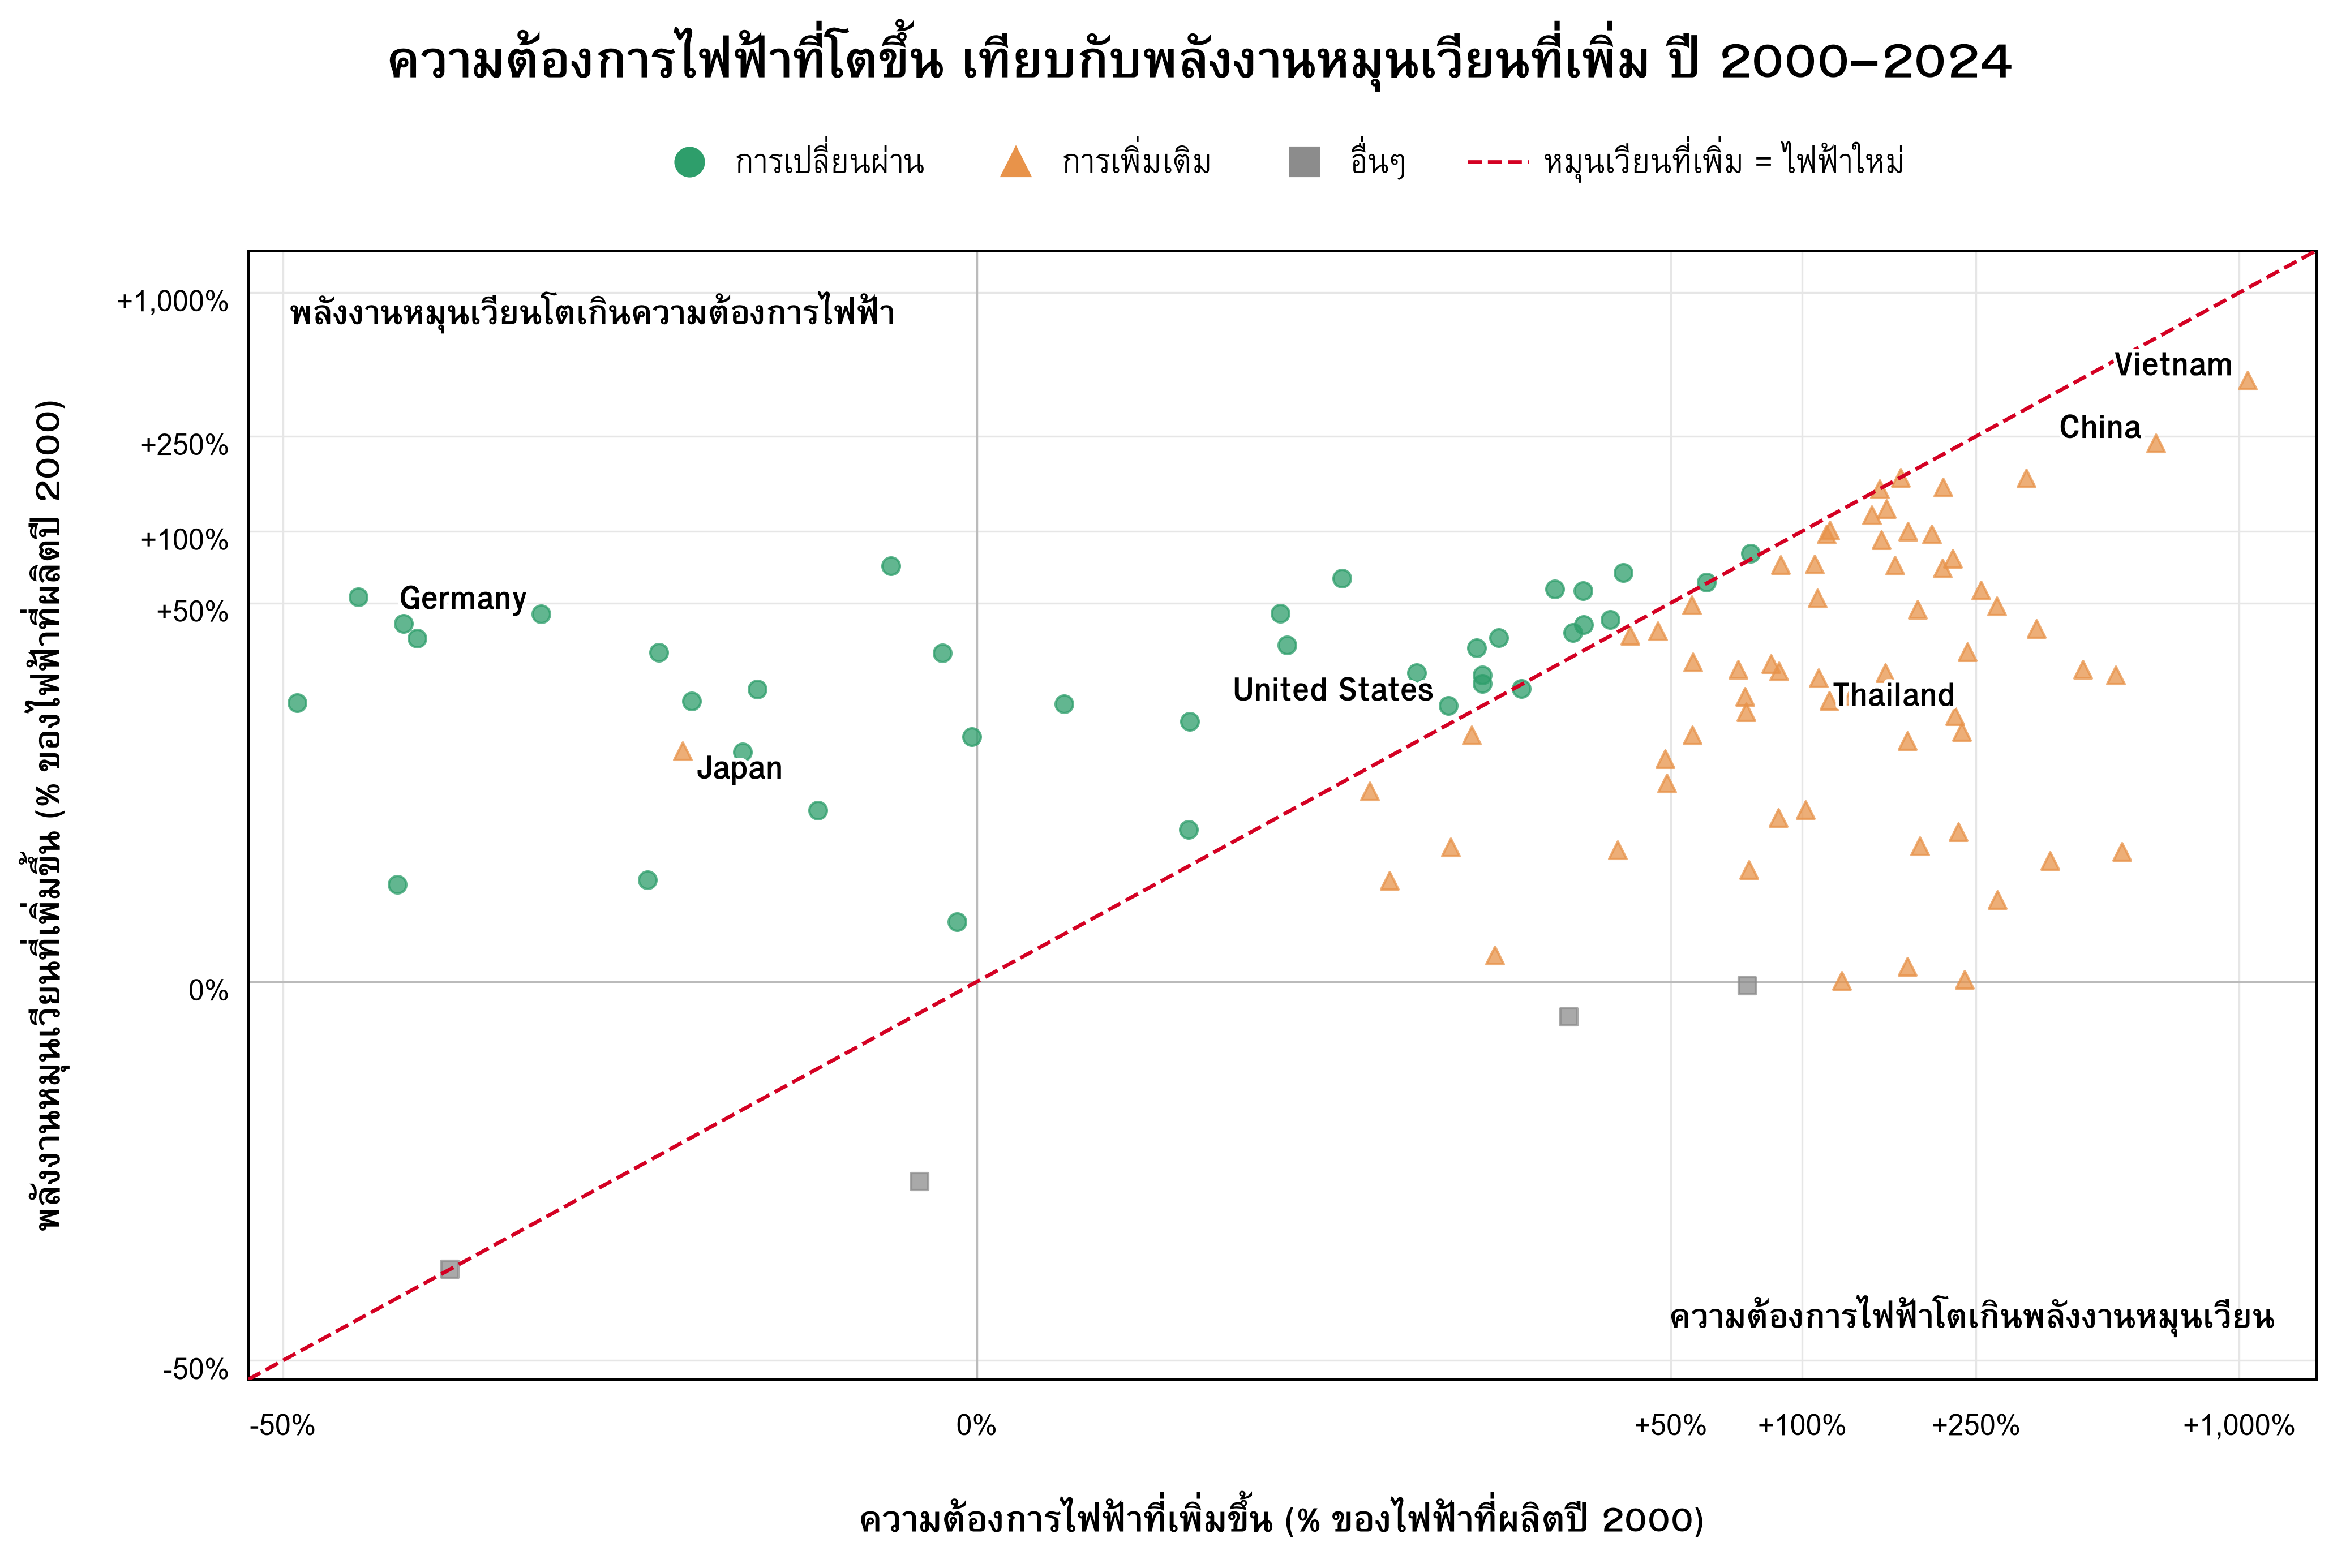

In [14]:
# ── Figure 9: ความต้องการไฟฟ้าที่โต vs พลังงานหมุนเวียนที่เพิ่ม (2000 → 2024) ──────
from matplotlib.ticker import FixedLocator, FuncFormatter
from scipy.stats import mannwhitneyu

# ── 1. ตั้งค่า ─────────────────────────────────────────────────
Y0, Y1 = 2000, 2024
MIN_GEN_TWH = 5            # ตัดประเทศที่ผลิตไฟฟ้าปี 2000 ไม่เกิน 5 TWh
HIGHLIGHT9 = {            # 6 ประเทศกรณีศึกษา (ชุดเดียวกับ Figure 9-10)
    'China':         'China',
    'United States': 'United States',
    'Germany':       'Germany',
    'Japan':         'Japan',
    'Vietnam':       'Vietnam',
    'Thailand':      'Thailand',
}

# ── 2. เตรียมข้อมูล (นิยาม RE / Fossil เดียวกับ Figure 1-10) ─────────
d11 = df[df['year'].isin([Y0, Y1])].copy()
d11['RE']     = d11[['solar_electricity', 'wind_electricity', 'hydro_electricity',
                     'other_renewable_electricity']].sum(axis=1)
d11['Fossil'] = d11[['coal_electricity', 'gas_electricity', 'oil_electricity']].sum(axis=1)

p11 = d11.pivot(index='country', columns='year',
                values=['electricity_generation', 'RE', 'Fossil'])
s11 = pd.DataFrame({
    'gen0': p11['electricity_generation'][Y0], 'gen1': p11['electricity_generation'][Y1],
    'ren0': p11['RE'][Y0],                     'ren1': p11['RE'][Y1],
    'fos0': p11['Fossil'][Y0],                 'fos1': p11['Fossil'][Y1],
}).dropna()
s11 = s11[s11['gen0'] > MIN_GEN_TWH].copy()

# สองแกน: เป็น % ของไฟฟ้าที่ผลิตปี 2000 ทั้งคู่ (เทียบข้ามประเทศขนาดต่างกันได้)
s11['demand_pct'] = (s11['gen1'] - s11['gen0']) / s11['gen0'] * 100
s11['ren_pct']    = (s11['ren1'] - s11['ren0']) / s11['gen0'] * 100

# จัดจตุภาค (เงื่อนไขเดียวกับ Figure 5)
d_ren = s11['ren1'] - s11['ren0']
d_fos = s11['fos1'] - s11['fos0']
s11['quadrant'] = np.select(
    [(d_fos >= 0) & (d_ren >= 0), (d_fos < 0) & (d_ren >= 0), (d_fos >= 0) & (d_ren < 0)],
    ['การเพิ่มเติม', 'การเปลี่ยนผ่าน', 'การขยายตัวของเชื้อเพลิงฟอสซิล'],
    default='การลดลงทั้งคู่',
)
s11['plot_group'] = s11['quadrant'].where(
    s11['quadrant'].isin(['การเปลี่ยนผ่าน', 'การเพิ่มเติม']), 'อื่นๆ')

T11 = s11[s11['quadrant'] == 'การเปลี่ยนผ่าน']
A11 = s11[s11['quadrant'] == 'การเพิ่มเติม']

# ── 3. ตรวจตัวเลขก่อนวาด ──────────────────────────────────────
def auc11(x, y):
    """ความน่าจะเป็นที่ค่าจากกลุ่ม x สูงกว่ากลุ่ม y (0.5 = ไม่ต่างกัน, 1.0 = แยกได้สมบูรณ์)"""
    u = mannwhitneyu(x, y, alternative='two-sided')
    return u.statistic / (len(x) * len(y)), u.pvalue

a_dem, p_dem = auc11(A11['demand_pct'], T11['demand_pct'])
a_ren, p_ren = auc11(A11['ren_pct'],    T11['ren_pct'])
print(f'จำนวนประเทศ: {len(s11)}')
print(s11['quadrant'].value_counts().to_string(), '\n')
print(f'แยกกลุ่มด้วยความต้องการโต   AUC = {a_dem:.2f} (p = {p_dem:.1e})')
print(f'แยกกลุ่มด้วยหมุนเวียนที่เพิ่ม AUC = {a_ren:.2f} (p = {p_ren:.2f})')

# ── 4. สี / สัญลักษณ์ ─────────────────────────────────────────
COLORS11  = {'การเปลี่ยนผ่าน': '#2E9E6B', 'การเพิ่มเติม': '#E8934A', 'อื่นๆ': '#8C8C8C'}  # ชุดเดียวกับ Figure 6
MARKERS11 = {'การเปลี่ยนผ่าน': 'o', 'การเพิ่มเติม': '^', 'อื่นๆ': 's'}
C_DIAG = '#D40123' 

# ตำแหน่งป้ายชื่อ (เลื่อนเป็น points): (dx, dy, การจัดชิด)
LABEL_OFFSETS9 = {
    'China':         (-6, 7, 'right'),
    'Vietnam':       (-6, 7, 'right'),
    'Thailand':      (6, -7, 'left'),
    'United States': (-6, 7, 'right'),
    'Germany':       (-6, 7, 'right'),
    'Japan':         (6, -7, 'left'),
}
LO, HI  = -60, 1500
X_TICKS9 = [-50, 0, 50, 100, 250, 1000]
Y_TICKS9 = [-50, 0, 50, 100, 250, 1000]

# ── 5. วาดกราฟ ────────────────────────────────────────────────
with plt.rc_context({'font.family': [GARUDA, 'DejaVu Sans'],   # Garuda = ไทย, DejaVu = สำรองสัญลักษณ์
                     'axes.unicode_minus': False}):
    fig, ax = plt.subplots(figsize=(14, 9.5), dpi=300, facecolor='white')
    fig.subplots_adjust(left=0.10, right=0.97, top=0.82, bottom=0.12)

    # symlog: เส้นตรงใกล้ 0 และ log ที่ค่ามาก จึงแสดงค่าติดลบ (ความต้องการที่ลดลง) ได้
    ax.set_xscale('symlog', linthresh=10, linscale=0.8)
    ax.set_yscale('symlog', linthresh=10, linscale=0.8)
    ax.set_xlim(LO, HI)
    ax.set_ylim(LO, HI)

    # เส้นแบ่ง: หมุนเวียนที่เพิ่ม = ไฟฟ้าใหม่ (สองแกนสเกลเดียวกัน จึงเป็นเส้นทแยงจริง)
    ax.plot([LO, HI], [LO, HI], ls='--', lw=1.6, color=C_DIAG, zorder=5)
    ax.axhline(0, color='#BBBBBB', lw=0.8, zorder=1)
    ax.axvline(0, color='#BBBBBB', lw=0.8, zorder=1)

   # 5.1 ประเทศพื้นหลัง
    others11 = s11[~s11.index.isin(HIGHLIGHT9)]
    for g in ['อื่นๆ', 'การเพิ่มเติม', 'การเปลี่ยนผ่าน']:
        s = others11[others11['plot_group'] == g]
        ax.scatter(s['demand_pct'], s['ren_pct'], marker=MARKERS11[g], s=55,
                   c=COLORS11[g], alpha=0.75, edgecolors=COLORS11[g], linewidths=1, zorder=2)

    # 5.2 6 ประเทศกรณีศึกษา
    for cn, cn_th in HIGHLIGHT9.items():
        if cn not in s11.index:
            continue
        r = s11.loc[cn]
        g = r['plot_group']
        ax.scatter(r['demand_pct'], r['ren_pct'], marker=MARKERS11[g], s=55, c=COLORS11[g],
                   alpha=0.75, edgecolors=COLORS11[g], linewidths=1, zorder=4)   # ขนาดเท่าจุดอื่น
        dx, dy, ha = LABEL_OFFSETS9[cn]
        ax.annotate(cn_th, (r['demand_pct'], r['ren_pct']), xytext=(dx, dy),
                    textcoords='offset points', ha=ha, va='center',
                    fontsize=14, fontweight='bold', color='#000000', zorder=5,
                    path_effects=[pe.withStroke(linewidth=3, foreground='white')])

    # 5.5 ข้อความกำกับสองฝั่งของเส้นทแยง
    ax.text(0.02, 0.97, 'พลังงานหมุนเวียนโตเกินความต้องการไฟฟ้า', transform=ax.transAxes,
            ha='left', va='top', fontsize=13, fontweight='bold', color='#000000')
    ax.text(0.98, 0.03, 'ความต้องการไฟฟ้าโตเกินพลังงานหมุนเวียน', transform=ax.transAxes,
            ha='right', va='bottom', fontsize=13, fontweight='bold', color='#000000')

    # 5.6 แกน
    for axis, ticks in ((ax.xaxis, X_TICKS9), (ax.yaxis, Y_TICKS9)):
        axis.set_major_locator(FixedLocator(ticks))
        axis.set_major_formatter(FuncFormatter(lambda v, _: f'{v:+,g}%' if v != 0 else '0%'))
    ax.minorticks_off()
    ax.set_xlabel(f'ความต้องการไฟฟ้าที่เพิ่มขึ้น (% ของไฟฟ้าที่ผลิตปี {Y0})', fontsize=14, fontweight='bold', color='black', labelpad=16)
    ax.set_ylabel(f'พลังงานหมุนเวียนที่เพิ่มขึ้น (% ของไฟฟ้าที่ผลิตปี {Y0})', fontsize=14, fontweight='bold', color='black', labelpad=16)
    ax.tick_params(labelsize=12, colors='black', length=0, pad=8)
    ax.grid(True, color='#E6E6E6', lw=0.8)
    ax.set_axisbelow(True)
    for side in ('top', 'right', 'left', 'bottom'):      # กรอบดำรอบกราฟ
        ax.spines[side].set_visible(True)
        ax.spines[side].set_color('black')
        ax.spines[side].set_linewidth(1.2)

    # 5.7 Legend
    handles = [
        Line2D([], [], marker='o', ls='', color=COLORS11['การเปลี่ยนผ่าน'], markersize=12,
               label='การเปลี่ยนผ่าน'),
        Line2D([], [], marker='^', ls='', color=COLORS11['การเพิ่มเติม'], markersize=12,
               label='การเพิ่มเติม'),
        Line2D([], [], marker='s', ls='', color=COLORS11['อื่นๆ'], markersize=12,
               label='อื่นๆ'),
        Line2D([], [], ls='--', color=C_DIAG, lw=1.6, label='หมุนเวียนที่เพิ่ม = ไฟฟ้าใหม่'),
    ]
    fig.legend(handles=handles, loc='center', bbox_to_anchor=(0.535, 0.875), ncol=4,
              frameon=False, fontsize=13, handletextpad=0.5, columnspacing=2.0)

    # 5.8 หัวเรื่อง
    fig.suptitle(f'ความต้องการไฟฟ้าที่โตขึ้น เทียบกับพลังงานหมุนเวียนที่เพิ่ม ปี {Y0}–{Y1}',
                 fontsize=20, fontweight='bold', y=0.965)

    fig.savefig('figure9.png', dpi=300, facecolor='white')
    plt.show()